# **1. Importing Libraries**
---

In [1]:
import sys
import os

curr = os.path.dirname(os.path.abspath('__file__'))
path_root = os.path.dirname(curr)
functions_folder = os.path.join(path_root, 'data_processing')

sys.path.append(functions_folder)

In [2]:
# Data processing & extraction
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from functions import extract_view_to_df

import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Modelling - statsmodels
from statsmodels.tsa.arima.model import ARIMA

# Modelling - TFT
import torch
import lightning as lt
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

# Model Evaluation
from pytorch_forecasting.metrics.quantile import QuantileLoss
from pytorch_forecasting.metrics.point import MAE, RMSE, SMAPE

# **2. Data Extraction**
---

In [3]:
load_dotenv()

username_postgres = os.getenv('USERNAME_POSTGRES')
pw_postgres = os.getenv('PW_POSTGRES')
db_name = 'data_warehouse_electricity'

df, path_df = extract_view_to_df(username_postgres=username_postgres, pw_postgres=pw_postgres, db_name=db_name)
date_cutoff = pd.to_datetime('2026-08-06 00:00:00')
df = df[df['time_stamp']<=date_cutoff]
df

DB data_warehouse_electricity exists? True


,id_demand_elec_generated,time_stamp,rto_id,rto_full_name,demand_mwh,mwh_ng,mwh_nuc,mwh_wnd,mwh_sun,mwh_col,mwh_wat,mwh_oil,mwh_oth
0,DFCISO20230101-00AGG,2023-01-01 00:00:00,CISO,California Independent System Operator,24007,8897,2245,3395,954,4,2178,87,264
1,DFCISO20230101-01AGG,2023-01-01 01:00:00,CISO,California Independent System Operator,24546,9277,2247,3384,73,3,2455,87,846
2,DFCISO20230101-02AGG,2023-01-01 02:00:00,CISO,California Independent System Operator,25344,9394,2248,3236,-25,3,2696,82,1450
3,DFCISO20230101-03AGG,2023-01-01 03:00:00,CISO,California Independent System Operator,26468,9108,2247,3041,-25,3,2482,45,1307
4,DFCISO20230101-04AGG,2023-01-01 04:00:00,CISO,California Independent System Operator,26047,8969,2247,2748,-27,3,2303,45,1010
...,...,...,...,...,...,...,...,...,...,...,...,...,...
158143,DFSWPP20260805-20AGG,2026-08-05 20:00:00,SWPP,Southwest Power Pool,49243,20109,1970,7814,2100,15976,1860,0,34
158144,DFSWPP20260805-21AGG,2026-08-05 21:00:00,SWPP,Southwest Power Pool,50110,19986,1969,8047,2077,16127,1938,0,28
158145,DFSWPP20260805-22AGG,2026-08-05 22:00:00,SWPP,Southwest Power Pool,50423,19561,1969,8871,2020,15966,2052,0,45
158146,DFSWPP20260805-23AGG,2026-08-05 23:00:00,SWPP,Southwest Power Pool,50419,19095,1968,10424,1892,15191,2053,0,60


# **3. Exploratory Data Analysis**
---

## **3.1. Data Description**
---

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 157564 entries, 0 to 158147
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   id_demand_elec_generated  157564 non-null  str           
 1   time_stamp                157564 non-null  datetime64[us]
 2   rto_id                    157564 non-null  str           
 3   rto_full_name             157564 non-null  str           
 4   demand_mwh                157467 non-null  object        
 5   mwh_ng                    157394 non-null  object        
 6   mwh_nuc                   157414 non-null  object        
 7   mwh_wnd                   157417 non-null  object        
 8   mwh_sun                   157406 non-null  object        
 9   mwh_col                   157409 non-null  object        
 10  mwh_wat                   157388 non-null  object        
 11  mwh_oil                   94430 non-null   object        
 12  mwh_oth           

In [5]:
cols_obj = ['demand_mwh', 'mwh_ng', 'mwh_nuc', 'mwh_wnd', 'mwh_sun', 'mwh_col', 'mwh_wat', 'mwh_oil', 'mwh_oth']
for col in cols_obj:
    df[col] = pd.to_numeric(df[col])

df.describe(include='all')

,id_demand_elec_generated,time_stamp,rto_id,rto_full_name,demand_mwh,mwh_ng,mwh_nuc,mwh_wnd,mwh_sun,mwh_col,mwh_wat,mwh_oil,mwh_oth
count,157564,157564,157564,157564,1.574670e+05,157394.000000,157414.000000,1.574170e+05,157406.000000,157409.000000,157388.000000,94430.00000,157305.000000
unique,157564,NaN,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,DFCISO20230101-00AGG,NaN,CISO,California Independent System Operator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,31513,31513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2024-10-18 12:03:10.436901,NaN,NaN,5.631004e+04,22011.530312,10005.693325,8.536294e+03,3265.762970,10270.560896,1321.914339,190.33753,400.934993
min,NaN,2023-01-01 00:00:00,NaN,NaN,1.181900e+04,262.000000,0.000000,2.200000e+01,-87.000000,-7.000000,-463.000000,-5.00000,-9861.000000
25%,NaN,2023-11-25 06:00:00,NaN,NaN,3.071300e+04,9389.000000,2244.000000,2.793000e+03,1.000000,4510.000000,390.000000,0.00000,41.000000
50%,NaN,2024-10-18 12:00:00,NaN,NaN,5.143600e+04,20061.000000,4977.000000,6.509000e+03,106.000000,9327.000000,1005.000000,46.00000,225.000000
75%,NaN,2025-09-11 18:00:00,NaN,NaN,7.702700e+04,32216.000000,11483.750000,1.390900e+04,4328.750000,15158.000000,1815.000000,208.00000,812.000000
max,NaN,2026-08-06 00:00:00,NaN,NaN,3.621097e+06,75926.000000,34017.000000,3.589445e+06,34982.000000,37447.000000,7000.000000,7801.00000,11500.000000


In [6]:
df.isna().sum()

id_demand_elec_generated        0
time_stamp                      0
rto_id                          0
rto_full_name                   0
demand_mwh                     97
mwh_ng                        170
mwh_nuc                       150
mwh_wnd                       147
mwh_sun                       158
mwh_col                       155
mwh_wat                       176
mwh_oil                     63134
mwh_oth                       259
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## **3.2. Demand & Power Generation Overtime**
---

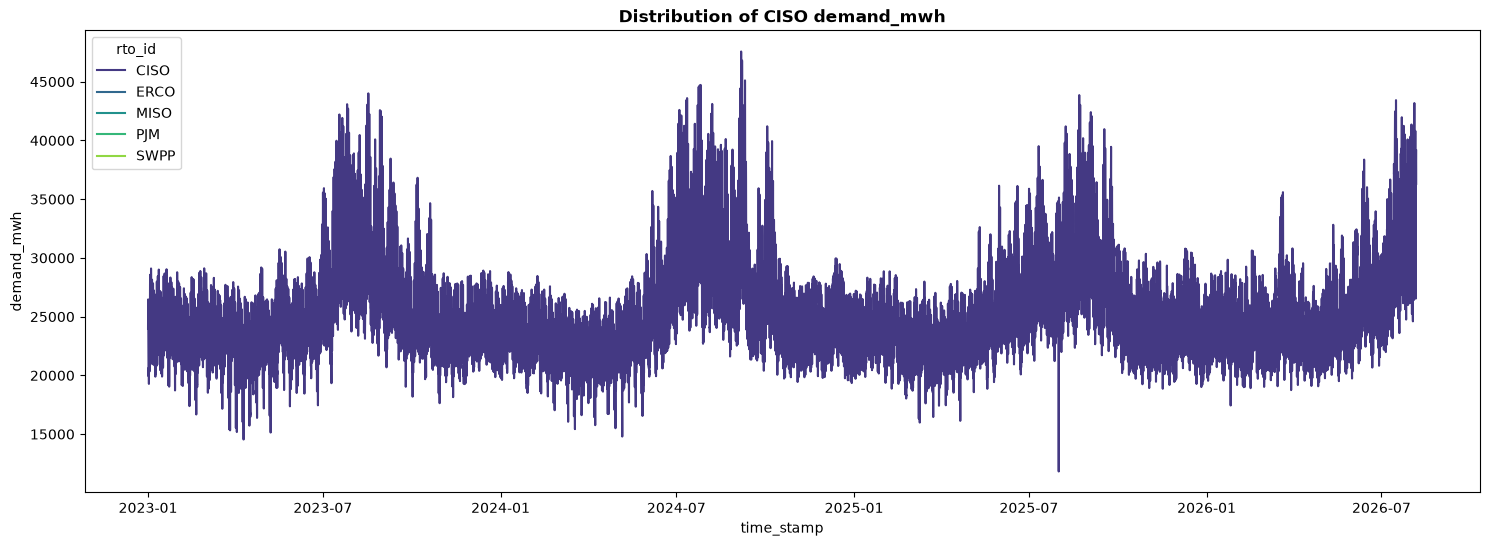

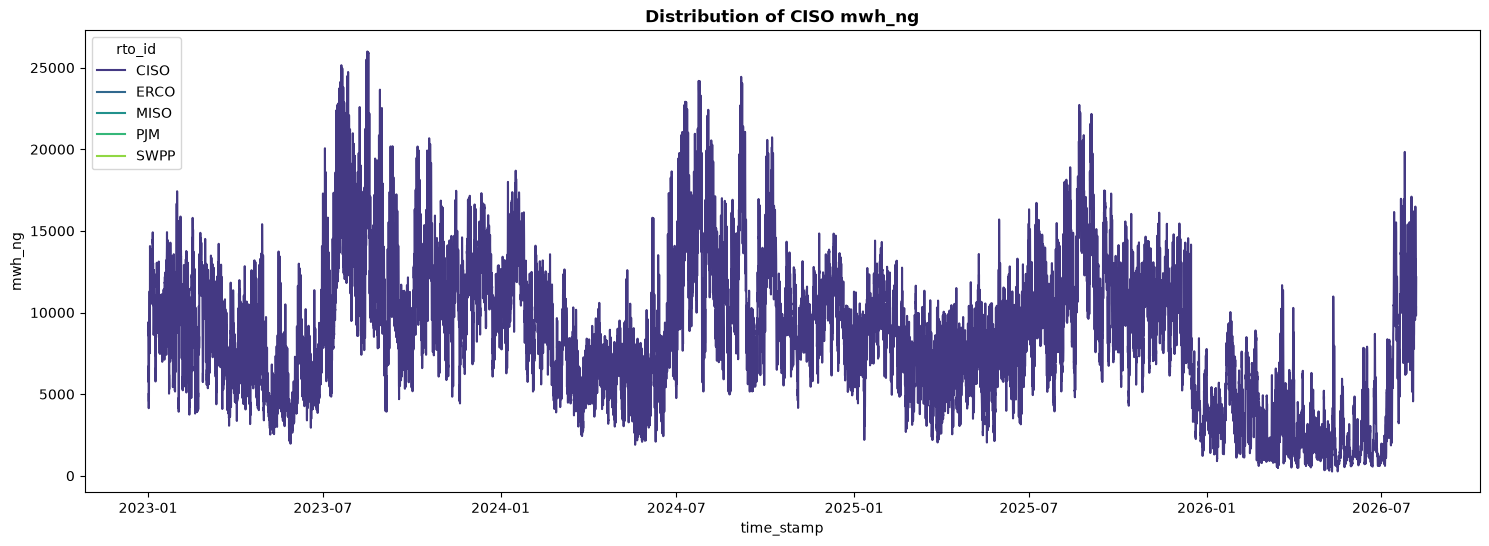

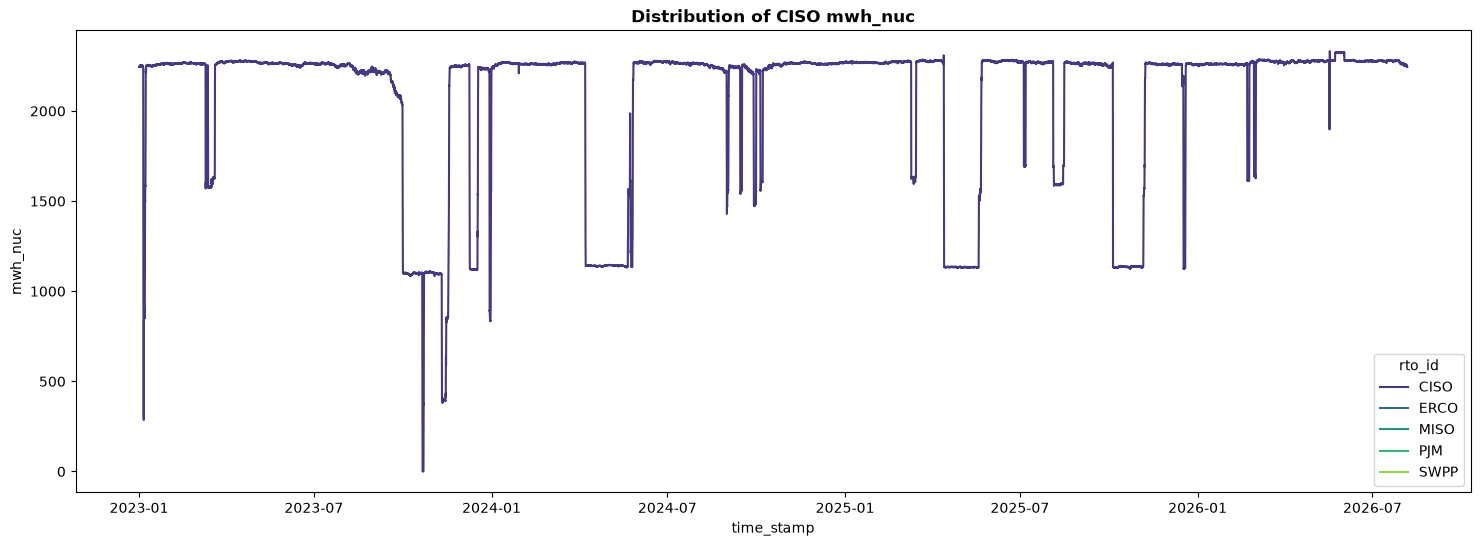

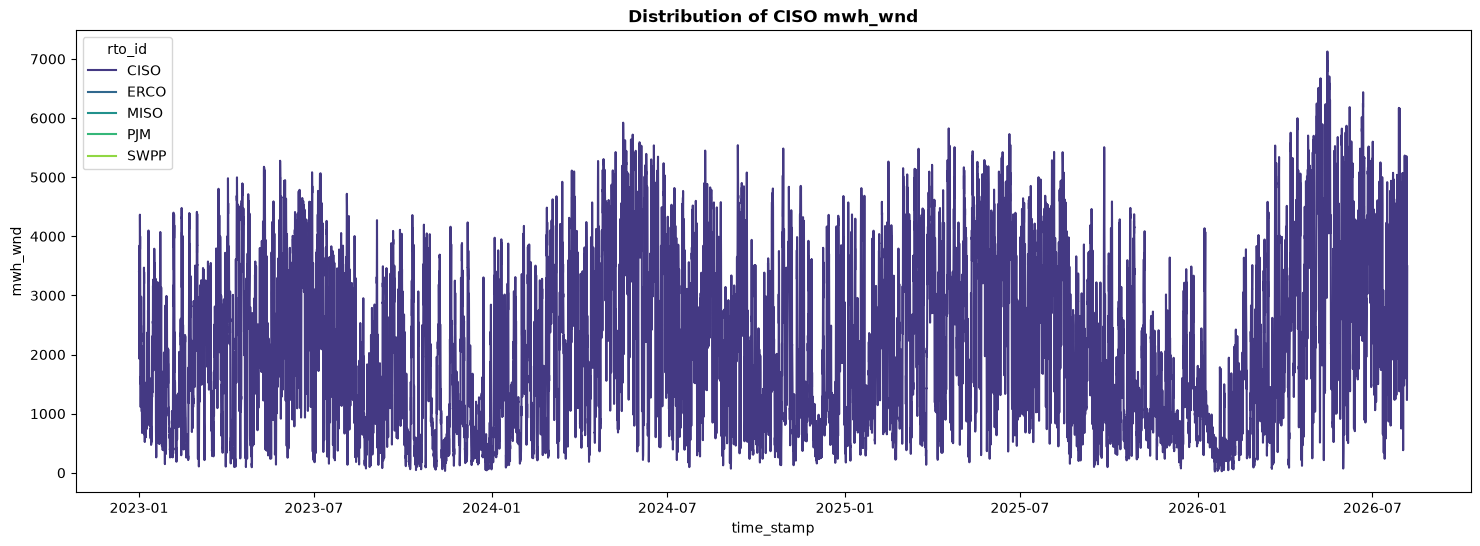

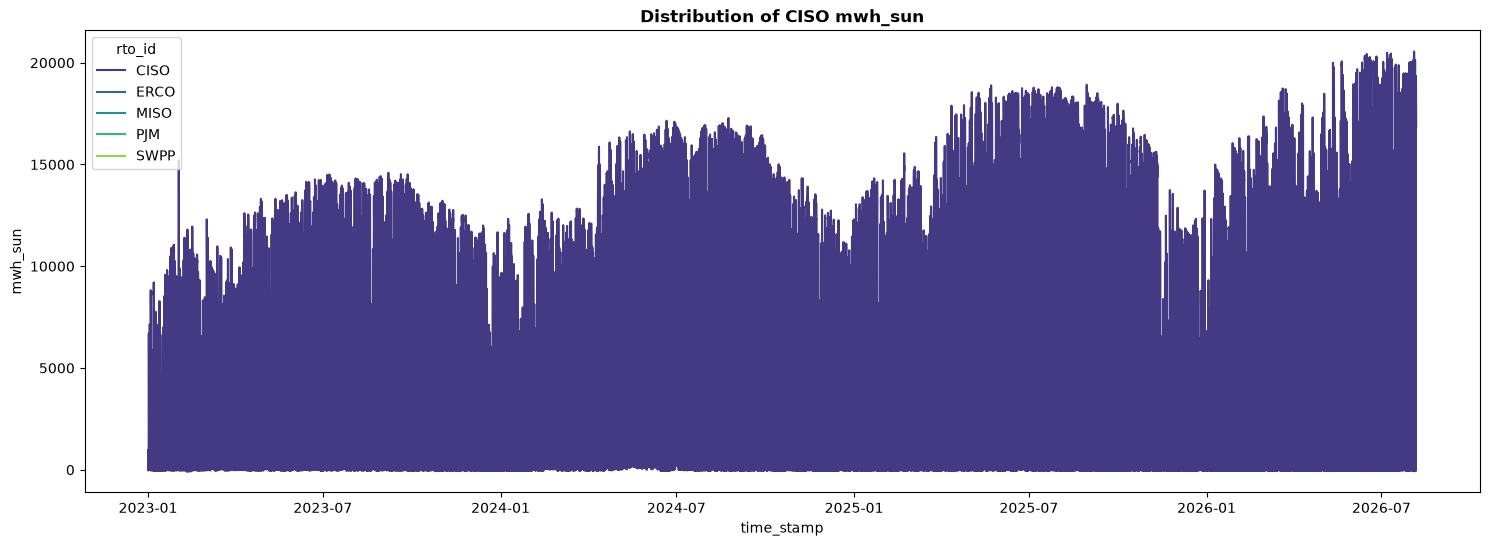

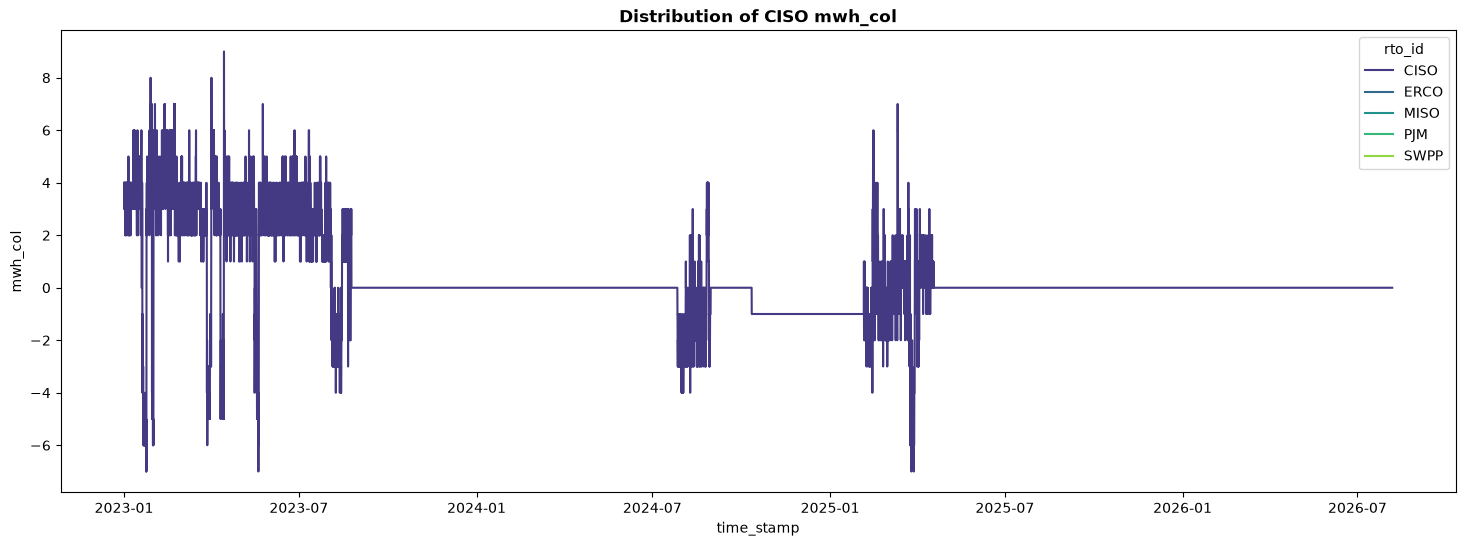

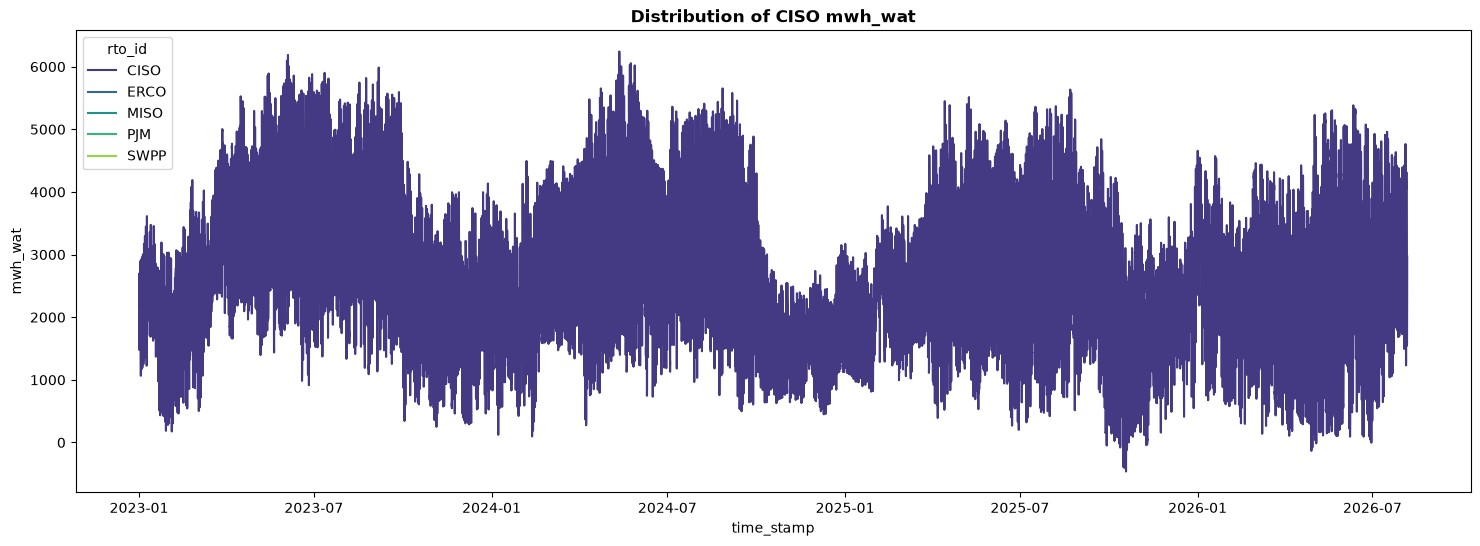

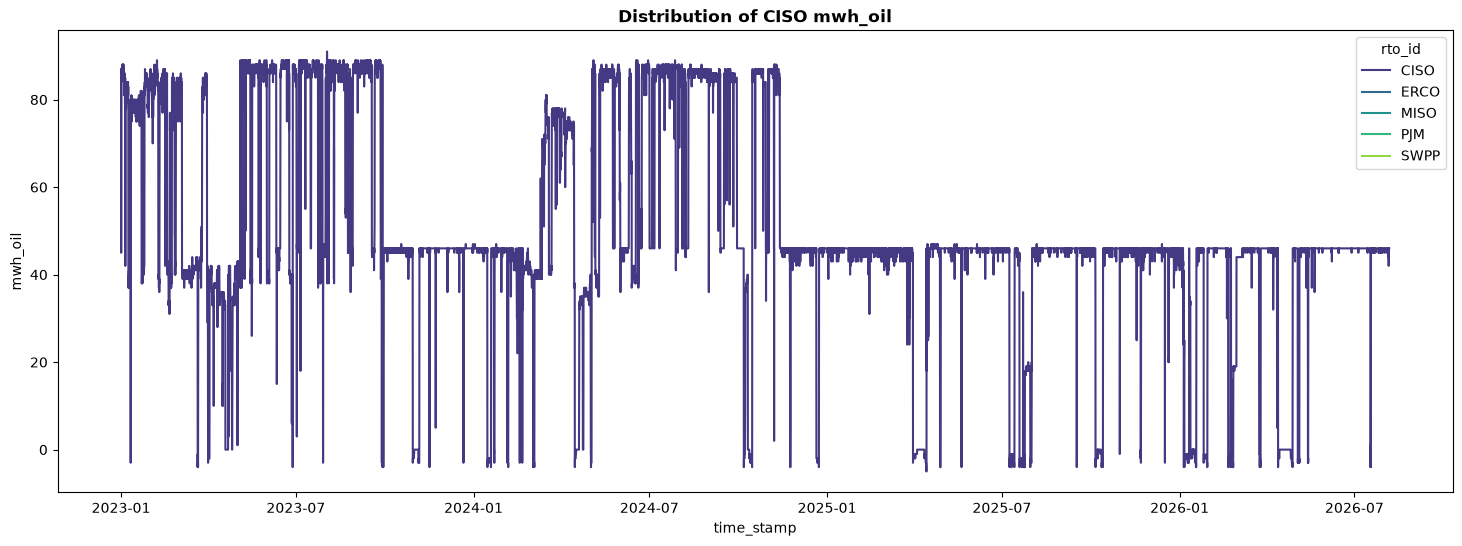

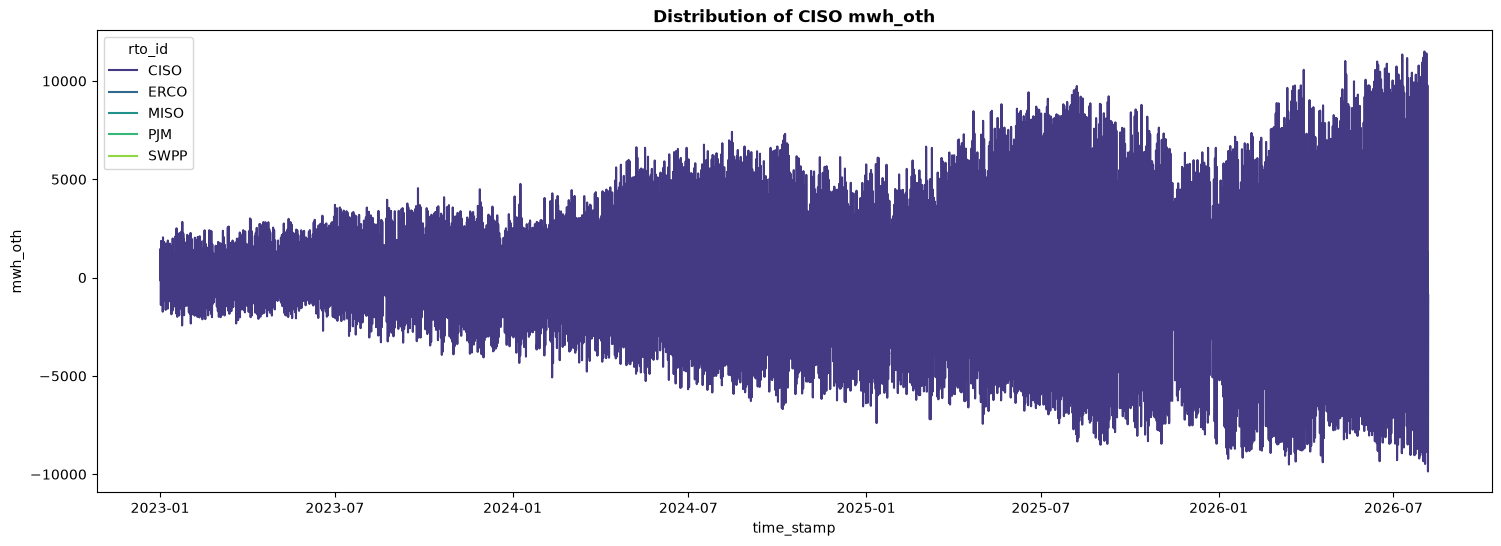

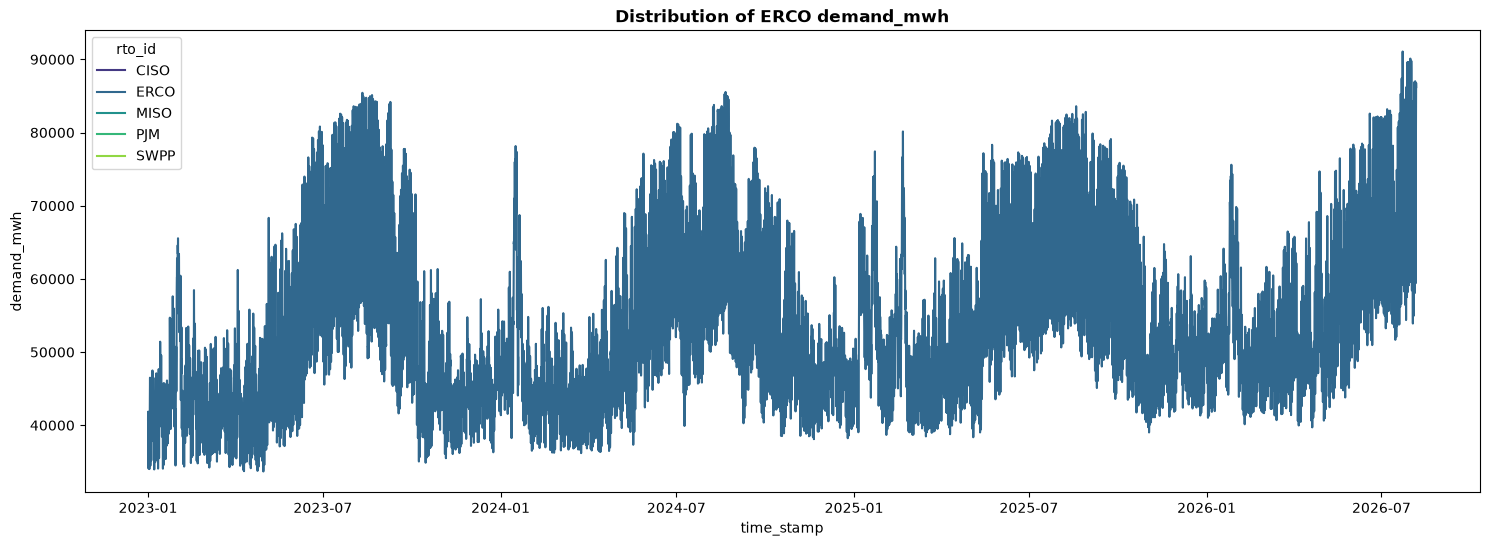

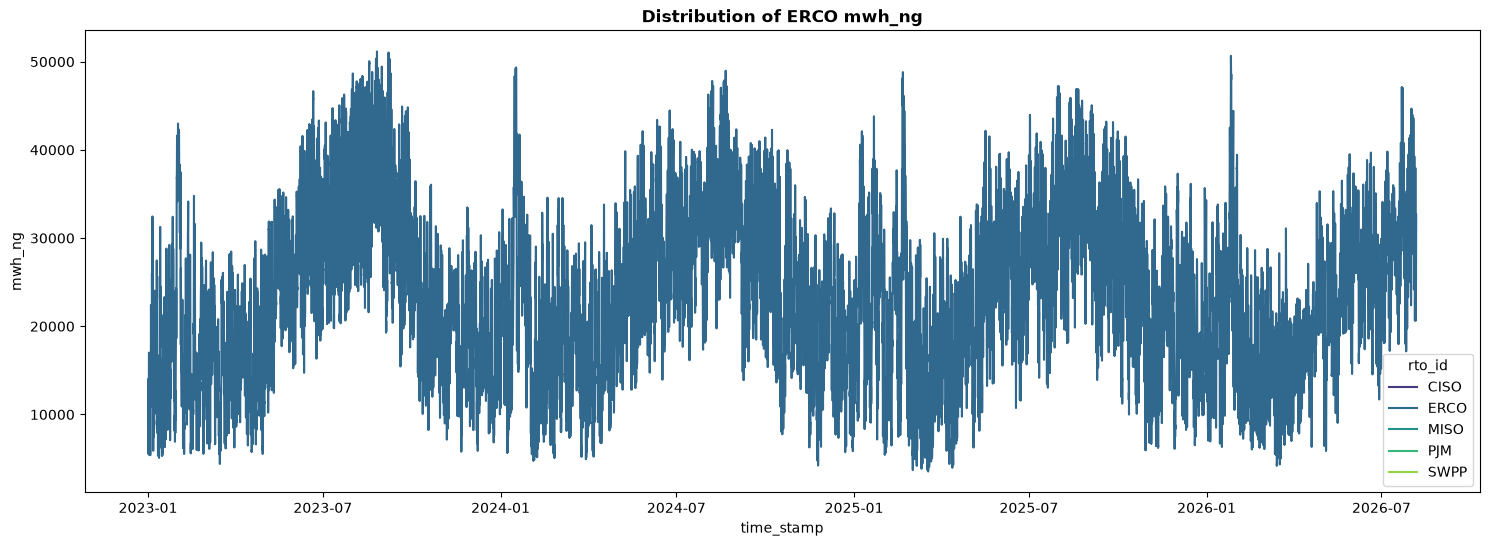

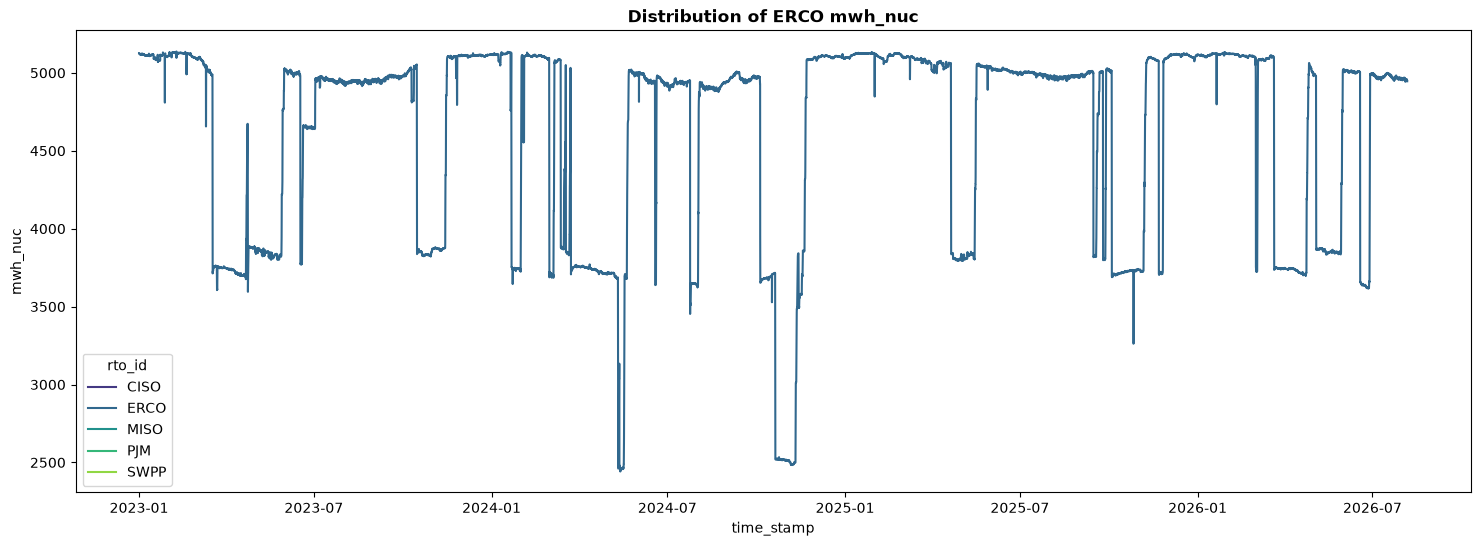

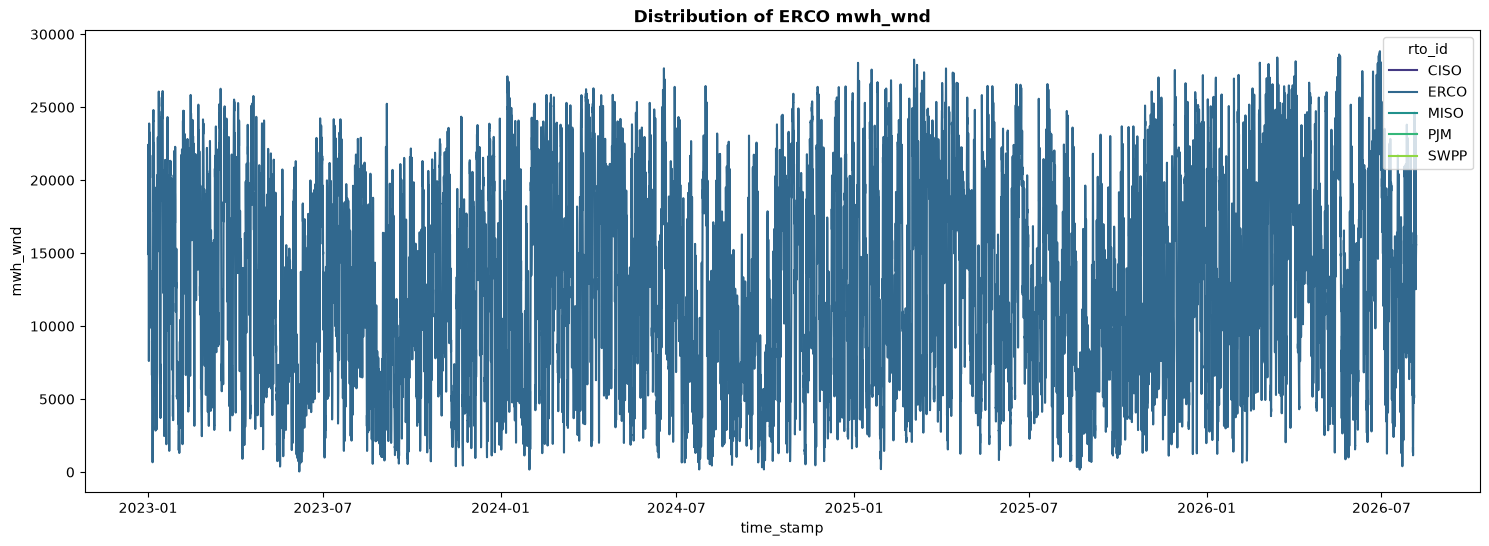

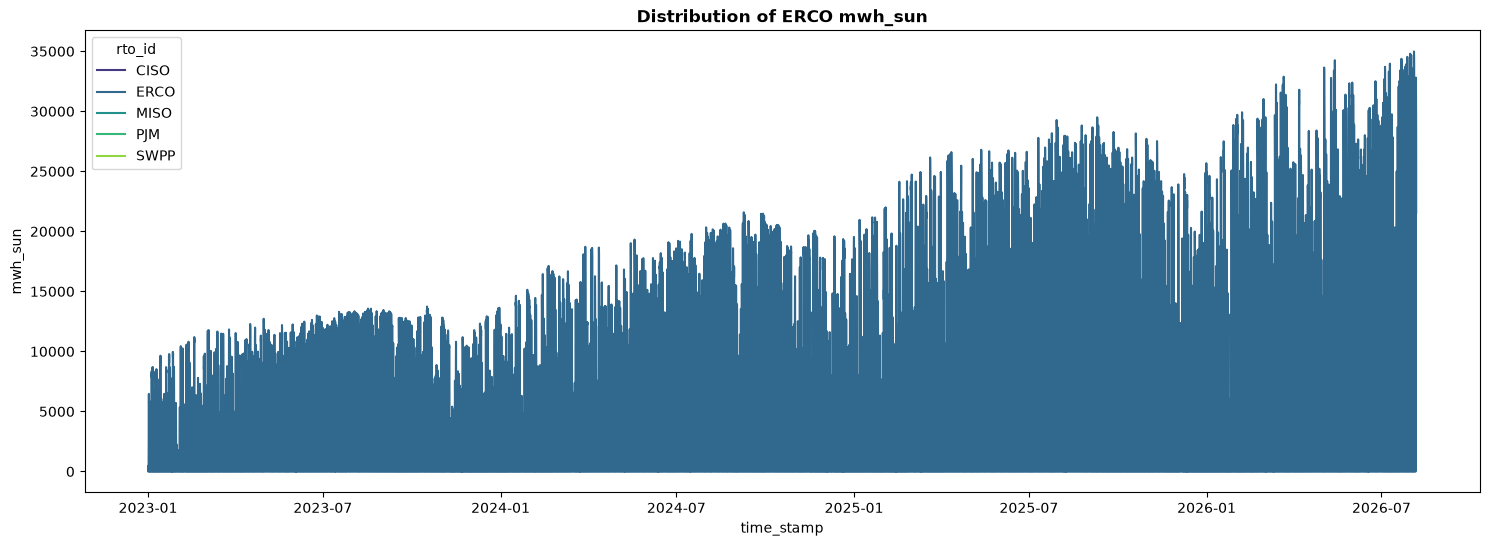

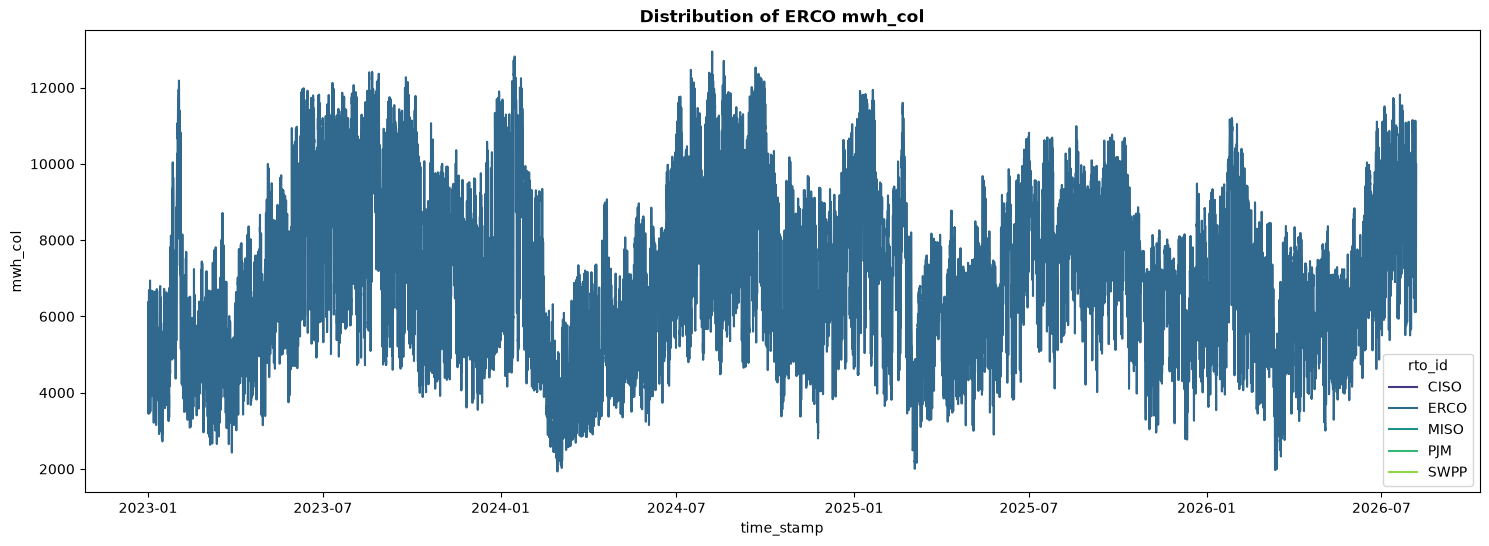

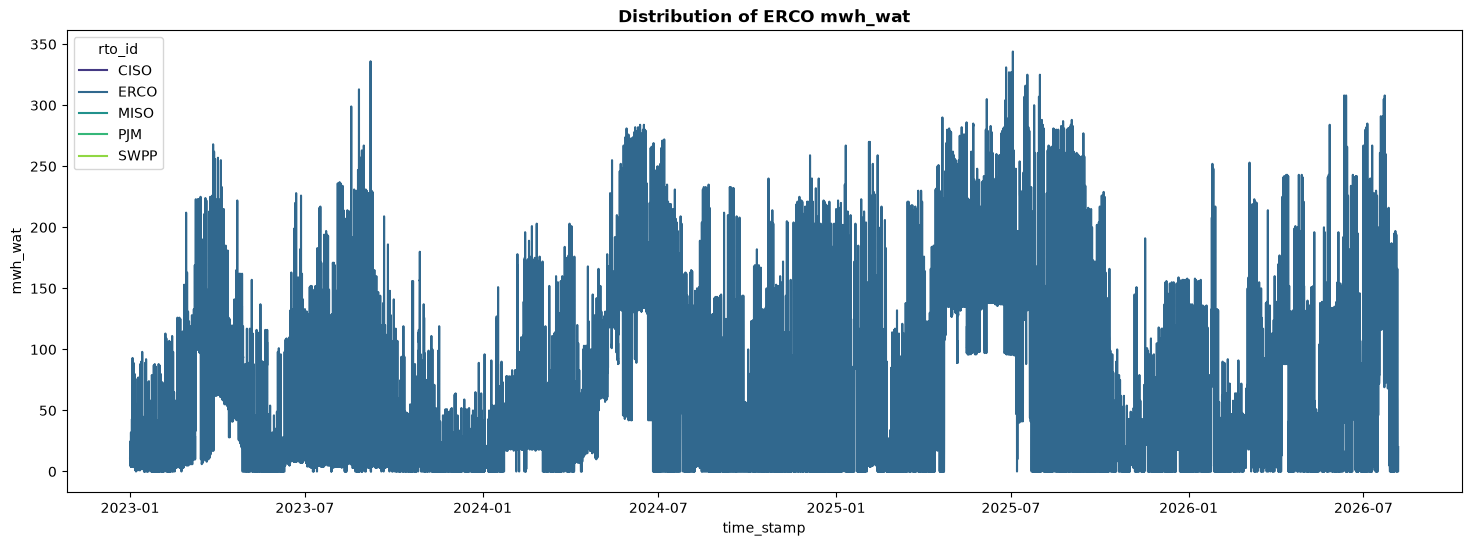

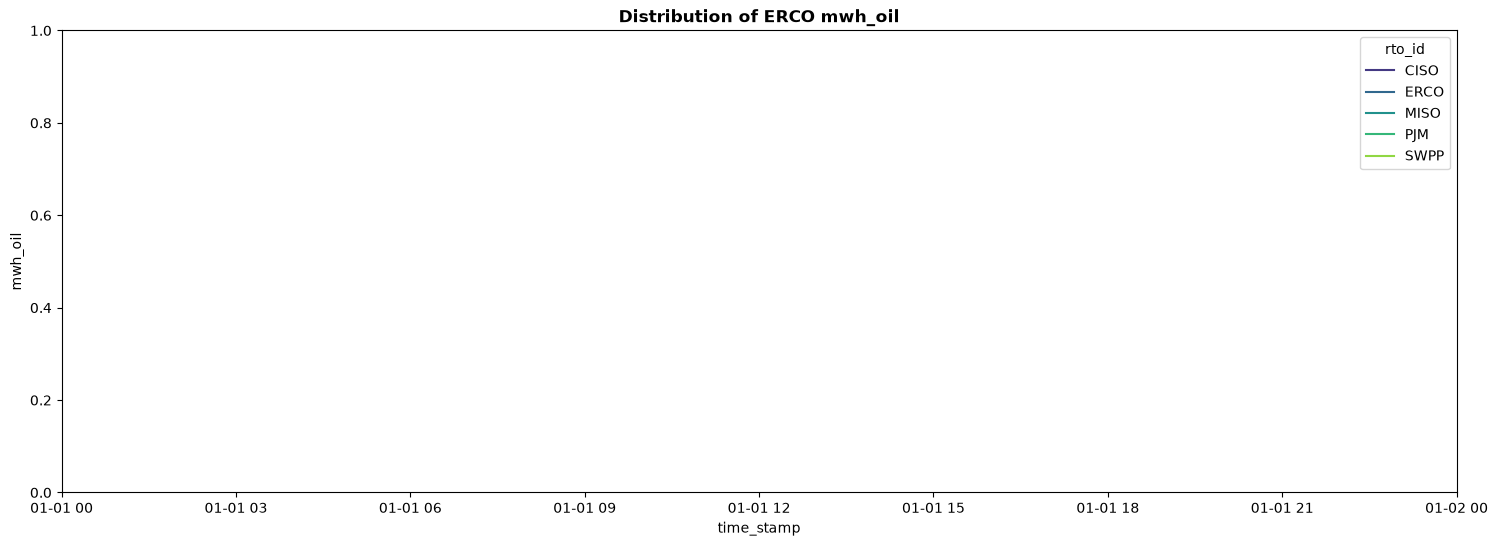

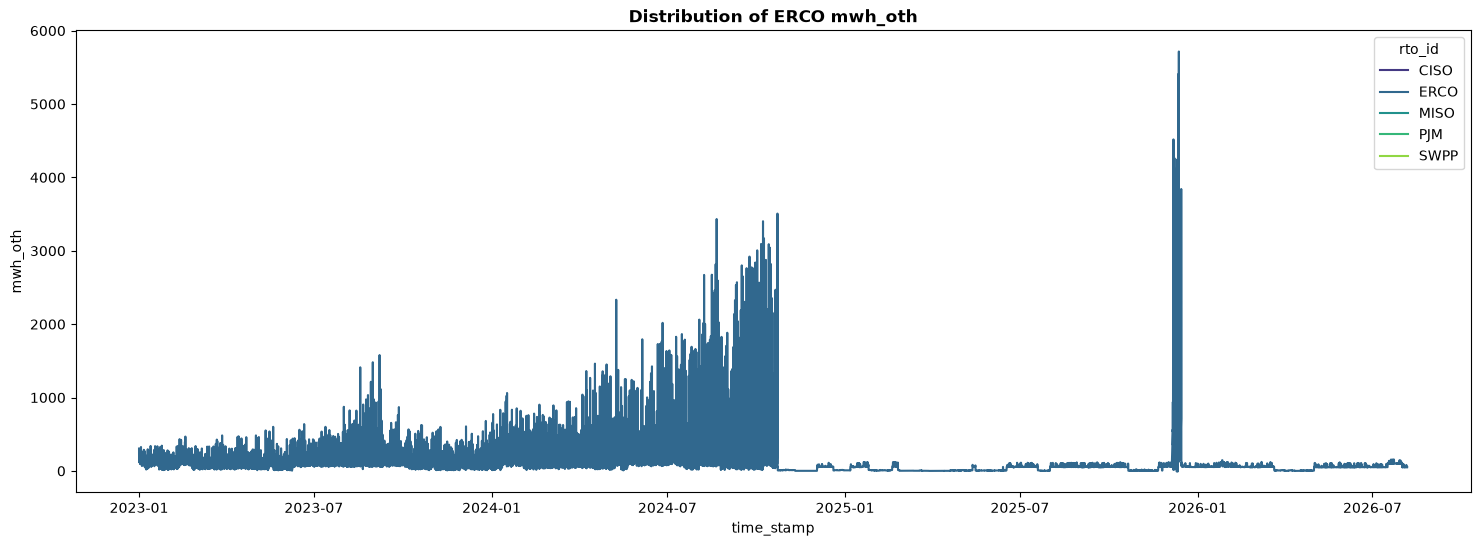

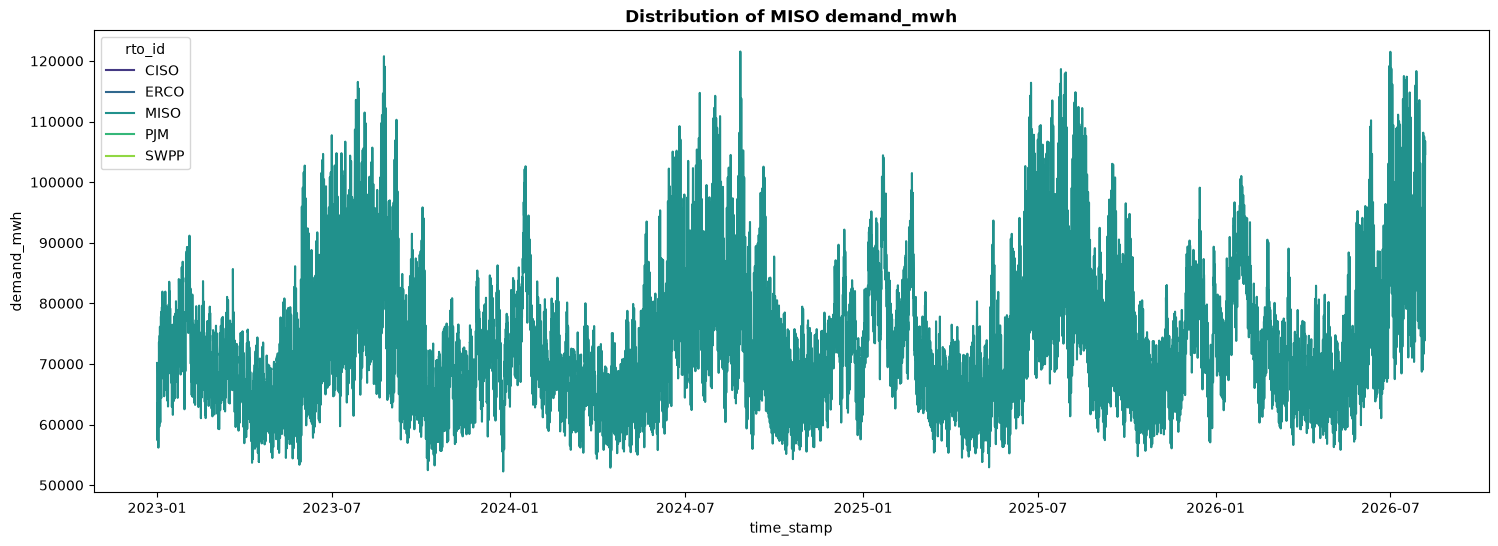

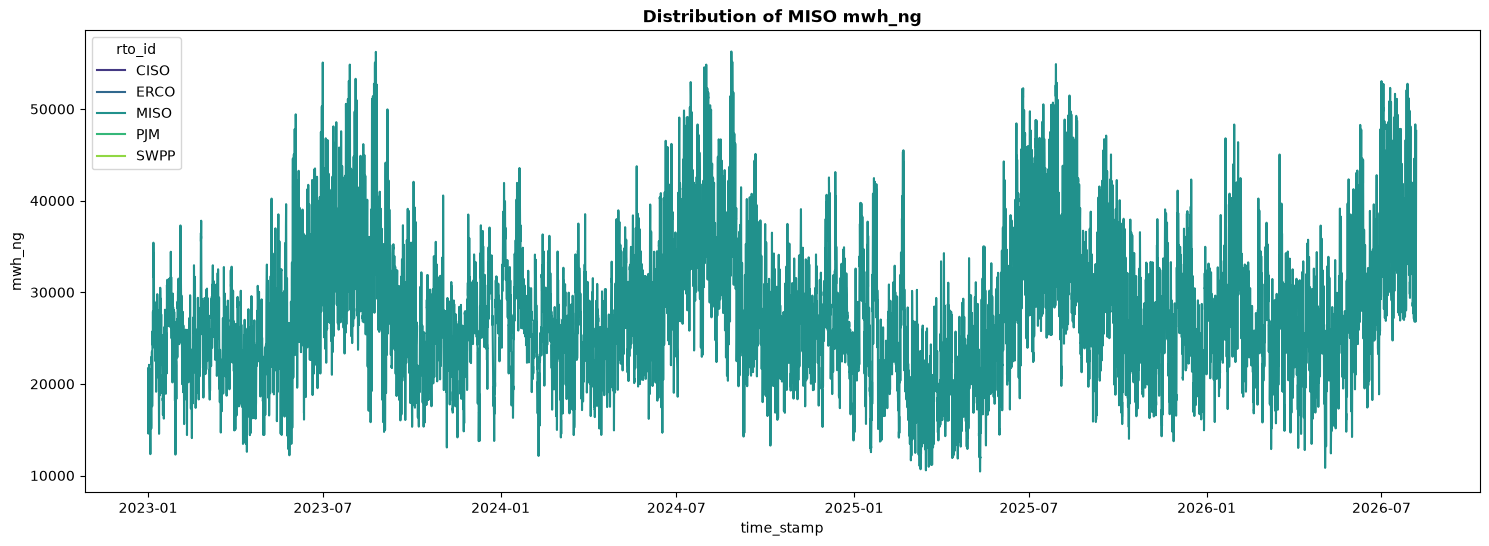

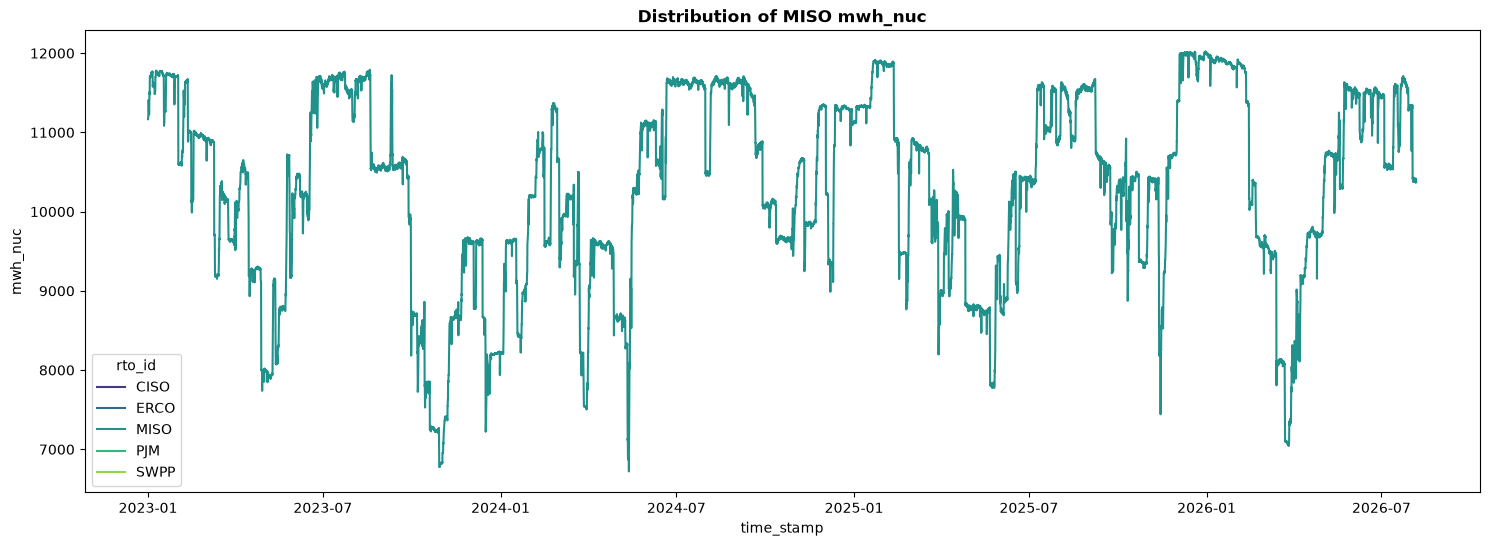

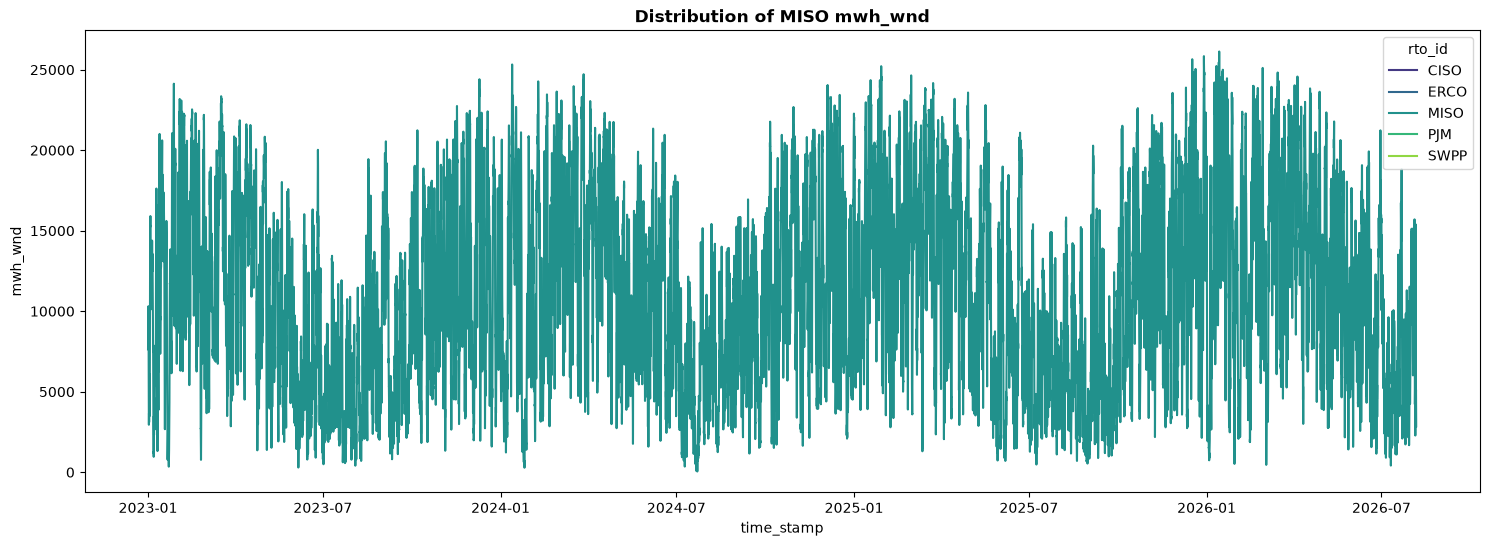

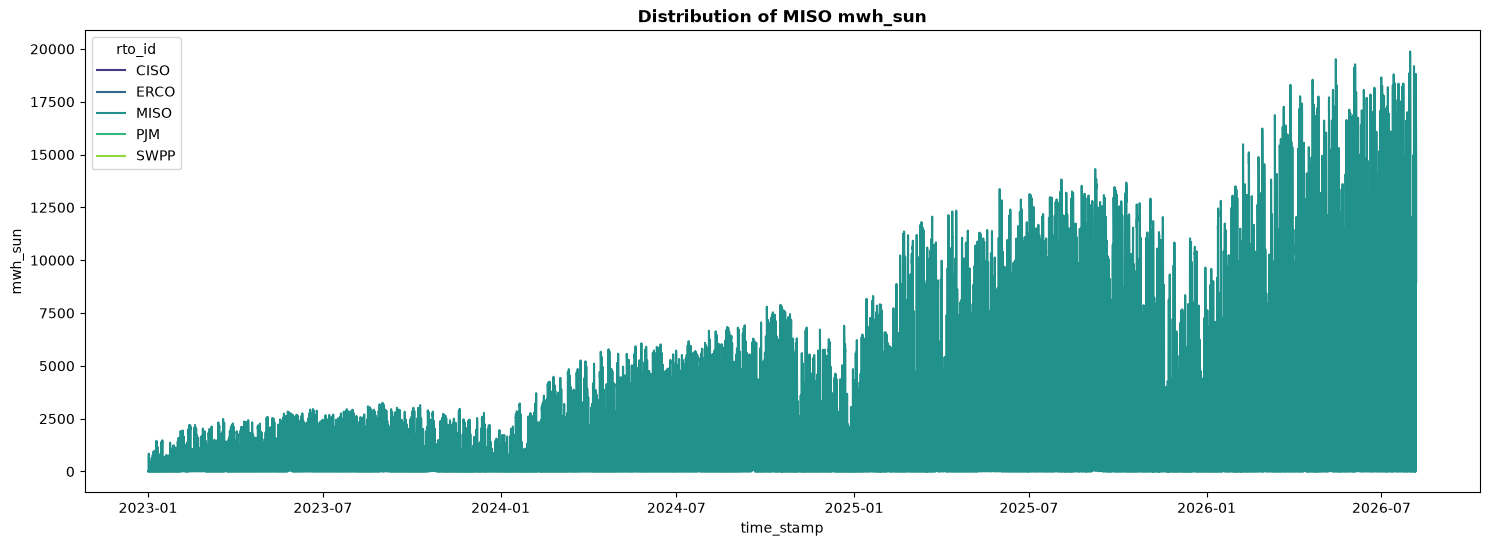

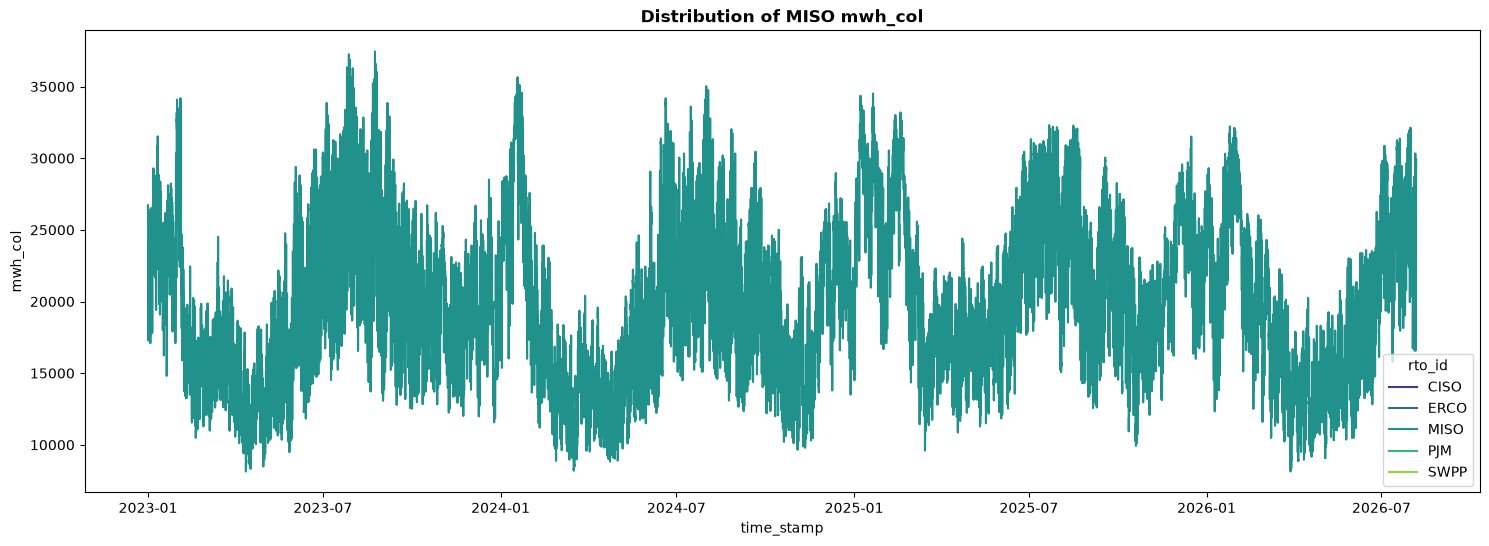

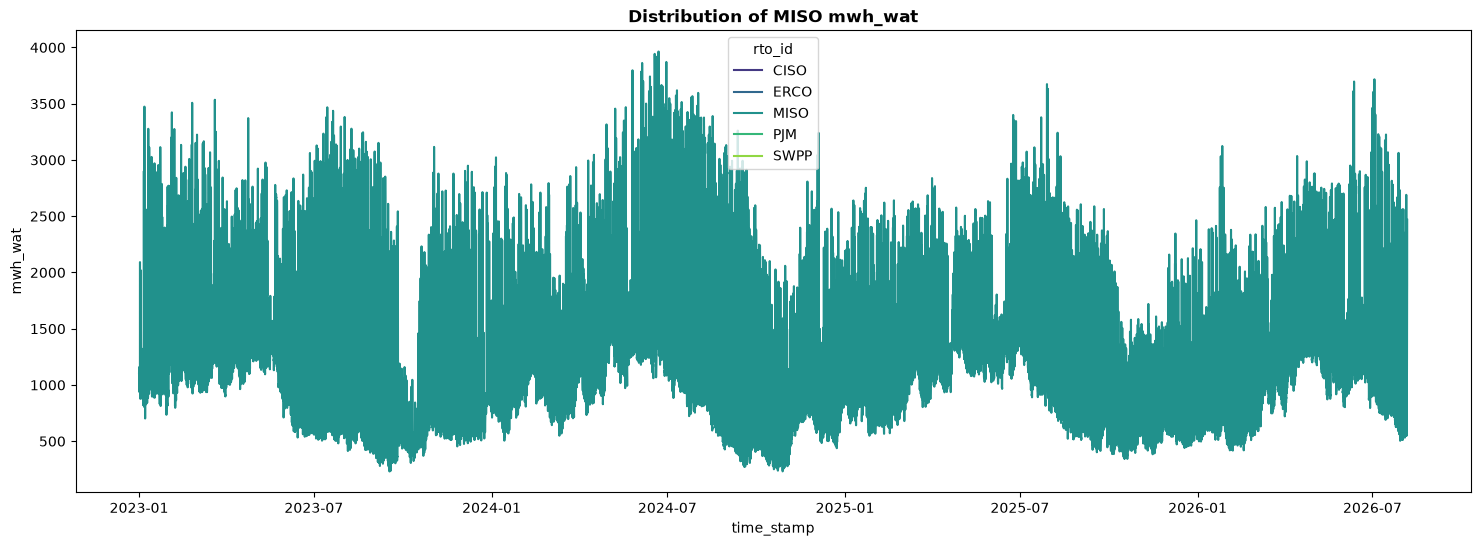

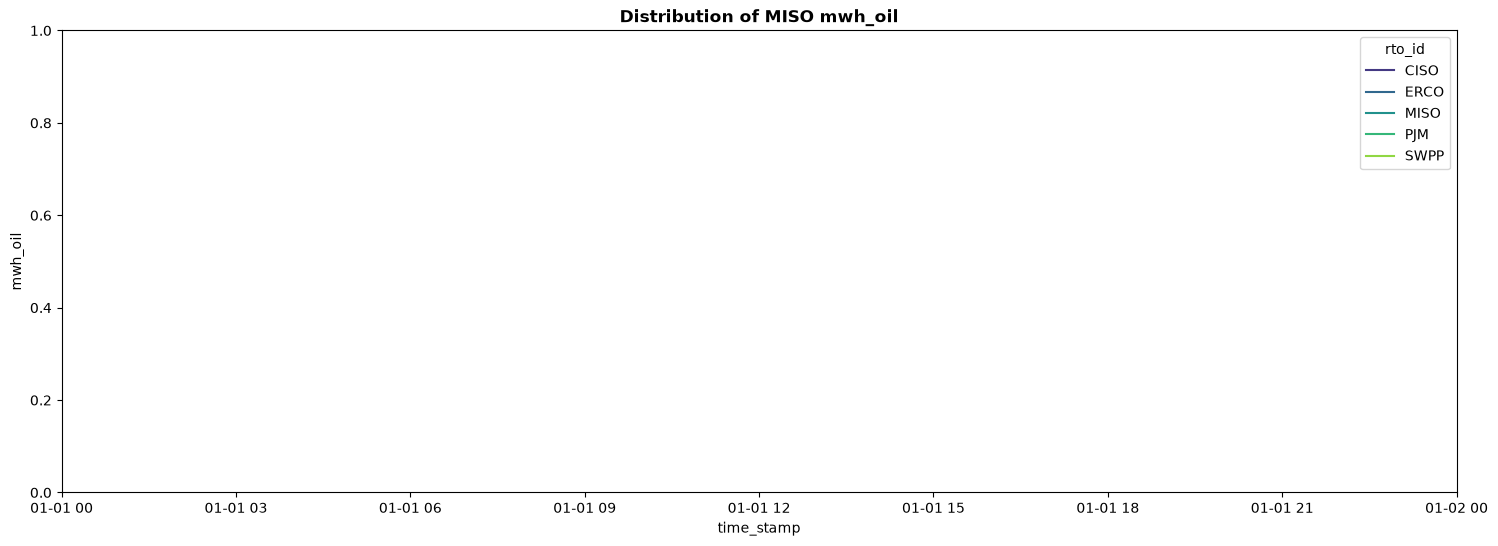

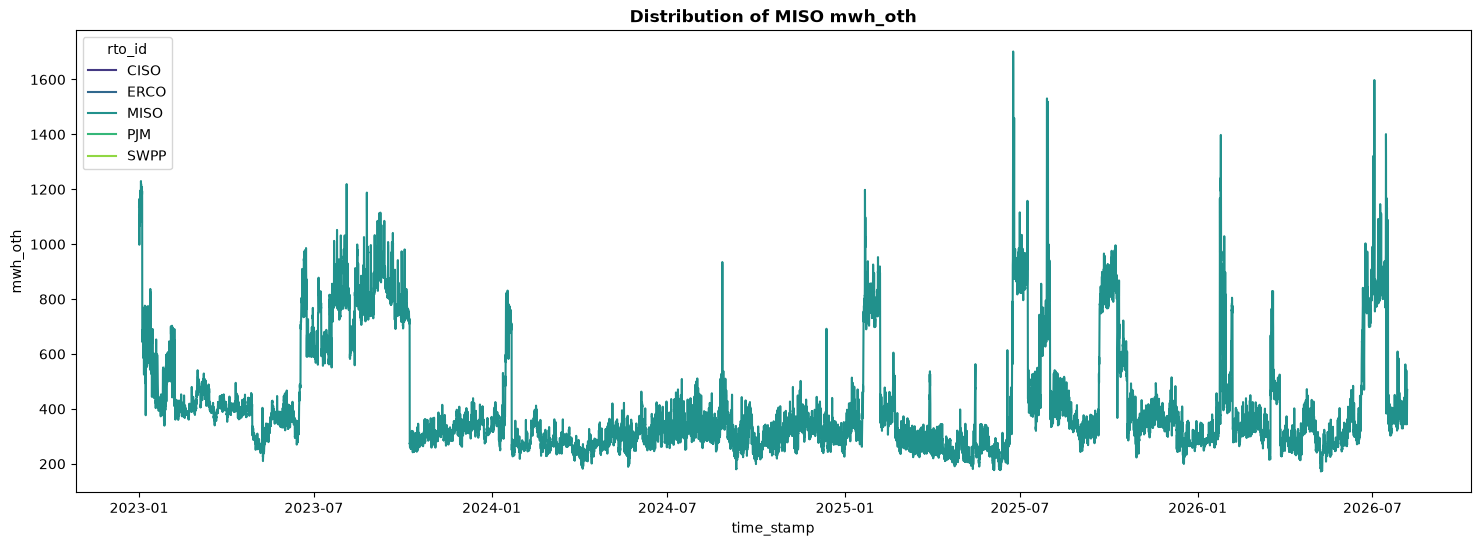

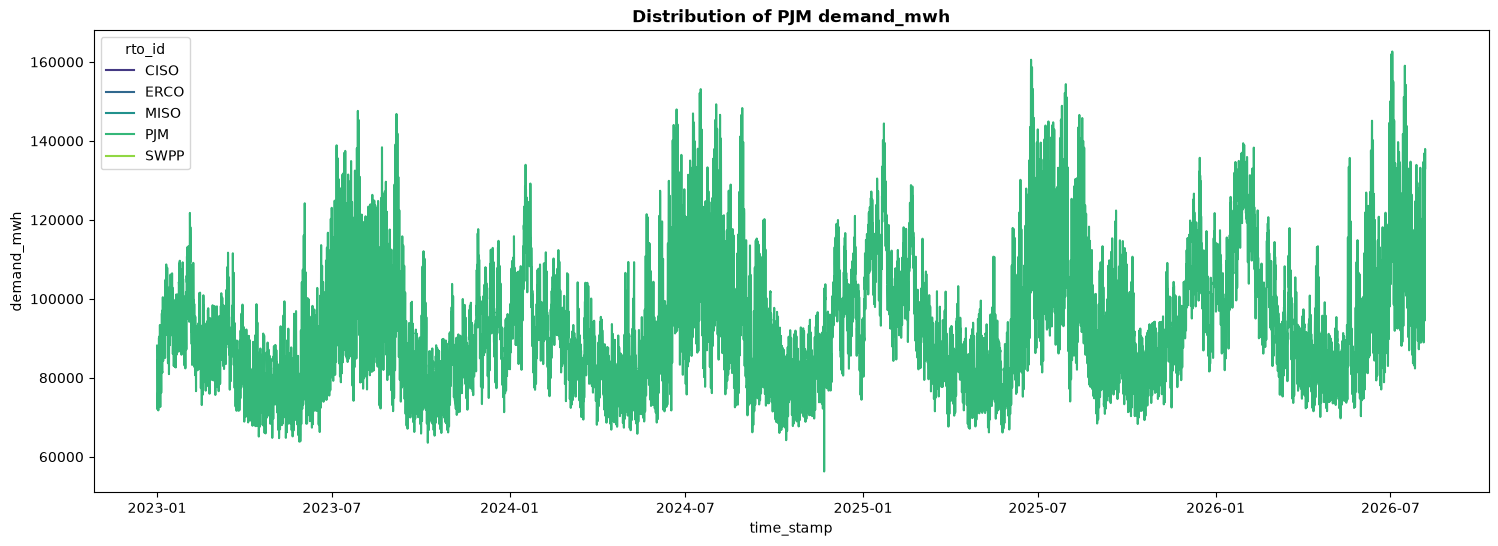

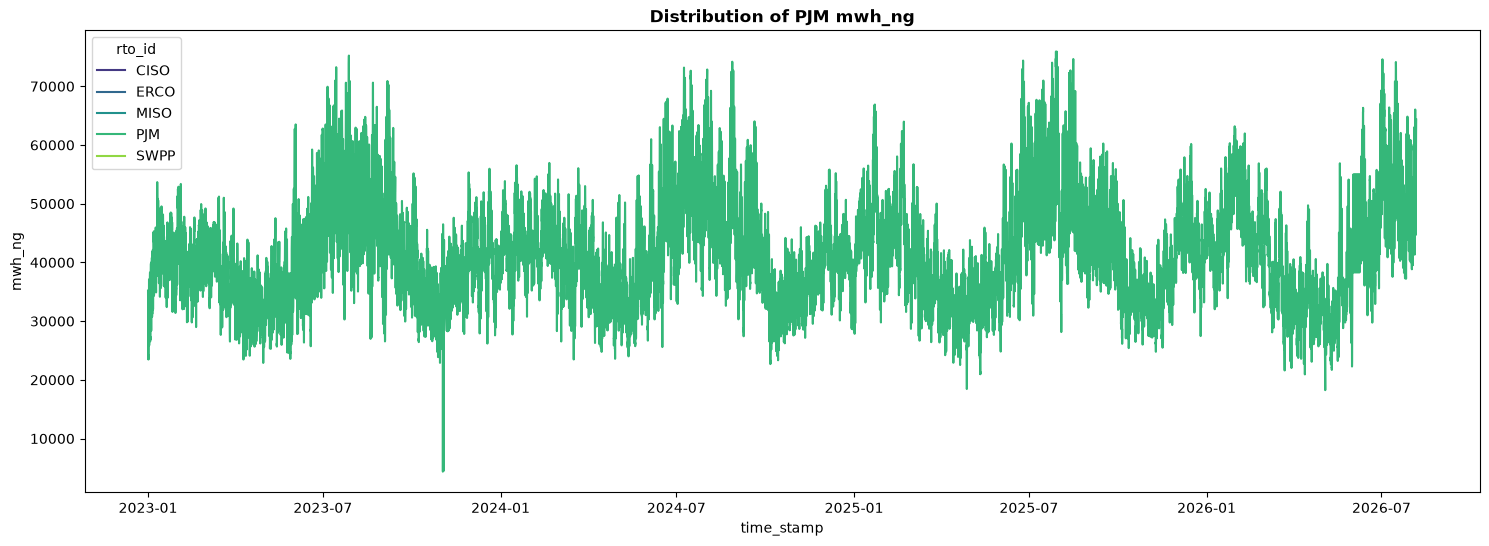

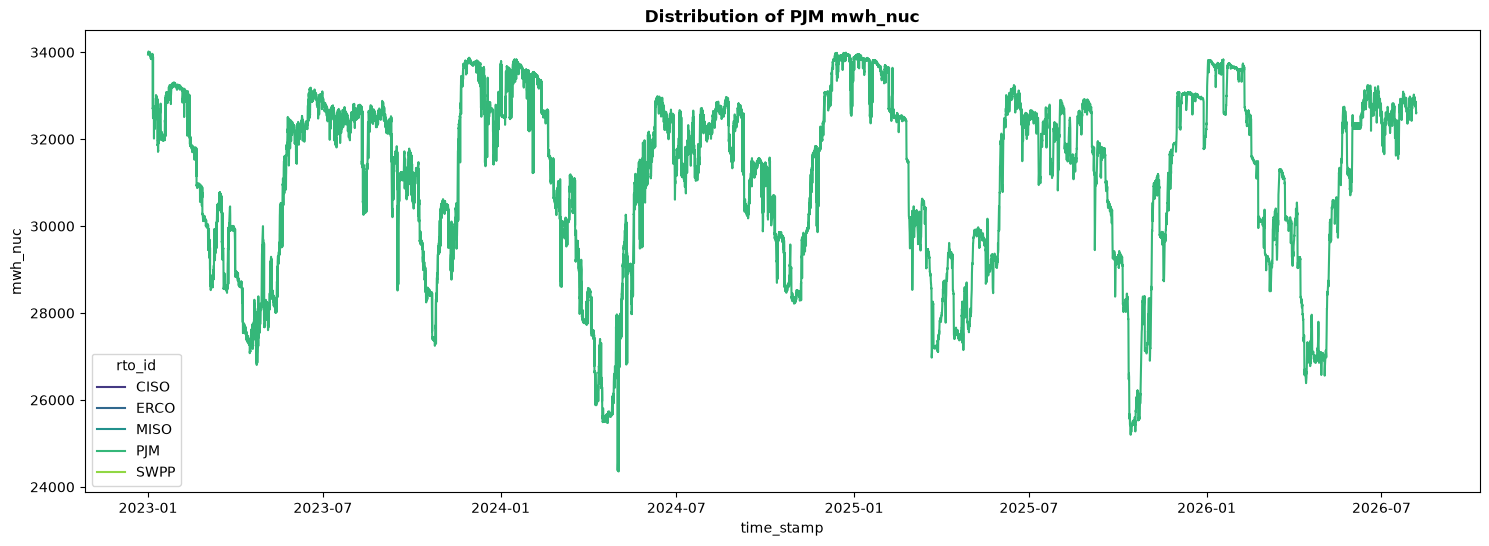

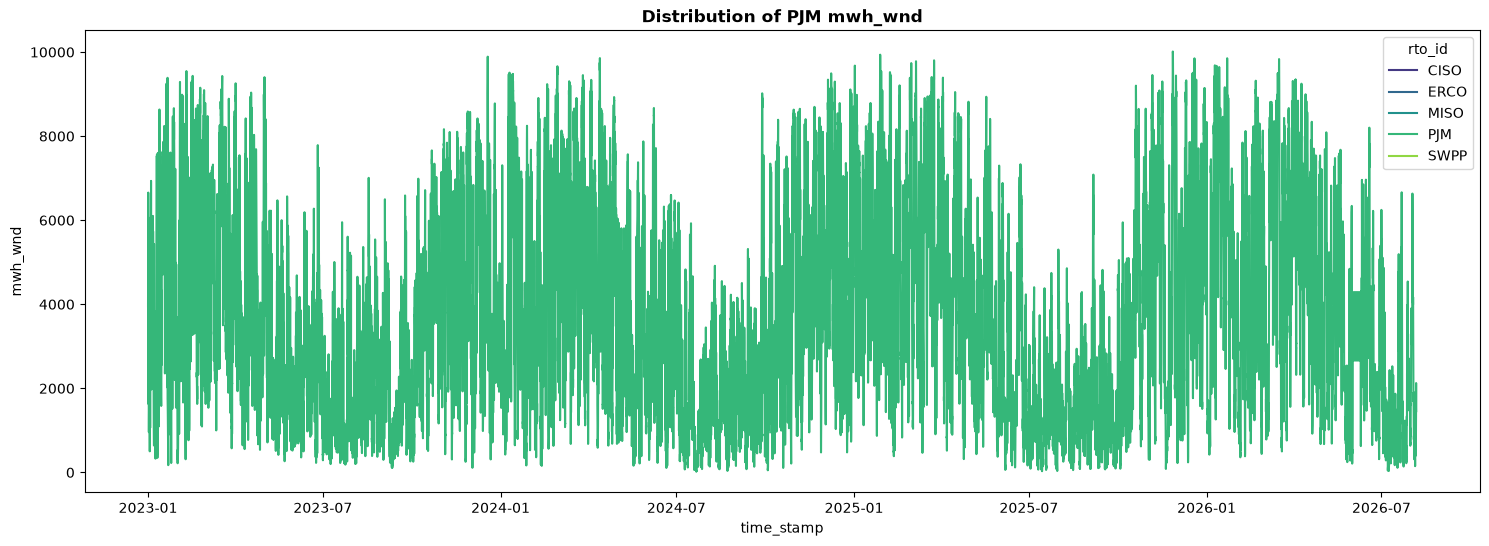

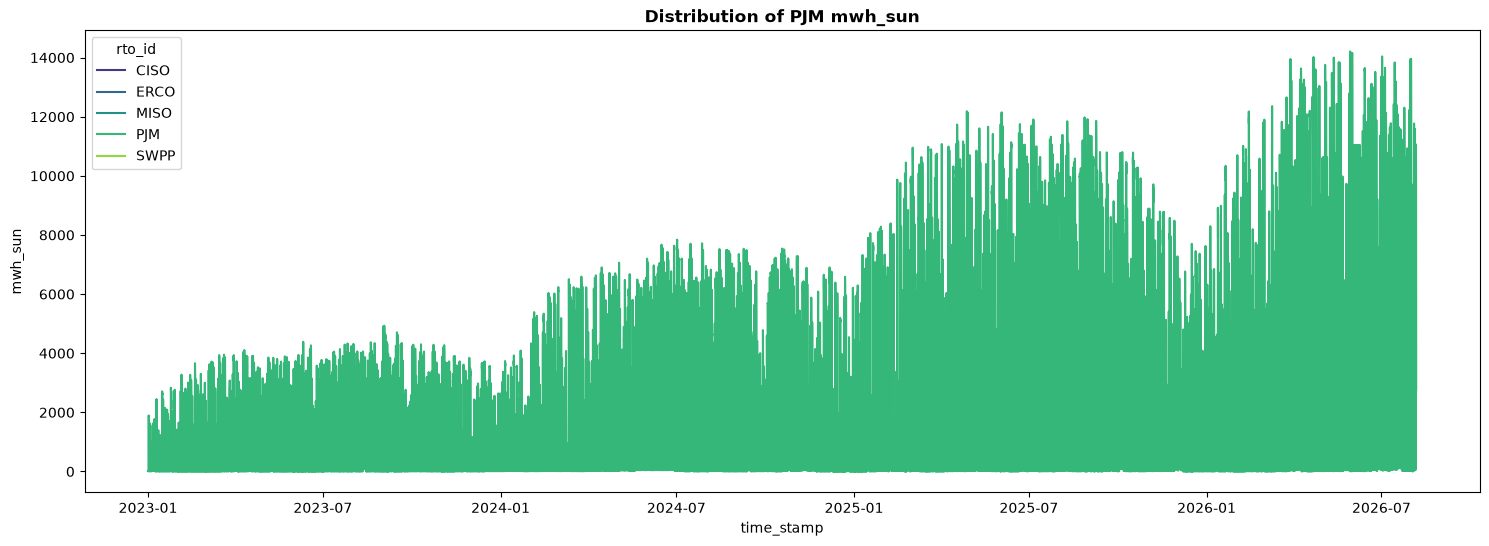

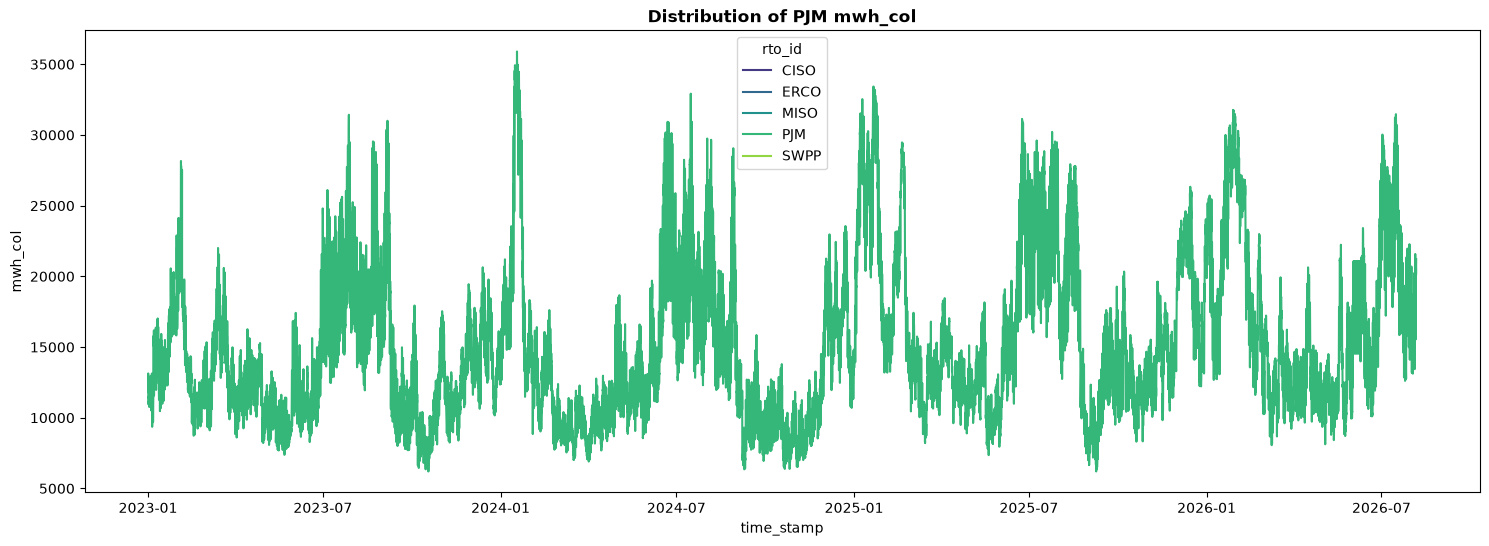

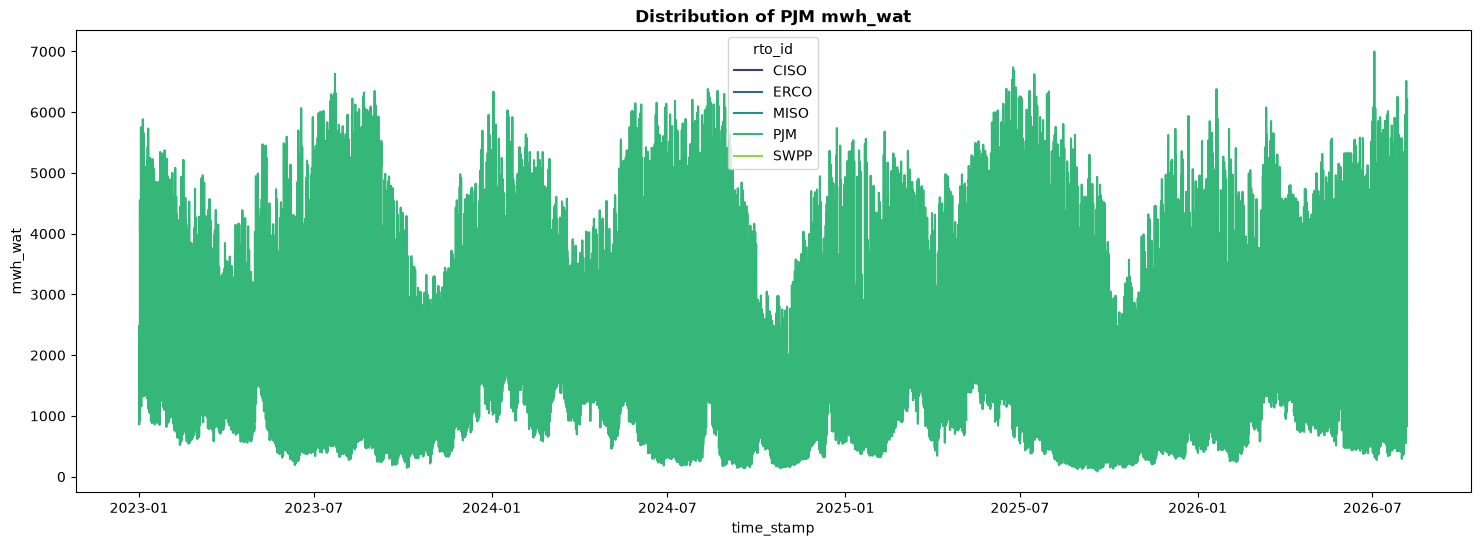

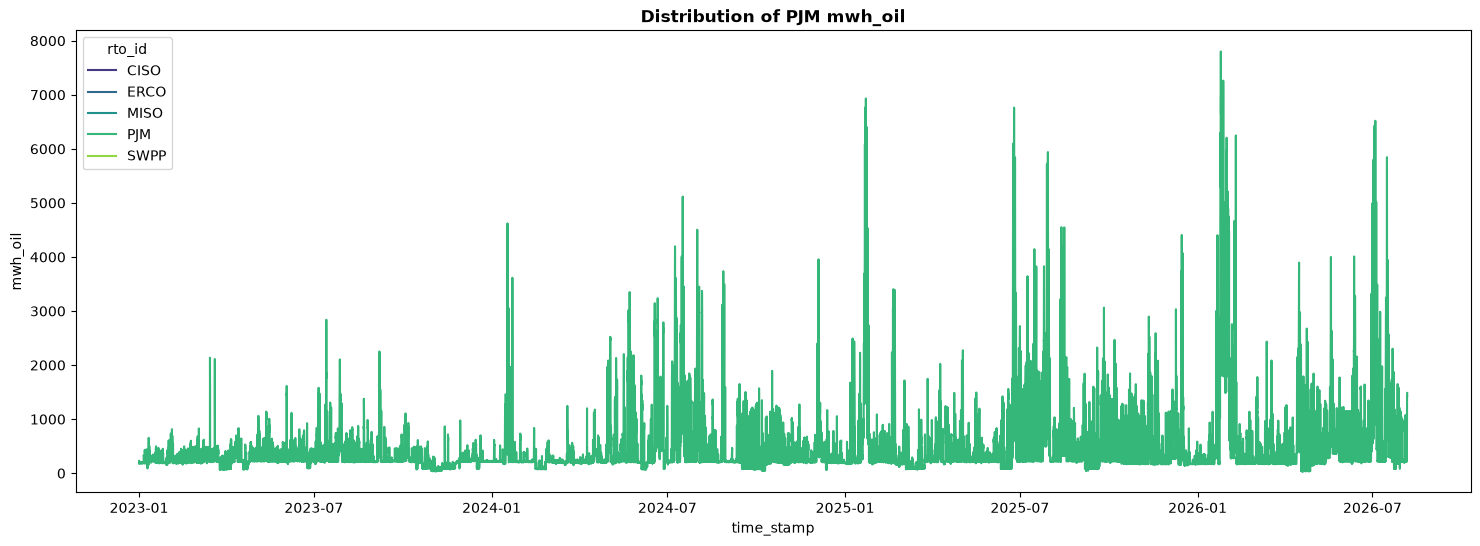

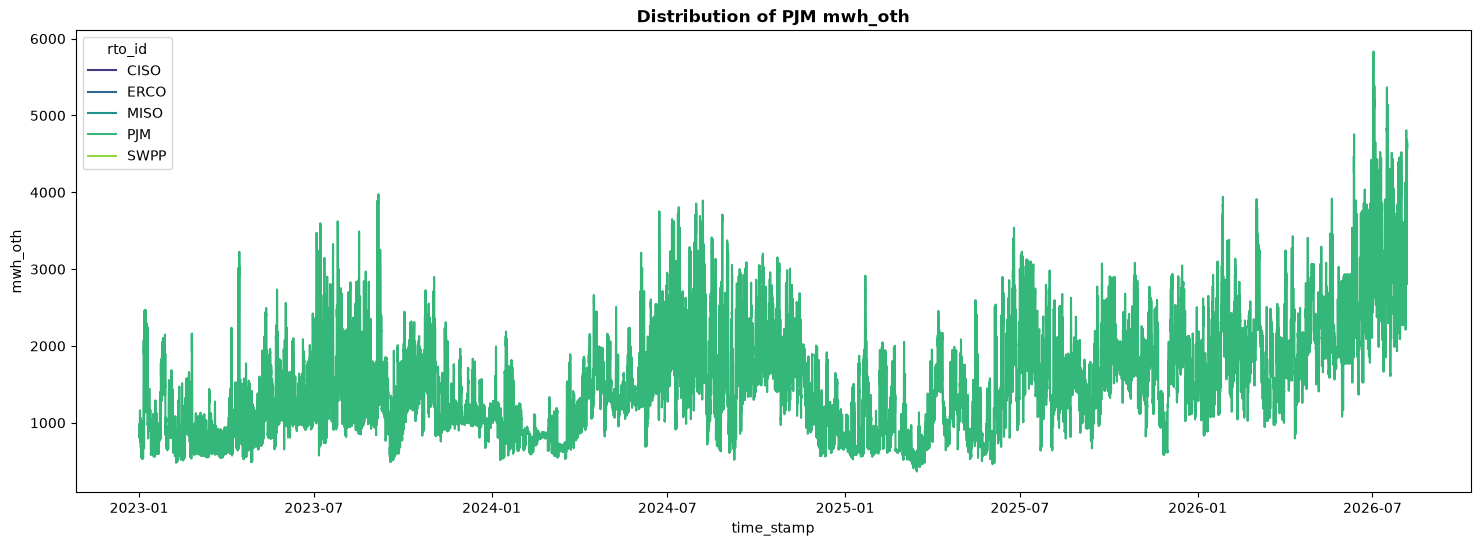

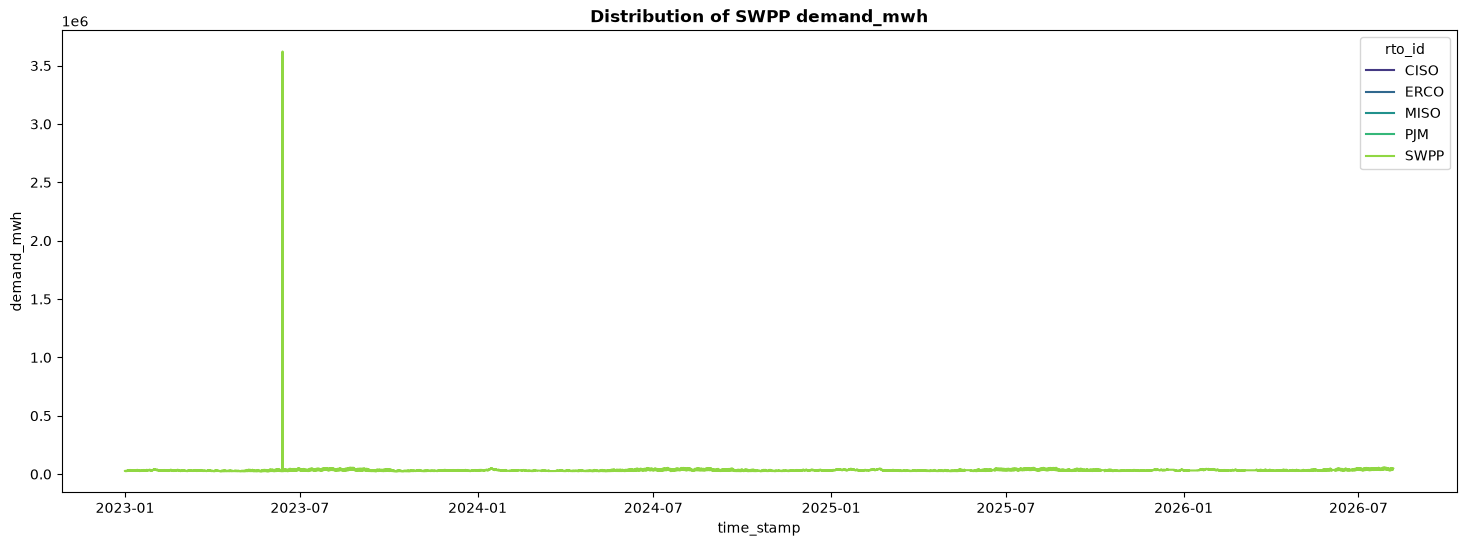

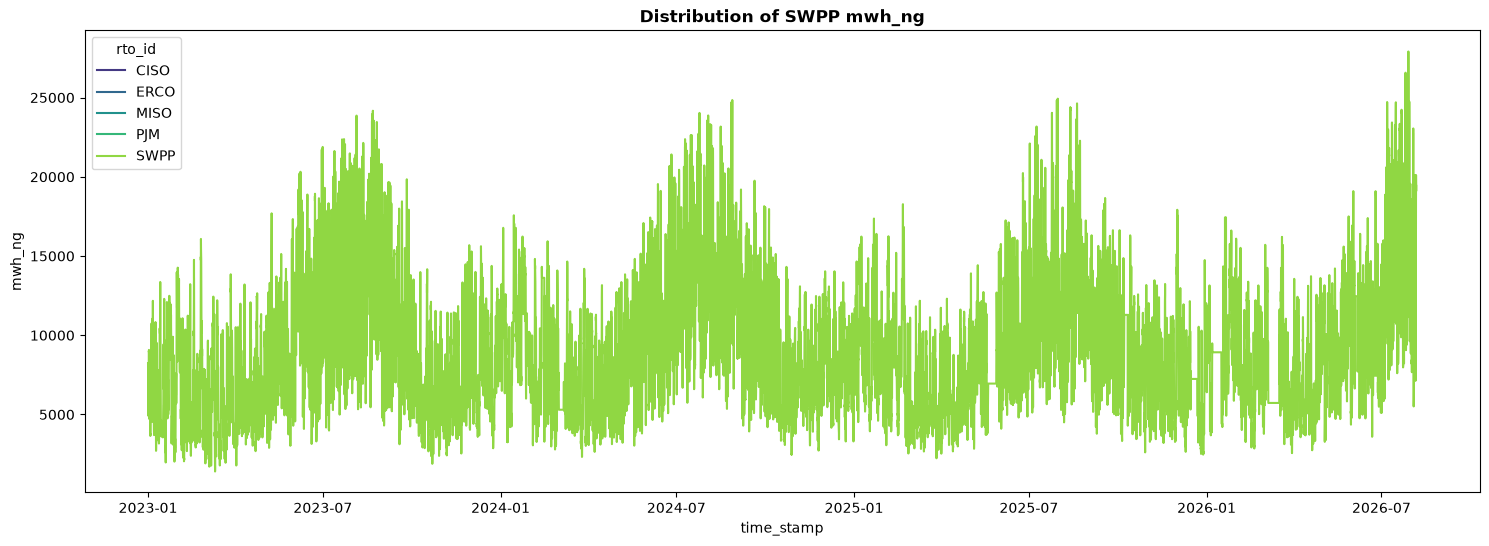

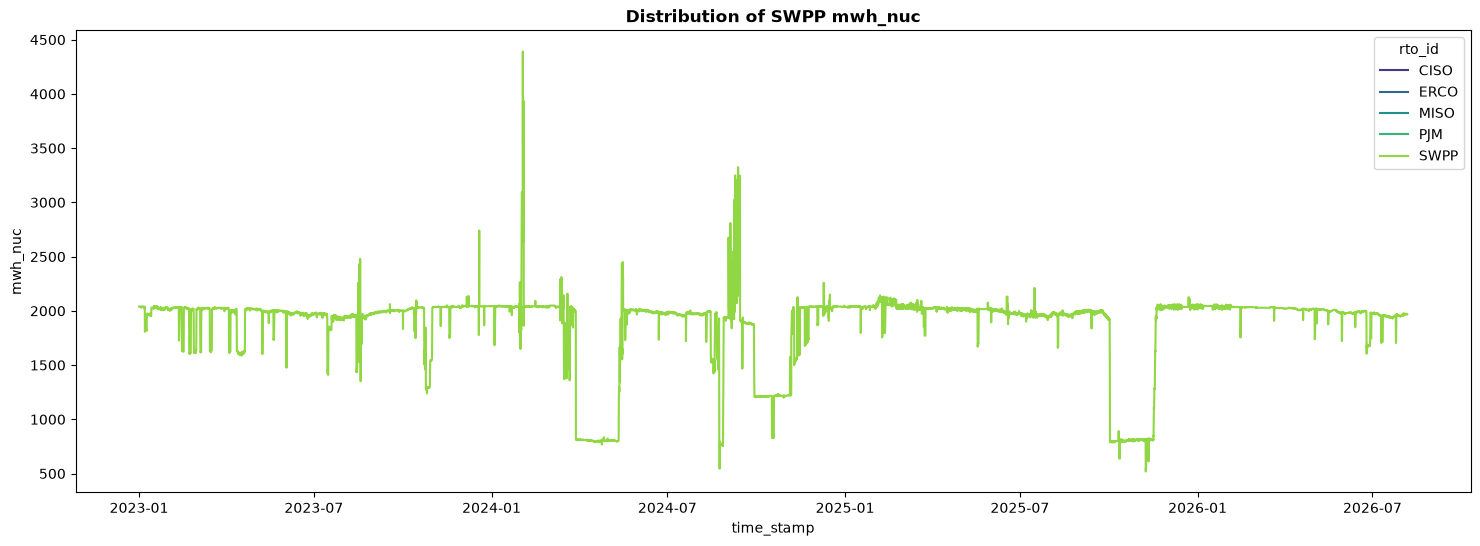

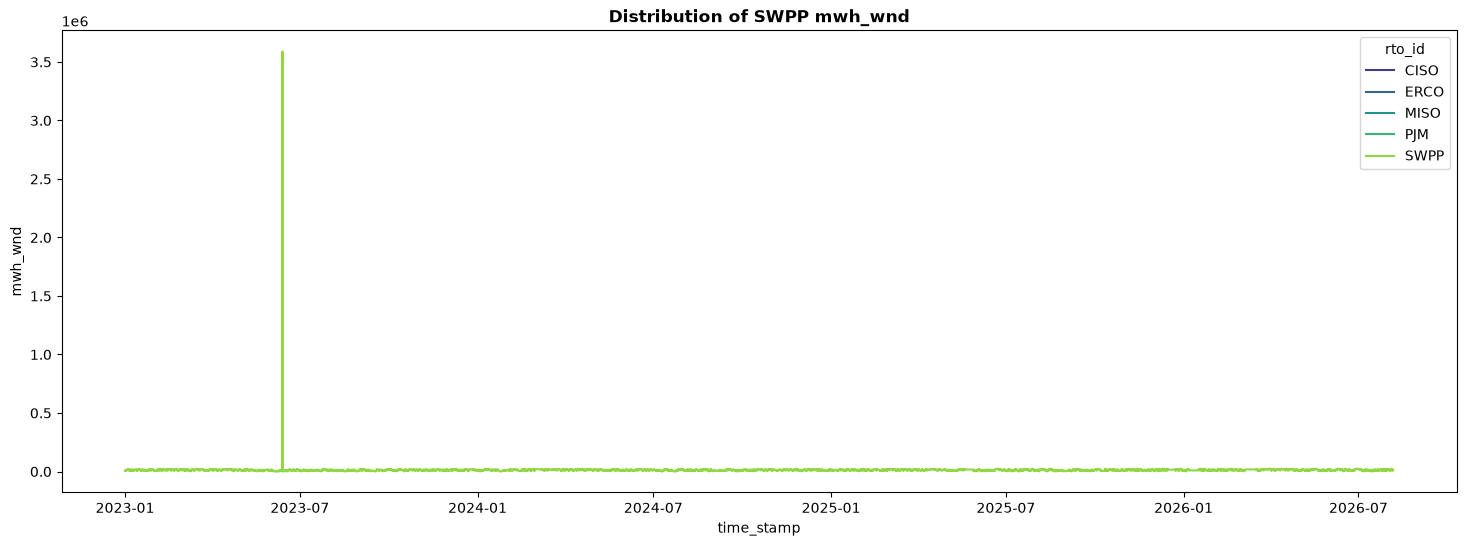

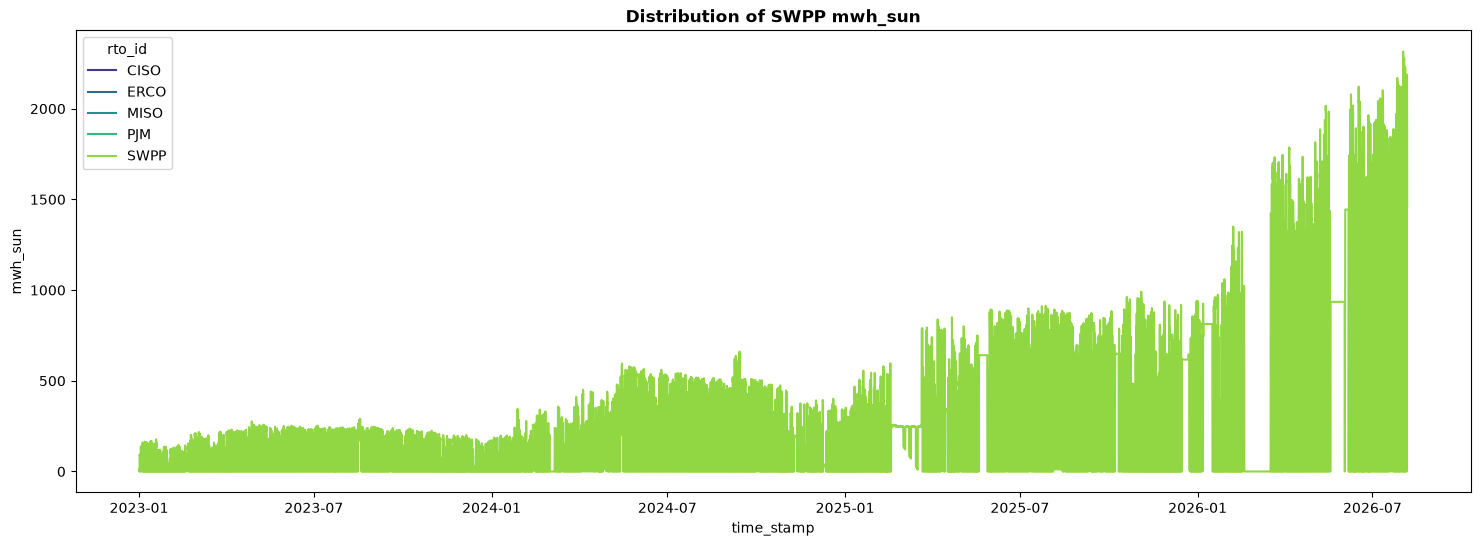

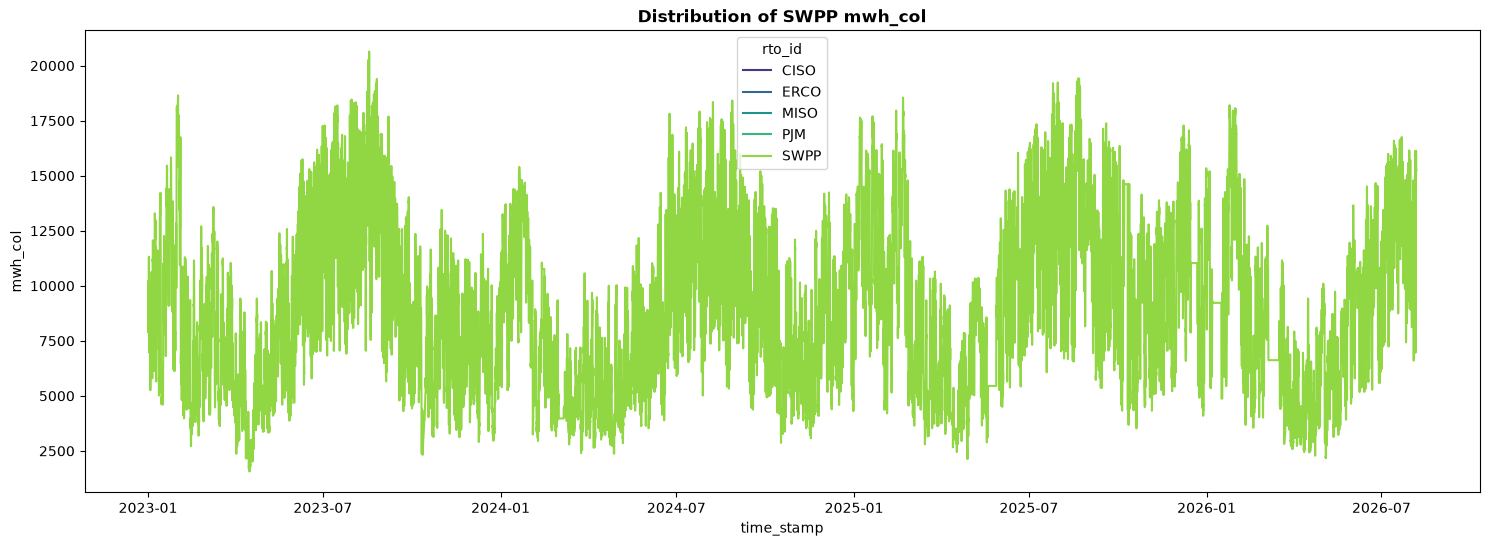

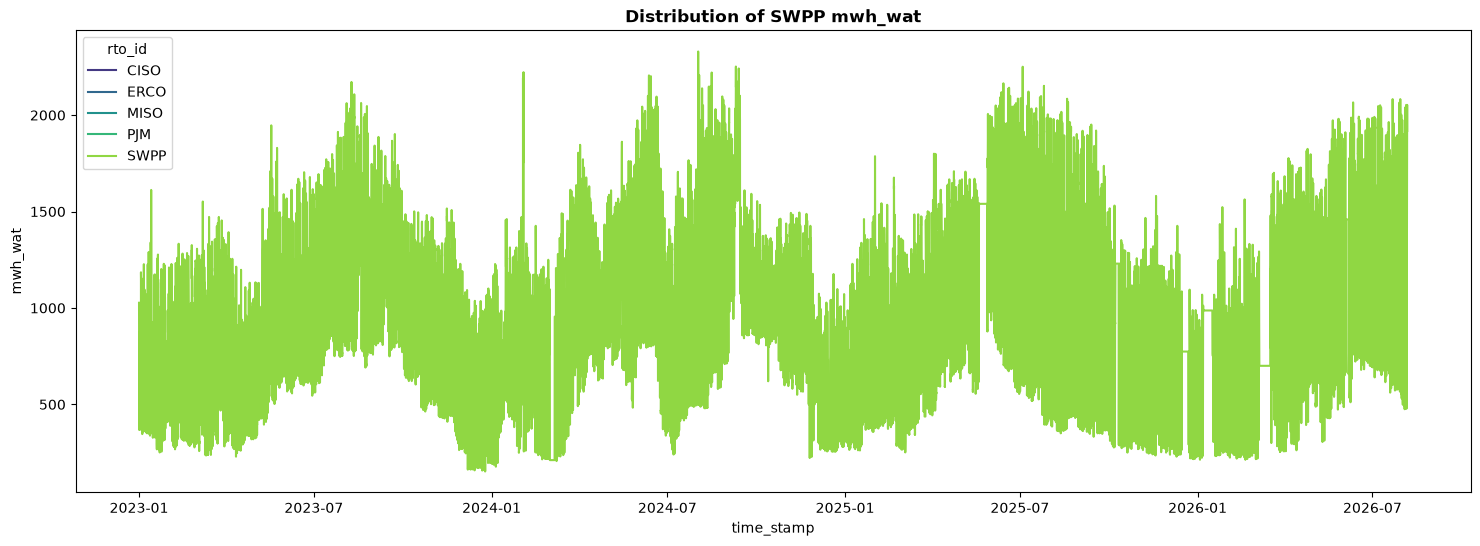

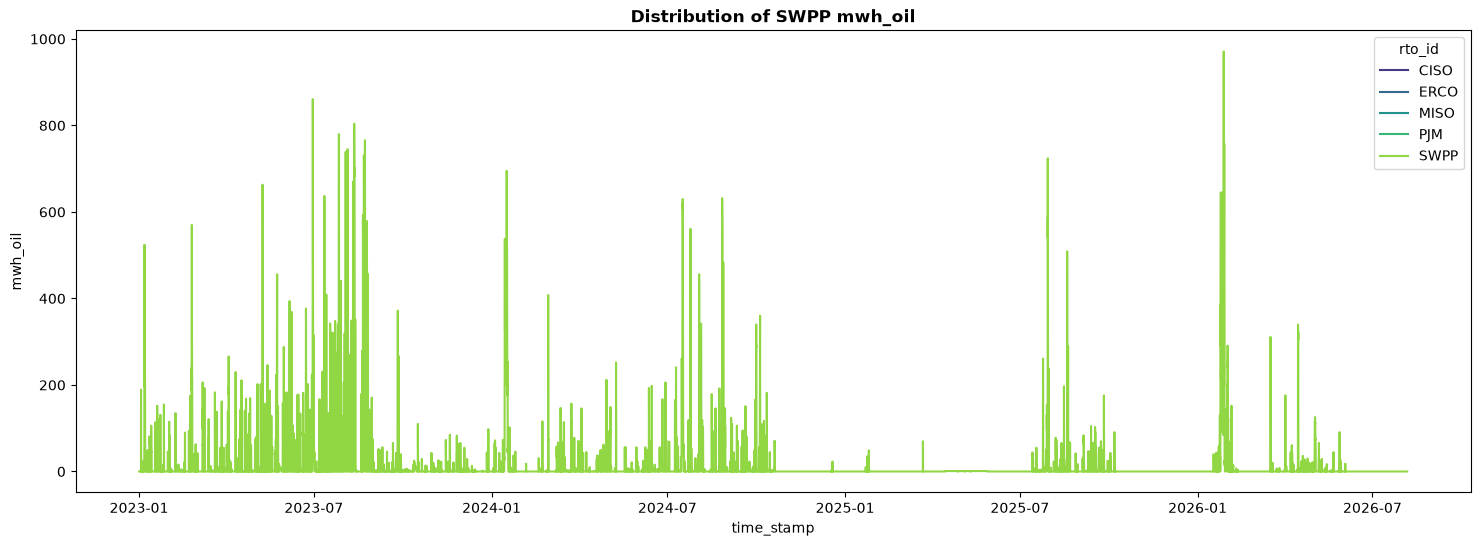

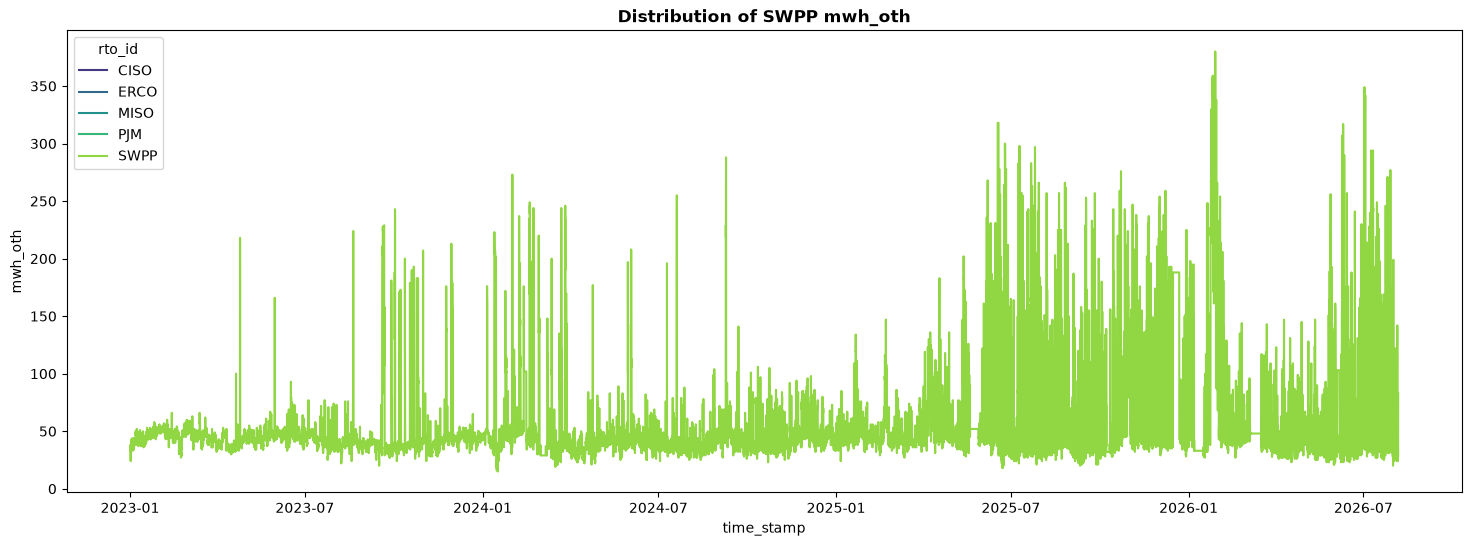

In [8]:
numeric = df.select_dtypes(include='number').columns
for rto in df['rto_id'].unique():
    curr = df[df['rto_id']==rto]

    for col in numeric:
        plt.figure(figsize=(18, 6))
        sns.lineplot(x=curr['time_stamp'], y=curr[col], hue=df['rto_id'], palette='viridis')
        plt.title(f'Distribution of {rto} {col}', fontsize=12, fontweight='bold')
        plt.show()
    print(' ')

## **3.3. Data Distribution**
---

### 3.3.1. Categorical Data Distribution

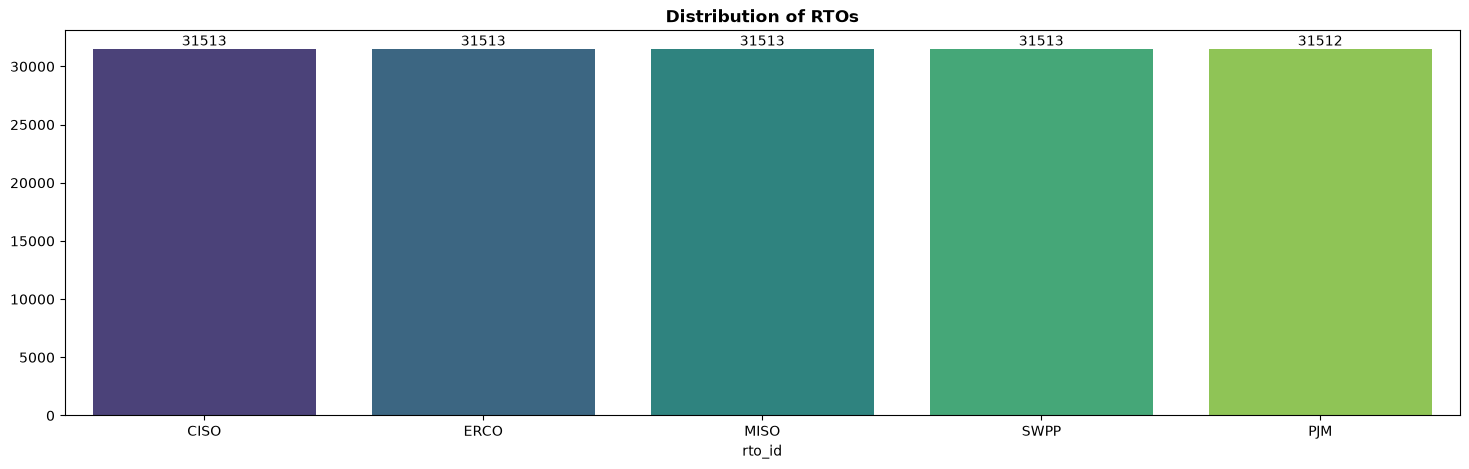

In [9]:
plt.figure(figsize=(18, 5))
v_cnt = df['rto_id'].value_counts()
ax = sns.barplot(x=v_cnt.index, y=v_cnt.values, palette='viridis', hue=v_cnt.index)
for val in ax.containers:
    label = [int(v.get_height()) for v in val]
    ax.bar_label(val, labels=label, label_type='edge')
plt.title('Distribution of RTOs', fontsize=12, fontweight='bold')
plt.show()

### 3.3.2. Numerical Data Distribution

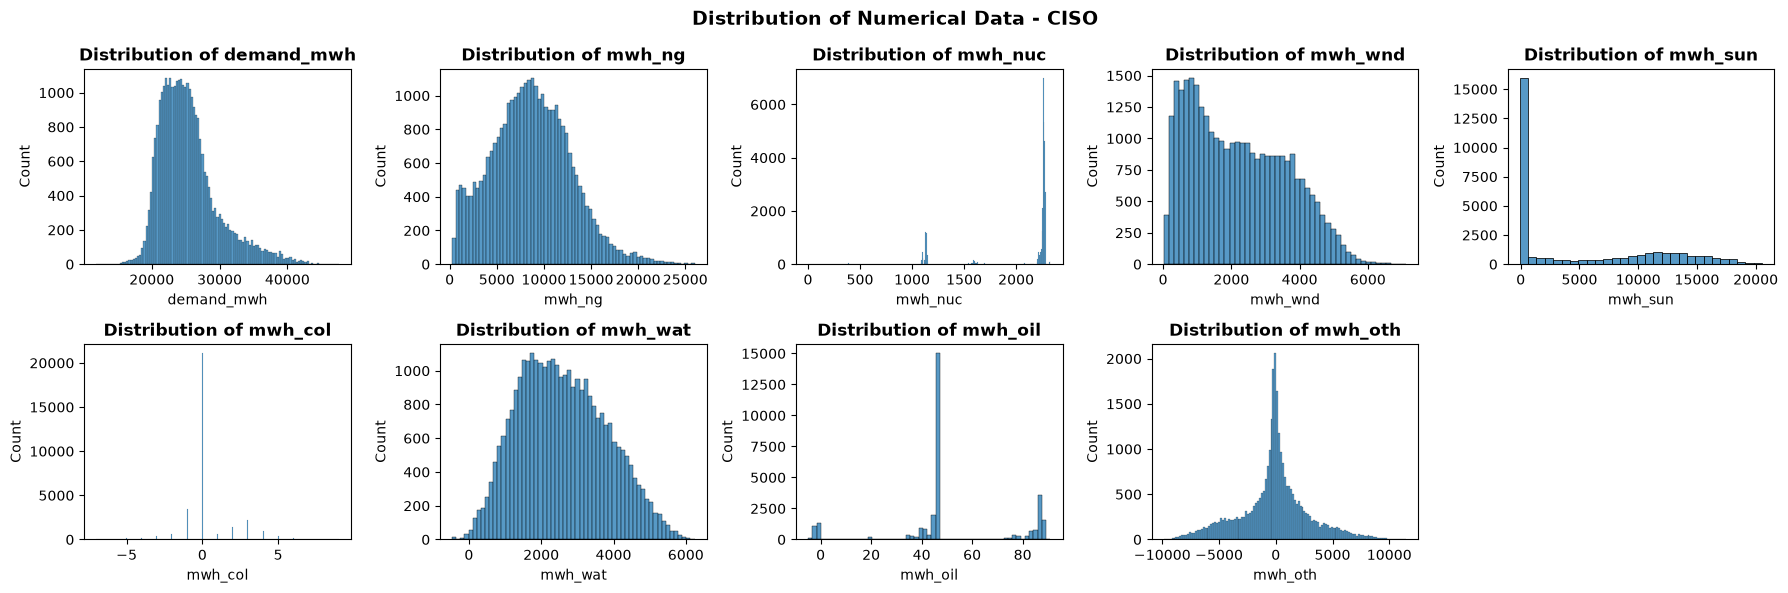

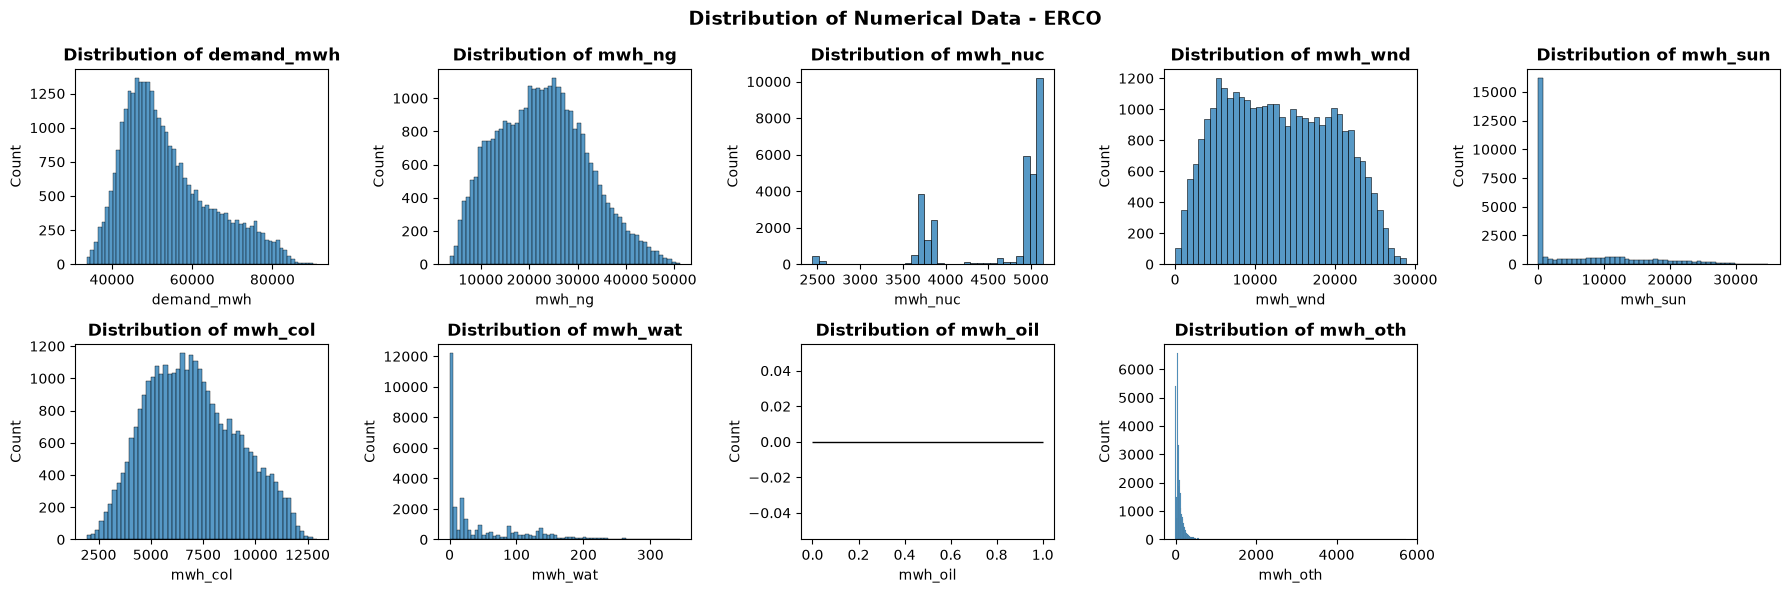

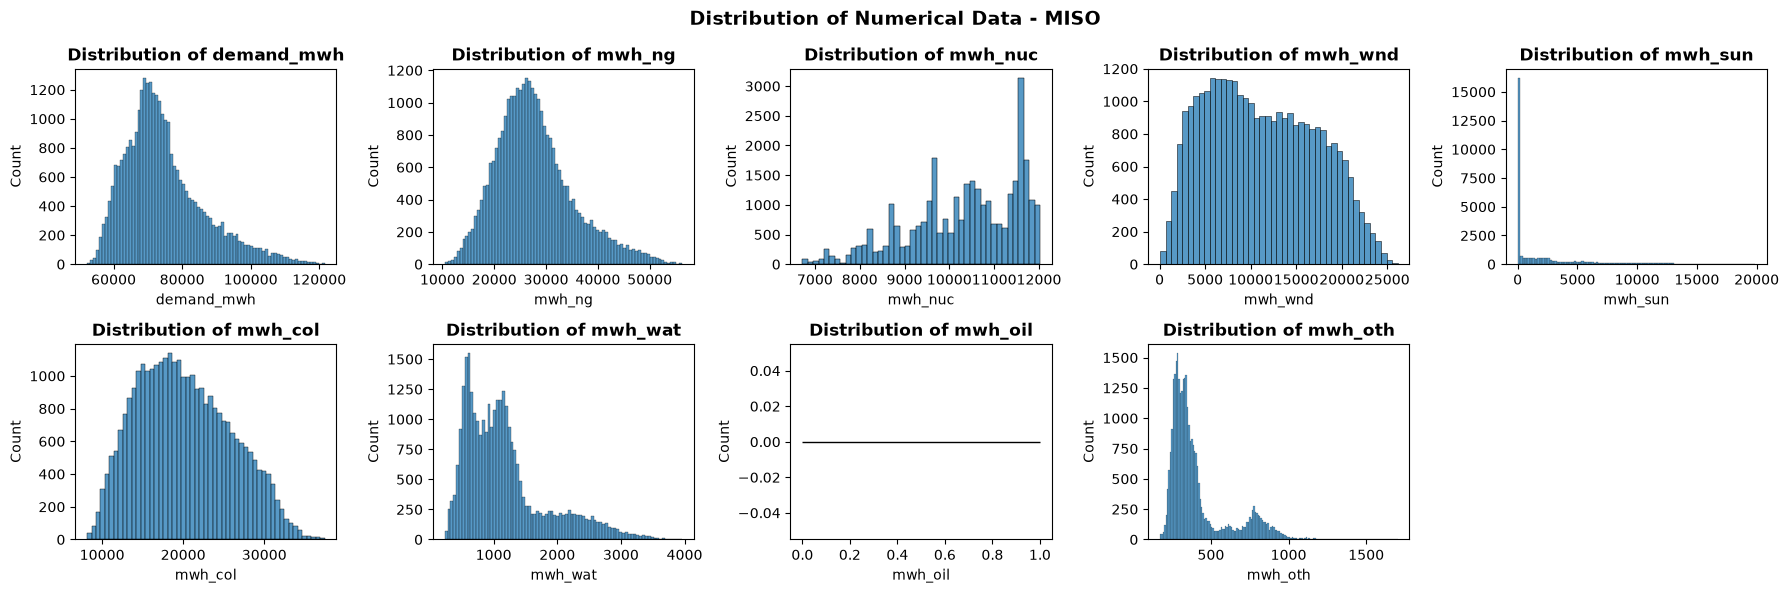

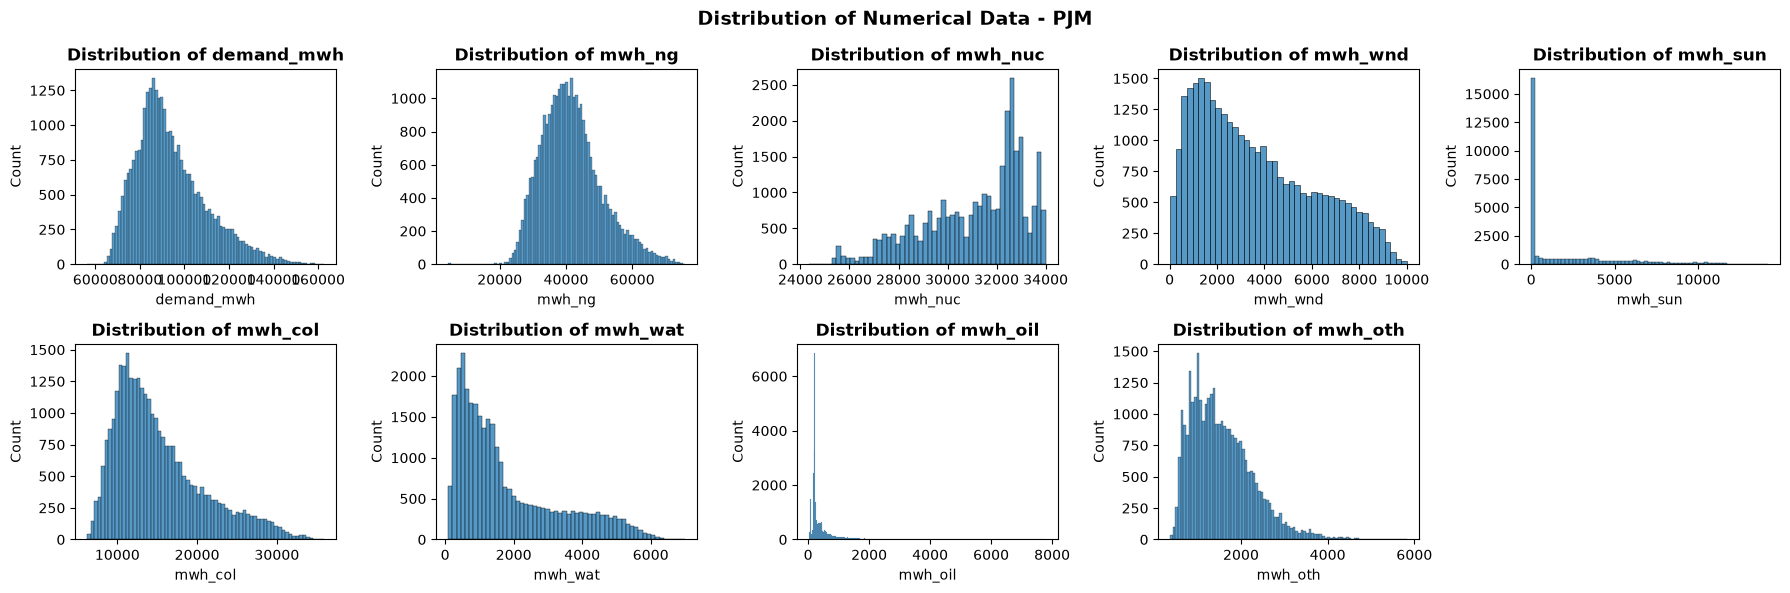

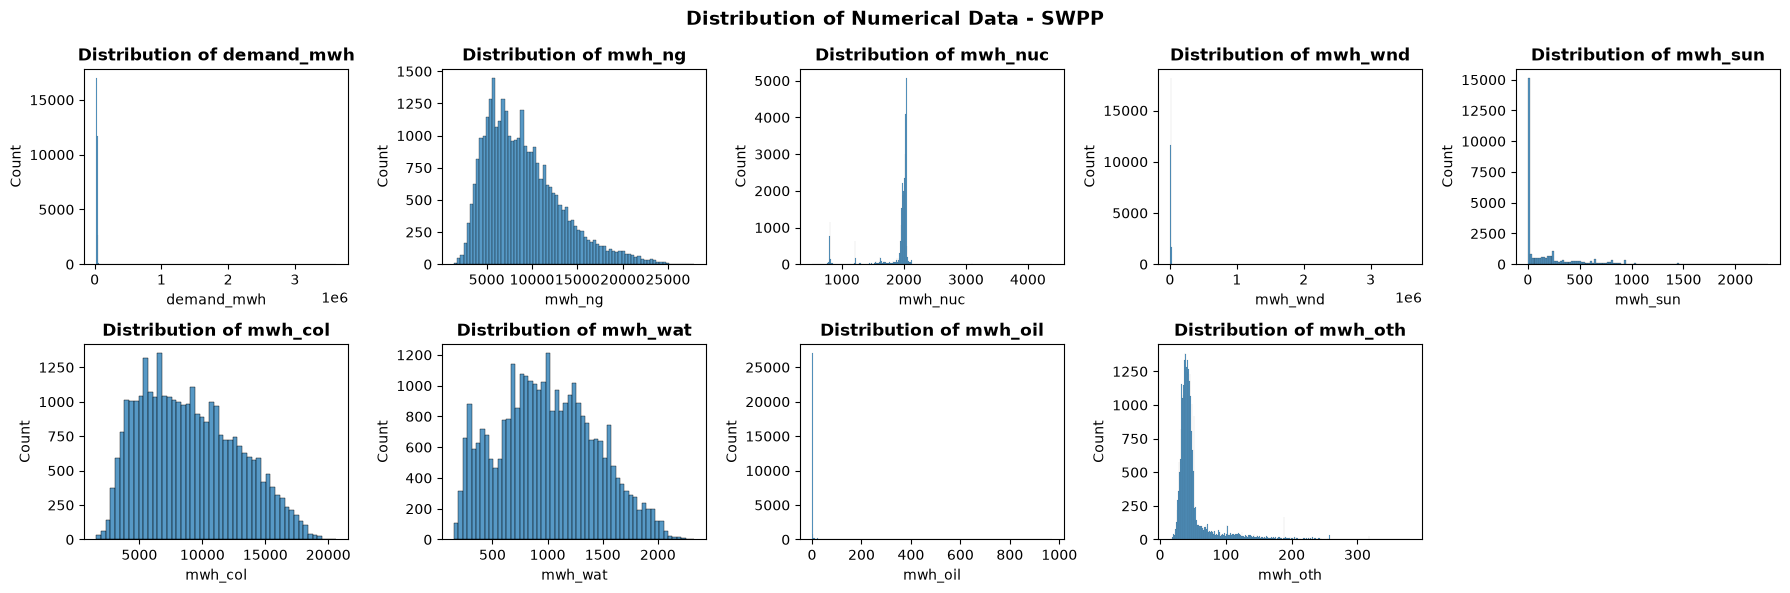

In [10]:
numeric = df.select_dtypes(include='number').columns
for rto in df['rto_id'].unique():
    curr = df[df['rto_id']==rto]

    plt.figure(figsize=(18, 6))
    for i, col in enumerate(numeric):
        plt.subplot(2, 5, i+1)
        sns.histplot(curr[col])
        plt.title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    plt.suptitle(f'Distribution of Numerical Data - {rto}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## **3.4. Outliers Detection**
---

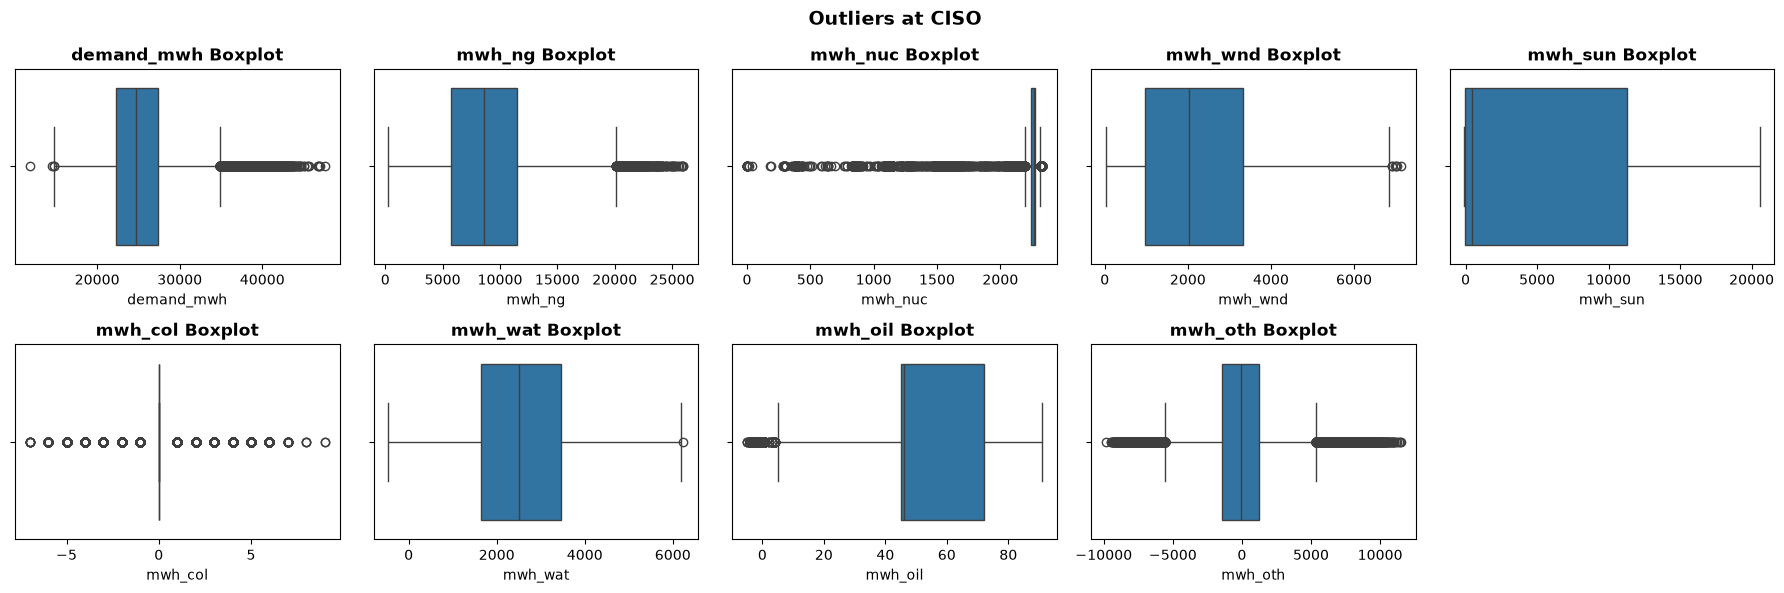

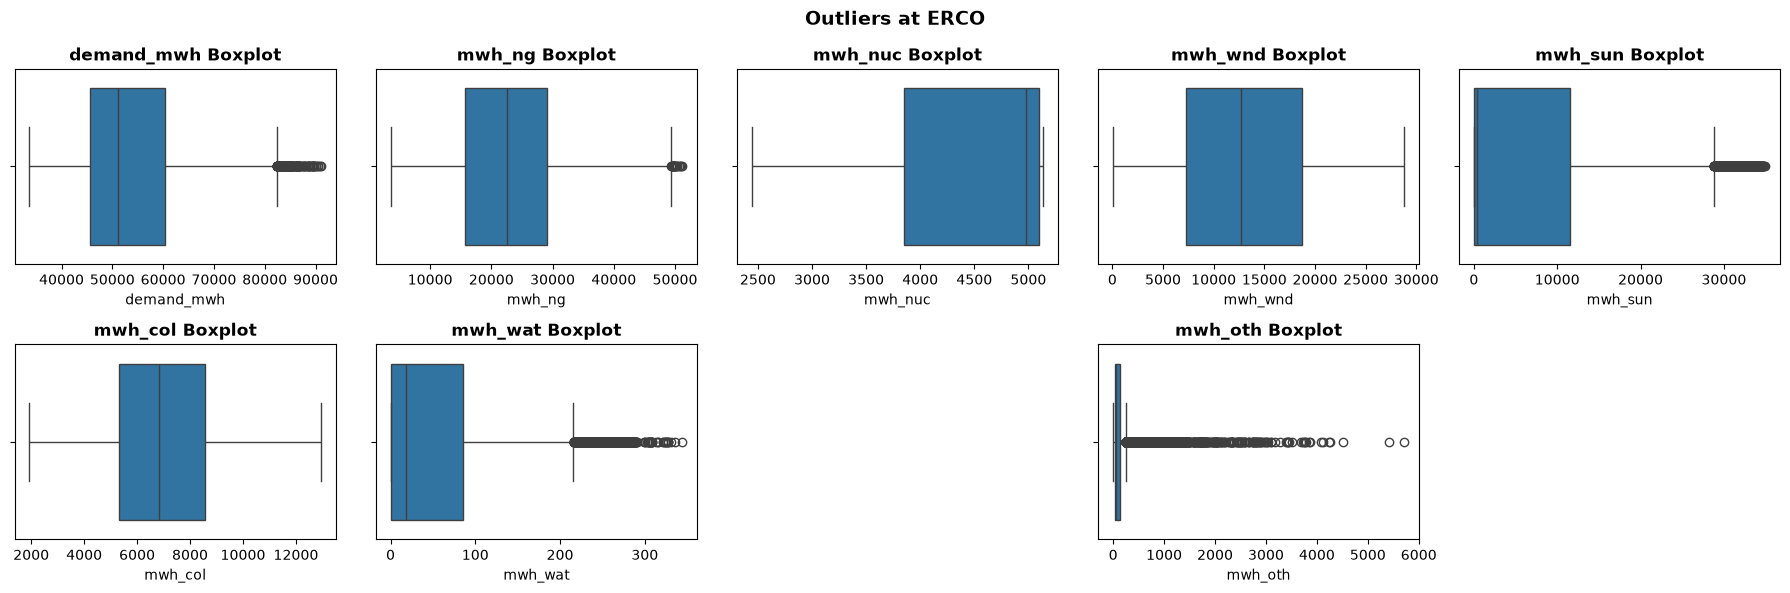

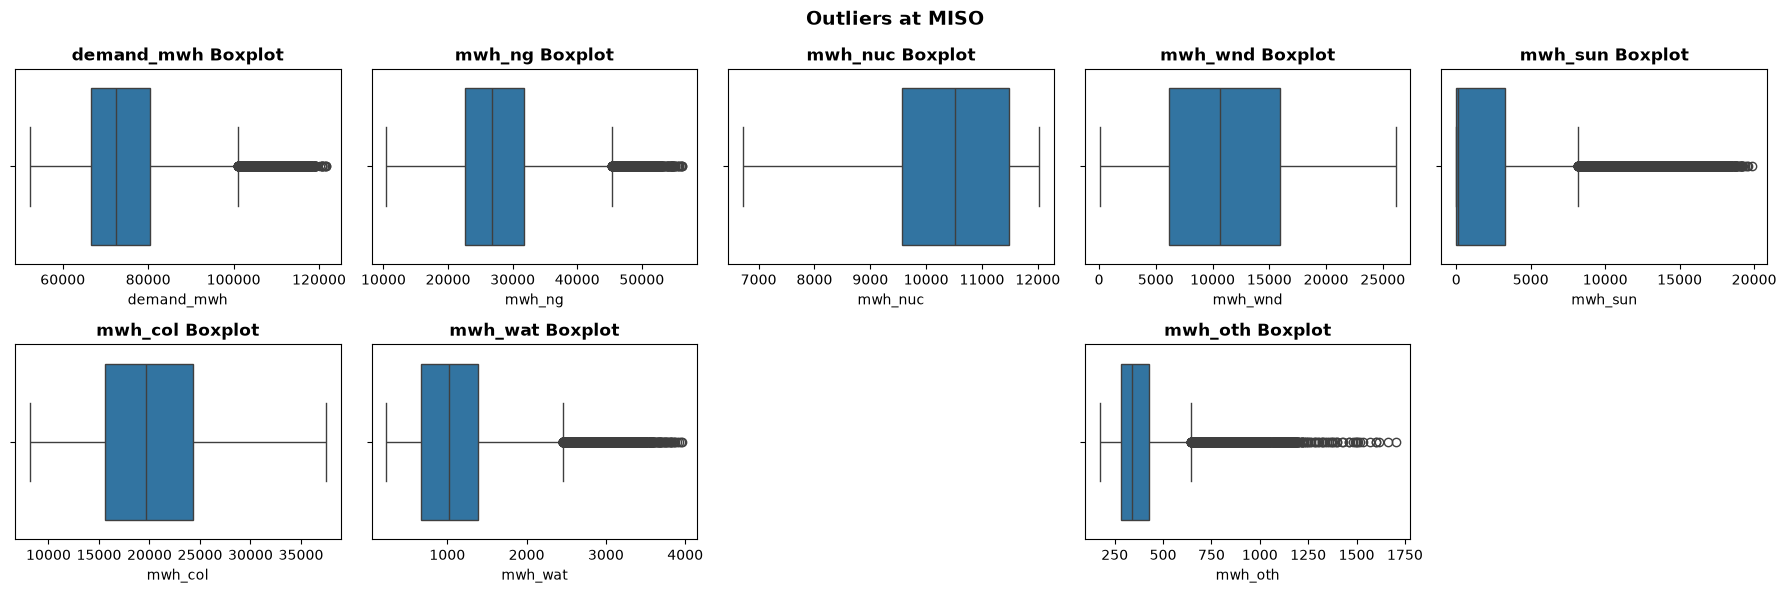

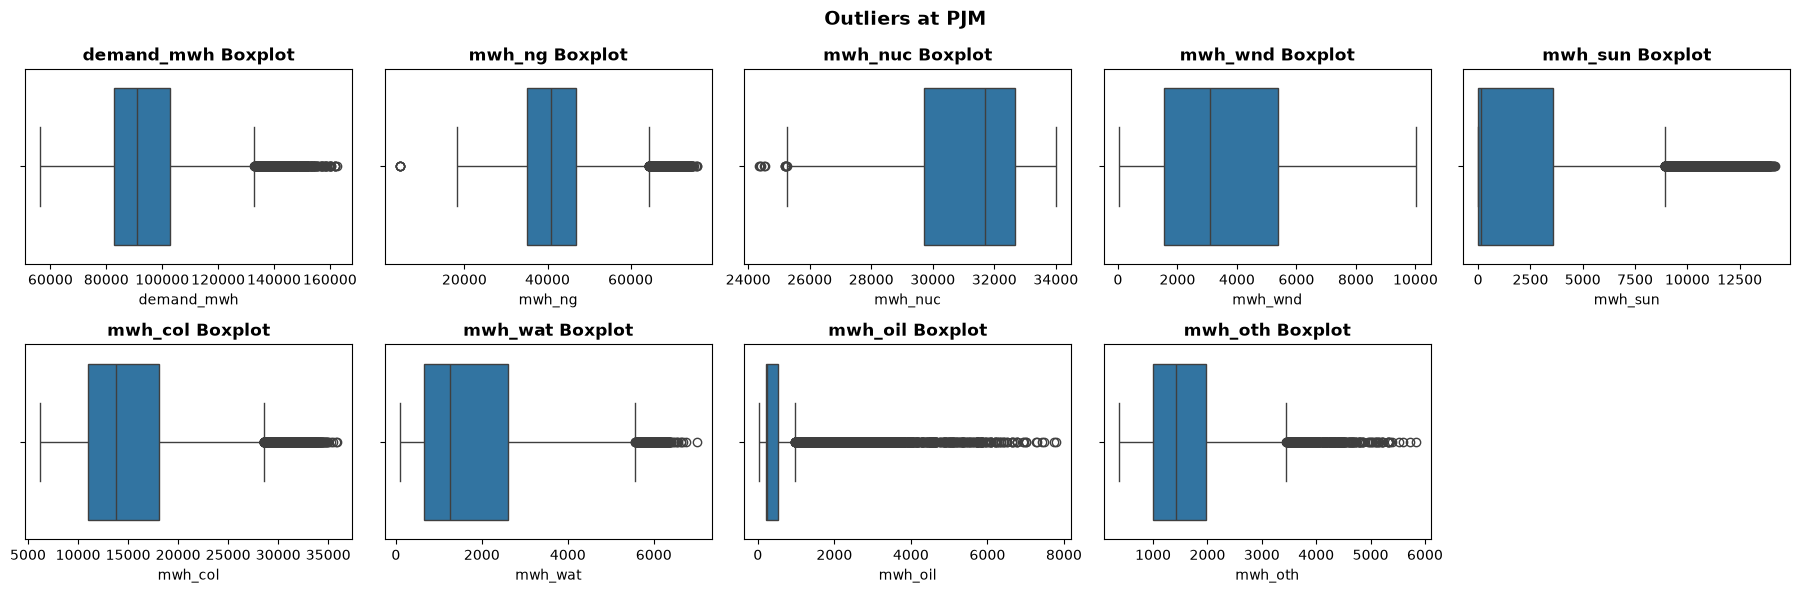

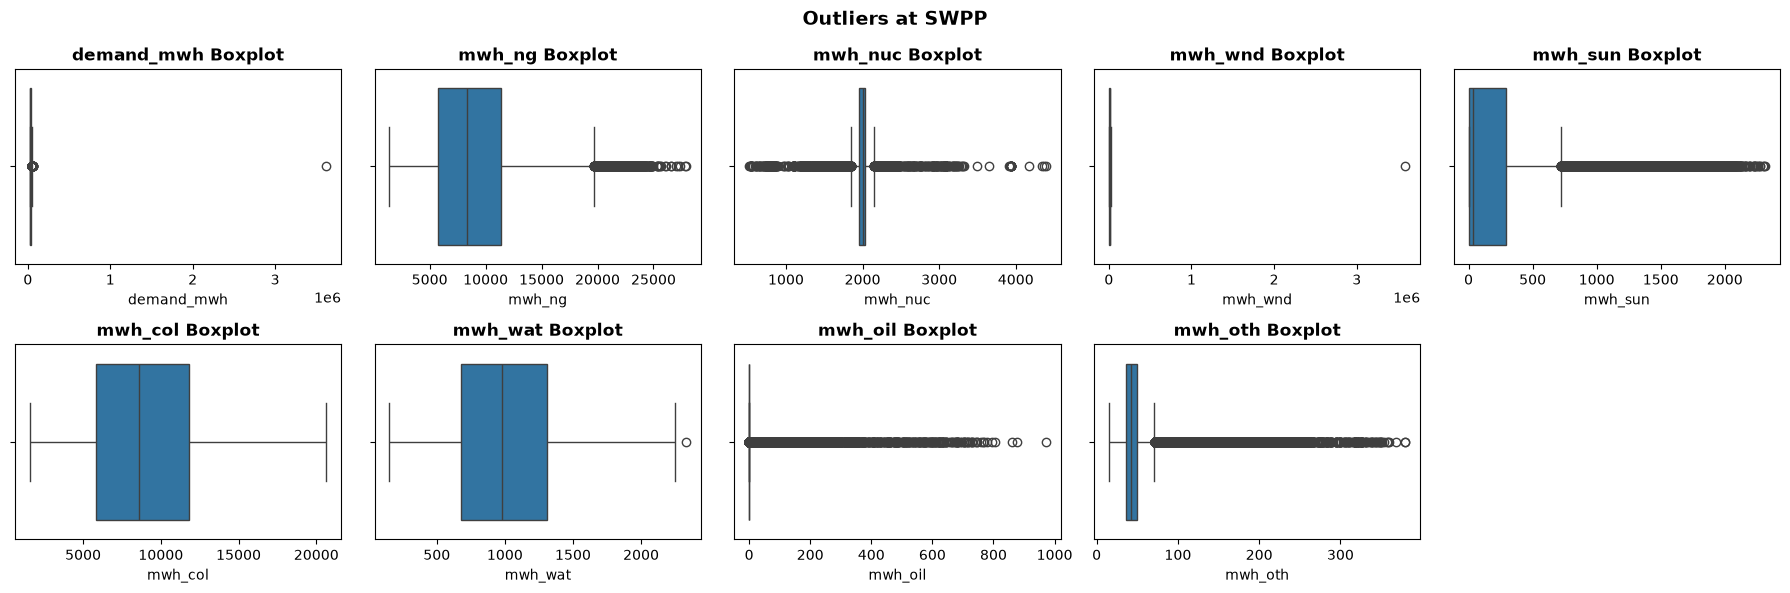

In [11]:
numeric = df.select_dtypes(include='number').columns
for rto in df['rto_id'].unique():
    curr = df[df['rto_id']==rto]

    plt.figure(figsize=(18, 6))
    for i, col in enumerate(numeric):
        if pd.isna(curr[col]).all():
            continue
        plt.subplot(2, 5, i+1)
        sns.boxplot(x=curr[col])
        plt.title(f'{col} Boxplot', fontsize=12, fontweight='bold')
    plt.suptitle(f'Outliers at {rto}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# **4. Pre-Processing**
---

In [12]:
df_n = df.copy()

## **4.1. Handling Missing Values**
---

In [13]:
numeric = df_n.select_dtypes(include='number').columns
for rto in df_n['rto_id'].unique():
    curr = df_n[df_n['rto_id']==rto]

    print(f'{rto} Missing Values:')
    for col in df_n.columns:
        pct = curr[col].isnull().sum() / len(curr)
        print(f'{col}: {curr[col].isnull().sum()} - {pct*100} % of records')
    print(' ')

CISO Missing Values:
id_demand_elec_generated: 0 - 0.0 % of records
time_stamp: 0 - 0.0 % of records
rto_id: 0 - 0.0 % of records
rto_full_name: 0 - 0.0 % of records
demand_mwh: 2 - 0.006346587122774729 % of records
mwh_ng: 49 - 0.15549138450798083 % of records
mwh_nuc: 28 - 0.0888522197188462 % of records
mwh_wnd: 26 - 0.08250563259607147 % of records
mwh_sun: 26 - 0.08250563259607147 % of records
mwh_col: 34 - 0.10789198108717038 % of records
mwh_wat: 49 - 0.15549138450798083 % of records
mwh_oil: 29 - 0.09202551328023356 % of records
mwh_oth: 26 - 0.08250563259607147 % of records
 
ERCO Missing Values:
id_demand_elec_generated: 0 - 0.0 % of records
time_stamp: 0 - 0.0 % of records
rto_id: 0 - 0.0 % of records
rto_full_name: 0 - 0.0 % of records
demand_mwh: 0 - 0.0 % of records
mwh_ng: 24 - 0.07615904547329673 % of records
mwh_nuc: 25 - 0.07933233903468409 % of records
mwh_wnd: 24 - 0.07615904547329673 % of records
mwh_sun: 28 - 0.0888522197188462 % of records
mwh_col: 24 - 0.0761590

In [14]:
list_df = []
numeric = df_n.select_dtypes(include='number').columns

for rto in df_n['rto_id'].unique():
    curr = df_n[df_n['rto_id']==rto]

    if rto=='ERCO' or rto=='MISO':
        curr['mwh_oil'] = curr['mwh_oil'].fillna(0)
    list_df.append(curr)

df_n = pd.concat(list_df, axis=0)

print(f'Length before missing data handling: {len(df_n)}')
for col in numeric:
    pct_nan_daily = df_n.groupby(by=['rto_id', pd.Grouper(key='time_stamp', freq='D')])[col].apply(lambda x: x.isna().sum()/24)
    valid_idx = pct_nan_daily[pct_nan_daily<=0.3].index

    df_n = df_n.set_index(['rto_id', df_n['time_stamp'].dt.floor('D')], drop=False).loc[valid_idx].reset_index(drop=True)
print(f'Length after removal: {len(df_n)}')

Length before missing data handling: 157564
Length after removal: 157156


In [15]:
df_n.isna().sum()

id_demand_elec_generated     0
time_stamp                   0
rto_id                       0
rto_full_name                0
demand_mwh                  26
mwh_ng                      31
mwh_nuc                     31
mwh_wnd                     28
mwh_sun                     39
mwh_col                     36
mwh_wat                     37
mwh_oil                     31
mwh_oth                     32
dtype: int64

## **4.2. Outlier Handling**
---
As the number of outliers across all RTOs are fairly view, these data points are left as-is

In [16]:
numeric = df_n.select_dtypes(include='number').columns
for rto in df_n['rto_id'].unique():
    curr = df_n[df_n['rto_id']==rto]

    print(f'Outliers at {rto}')
    for col in numeric:
        q1 = curr[col].quantile(0.25)
        q3 = curr[col].quantile(0.75)
        iqr = q3-q1

        lower = q1-1.5*iqr
        upper = q3+1.5*iqr
        outliers = curr[(curr[col] < lower) | (curr[col] > upper)]
        print(f'Length of outliers at {col}: {len(outliers)} -> {round((len(outliers)/len(curr))*100, 6)} % of data')
    print(' ')

Outliers at CISO
Length of outliers at demand_mwh: 1495 -> 4.754938 % of data
Length of outliers at mwh_ng: 297 -> 0.944626 % of data
Length of outliers at mwh_nuc: 6040 -> 19.210585 % of data
Length of outliers at mwh_wnd: 6 -> 0.019083 % of data
Length of outliers at mwh_sun: 0 -> 0.0 % of data
Length of outliers at mwh_col: 10374 -> 32.995134 % of data
Length of outliers at mwh_wat: 1 -> 0.003181 % of data
Length of outliers at mwh_oil: 2582 -> 8.212207 % of data
Length of outliers at mwh_oth: 3295 -> 10.479947 % of data
 
Outliers at ERCO
Length of outliers at demand_mwh: 267 -> 0.853772 % of data
Length of outliers at mwh_ng: 20 -> 0.063953 % of data
Length of outliers at mwh_nuc: 0 -> 0.0 % of data
Length of outliers at mwh_wnd: 0 -> 0.0 % of data
Length of outliers at mwh_sun: 411 -> 1.314233 % of data
Length of outliers at mwh_col: 0 -> 0.0 % of data
Length of outliers at mwh_wat: 800 -> 2.558117 % of data
Length of outliers at mwh_oil: 0 -> 0.0 % of data
Length of outliers at 

In [17]:
numeric = df_n.select_dtypes(include='number').columns
list_df = []

for rto in df_n['rto_id'].unique():
    curr = df_n[df_n['rto_id']==rto]

    for col in numeric:
        curr[col] = curr[col].interpolate(method='polynomial', order=2)
    list_df.append(curr)
df_n = pd.concat(list_df, axis=0, ignore_index=True)
df_n

,id_demand_elec_generated,time_stamp,rto_id,rto_full_name,demand_mwh,mwh_ng,mwh_nuc,mwh_wnd,mwh_sun,mwh_col,mwh_wat,mwh_oil,mwh_oth
0,DFCISO20230101-00AGG,2023-01-01 00:00:00,CISO,California Independent System Operator,24007.0,8897.0,2245.0,3395.0,954.0,4.0,2178.0,87.0,264.0
1,DFCISO20230101-01AGG,2023-01-01 01:00:00,CISO,California Independent System Operator,24546.0,9277.0,2247.0,3384.0,73.0,3.0,2455.0,87.0,846.0
2,DFCISO20230101-02AGG,2023-01-01 02:00:00,CISO,California Independent System Operator,25344.0,9394.0,2248.0,3236.0,-25.0,3.0,2696.0,82.0,1450.0
3,DFCISO20230101-03AGG,2023-01-01 03:00:00,CISO,California Independent System Operator,26468.0,9108.0,2247.0,3041.0,-25.0,3.0,2482.0,45.0,1307.0
4,DFCISO20230101-04AGG,2023-01-01 04:00:00,CISO,California Independent System Operator,26047.0,8969.0,2247.0,2748.0,-27.0,3.0,2303.0,45.0,1010.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
157151,DFSWPP20260805-20AGG,2026-08-05 20:00:00,SWPP,Southwest Power Pool,49243.0,20109.0,1970.0,7814.0,2100.0,15976.0,1860.0,0.0,34.0
157152,DFSWPP20260805-21AGG,2026-08-05 21:00:00,SWPP,Southwest Power Pool,50110.0,19986.0,1969.0,8047.0,2077.0,16127.0,1938.0,0.0,28.0
157153,DFSWPP20260805-22AGG,2026-08-05 22:00:00,SWPP,Southwest Power Pool,50423.0,19561.0,1969.0,8871.0,2020.0,15966.0,2052.0,0.0,45.0
157154,DFSWPP20260805-23AGG,2026-08-05 23:00:00,SWPP,Southwest Power Pool,50419.0,19095.0,1968.0,10424.0,1892.0,15191.0,2053.0,0.0,60.0


In [18]:
df_n.isna().sum()

id_demand_elec_generated    0
time_stamp                  0
rto_id                      0
rto_full_name               0
demand_mwh                  0
mwh_ng                      0
mwh_nuc                     0
mwh_wnd                     0
mwh_sun                     0
mwh_col                     0
mwh_wat                     0
mwh_oil                     0
mwh_oth                     0
dtype: int64

## **4.3. Feature Engineering**
---

### 4.3.1. Statistical test for Stationarity

In [19]:
def check_stationarity(data):
    test = adfuller(data)

    results = {
        'f_stat': test[0],
        'p_val': test[1]
    }

    if results['p_val'] <= 0.05:
        return 'stationary', results
    else:
        return 'non-stationary', results

In [20]:
numeric = df_n.select_dtypes(include='number').columns

for rto in df_n['rto_id'].unique():
    curr = df_n[df_n['rto_id']==rto]

    print(f'Stationarity at {rto}')
    for col in numeric:
        if rto in ['ERCO', 'MISO'] and col=='mwh_oil':
            continue
        verdict, result = check_stationarity(curr[col])
        print(f'Stationarity at {col}: {verdict}, p_value = {result['p_val']}')

    print('')

Stationarity at CISO
Stationarity at demand_mwh: stationary, p_value = 6.848704667135679e-13
Stationarity at mwh_ng: stationary, p_value = 1.831590939661122e-11
Stationarity at mwh_nuc: stationary, p_value = 8.176974158807721e-08
Stationarity at mwh_wnd: stationary, p_value = 4.460006147957266e-26
Stationarity at mwh_sun: stationary, p_value = 1.577833857299193e-08
Stationarity at mwh_col: stationary, p_value = 2.4573248108207107e-17
Stationarity at mwh_wat: stationary, p_value = 2.6674728901259606e-07
Stationarity at mwh_oil: stationary, p_value = 1.0899486875403381e-17
Stationarity at mwh_oth: stationary, p_value = 0.0

Stationarity at ERCO
Stationarity at demand_mwh: stationary, p_value = 5.854022590513172e-08
Stationarity at mwh_ng: stationary, p_value = 2.996104830887295e-18
Stationarity at mwh_nuc: stationary, p_value = 3.6979022297650563e-07
Stationarity at mwh_wnd: stationary, p_value = 3.0181267343088968e-30
Stationarity at mwh_sun: stationary, p_value = 8.115669983642742e-13


### 4.3.2. Correlation Plots

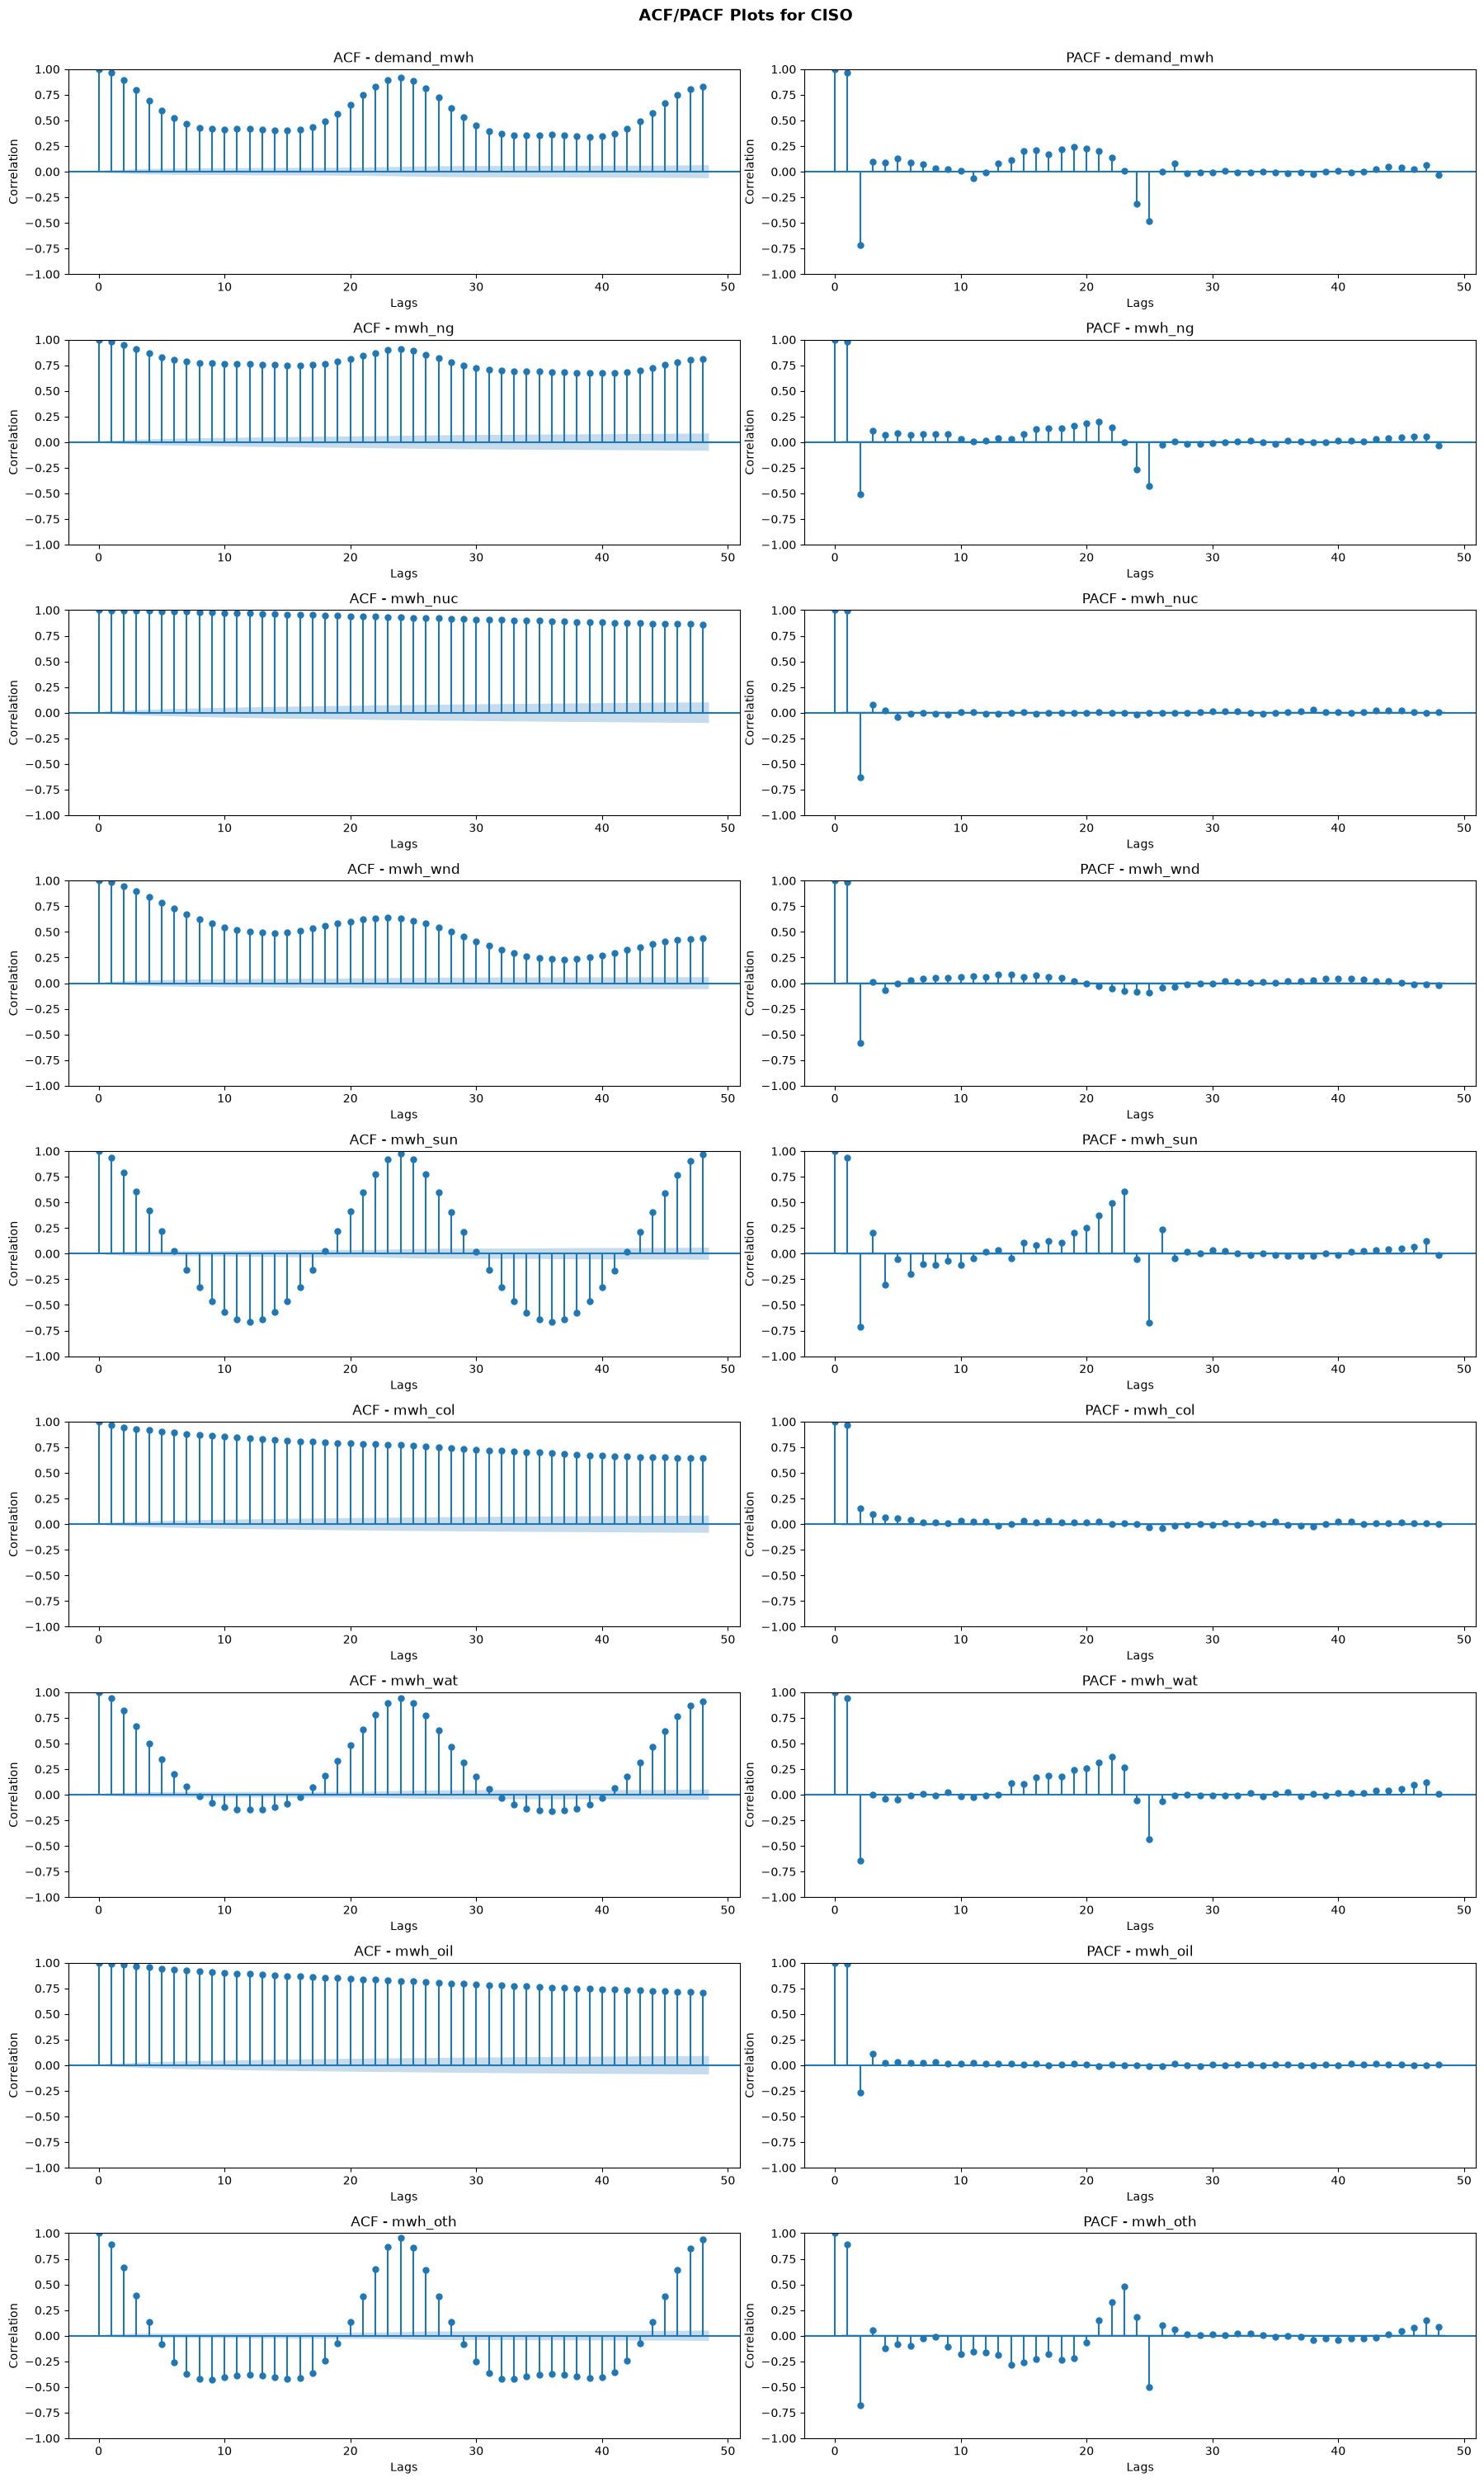

c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\statsmodels\regression\linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)


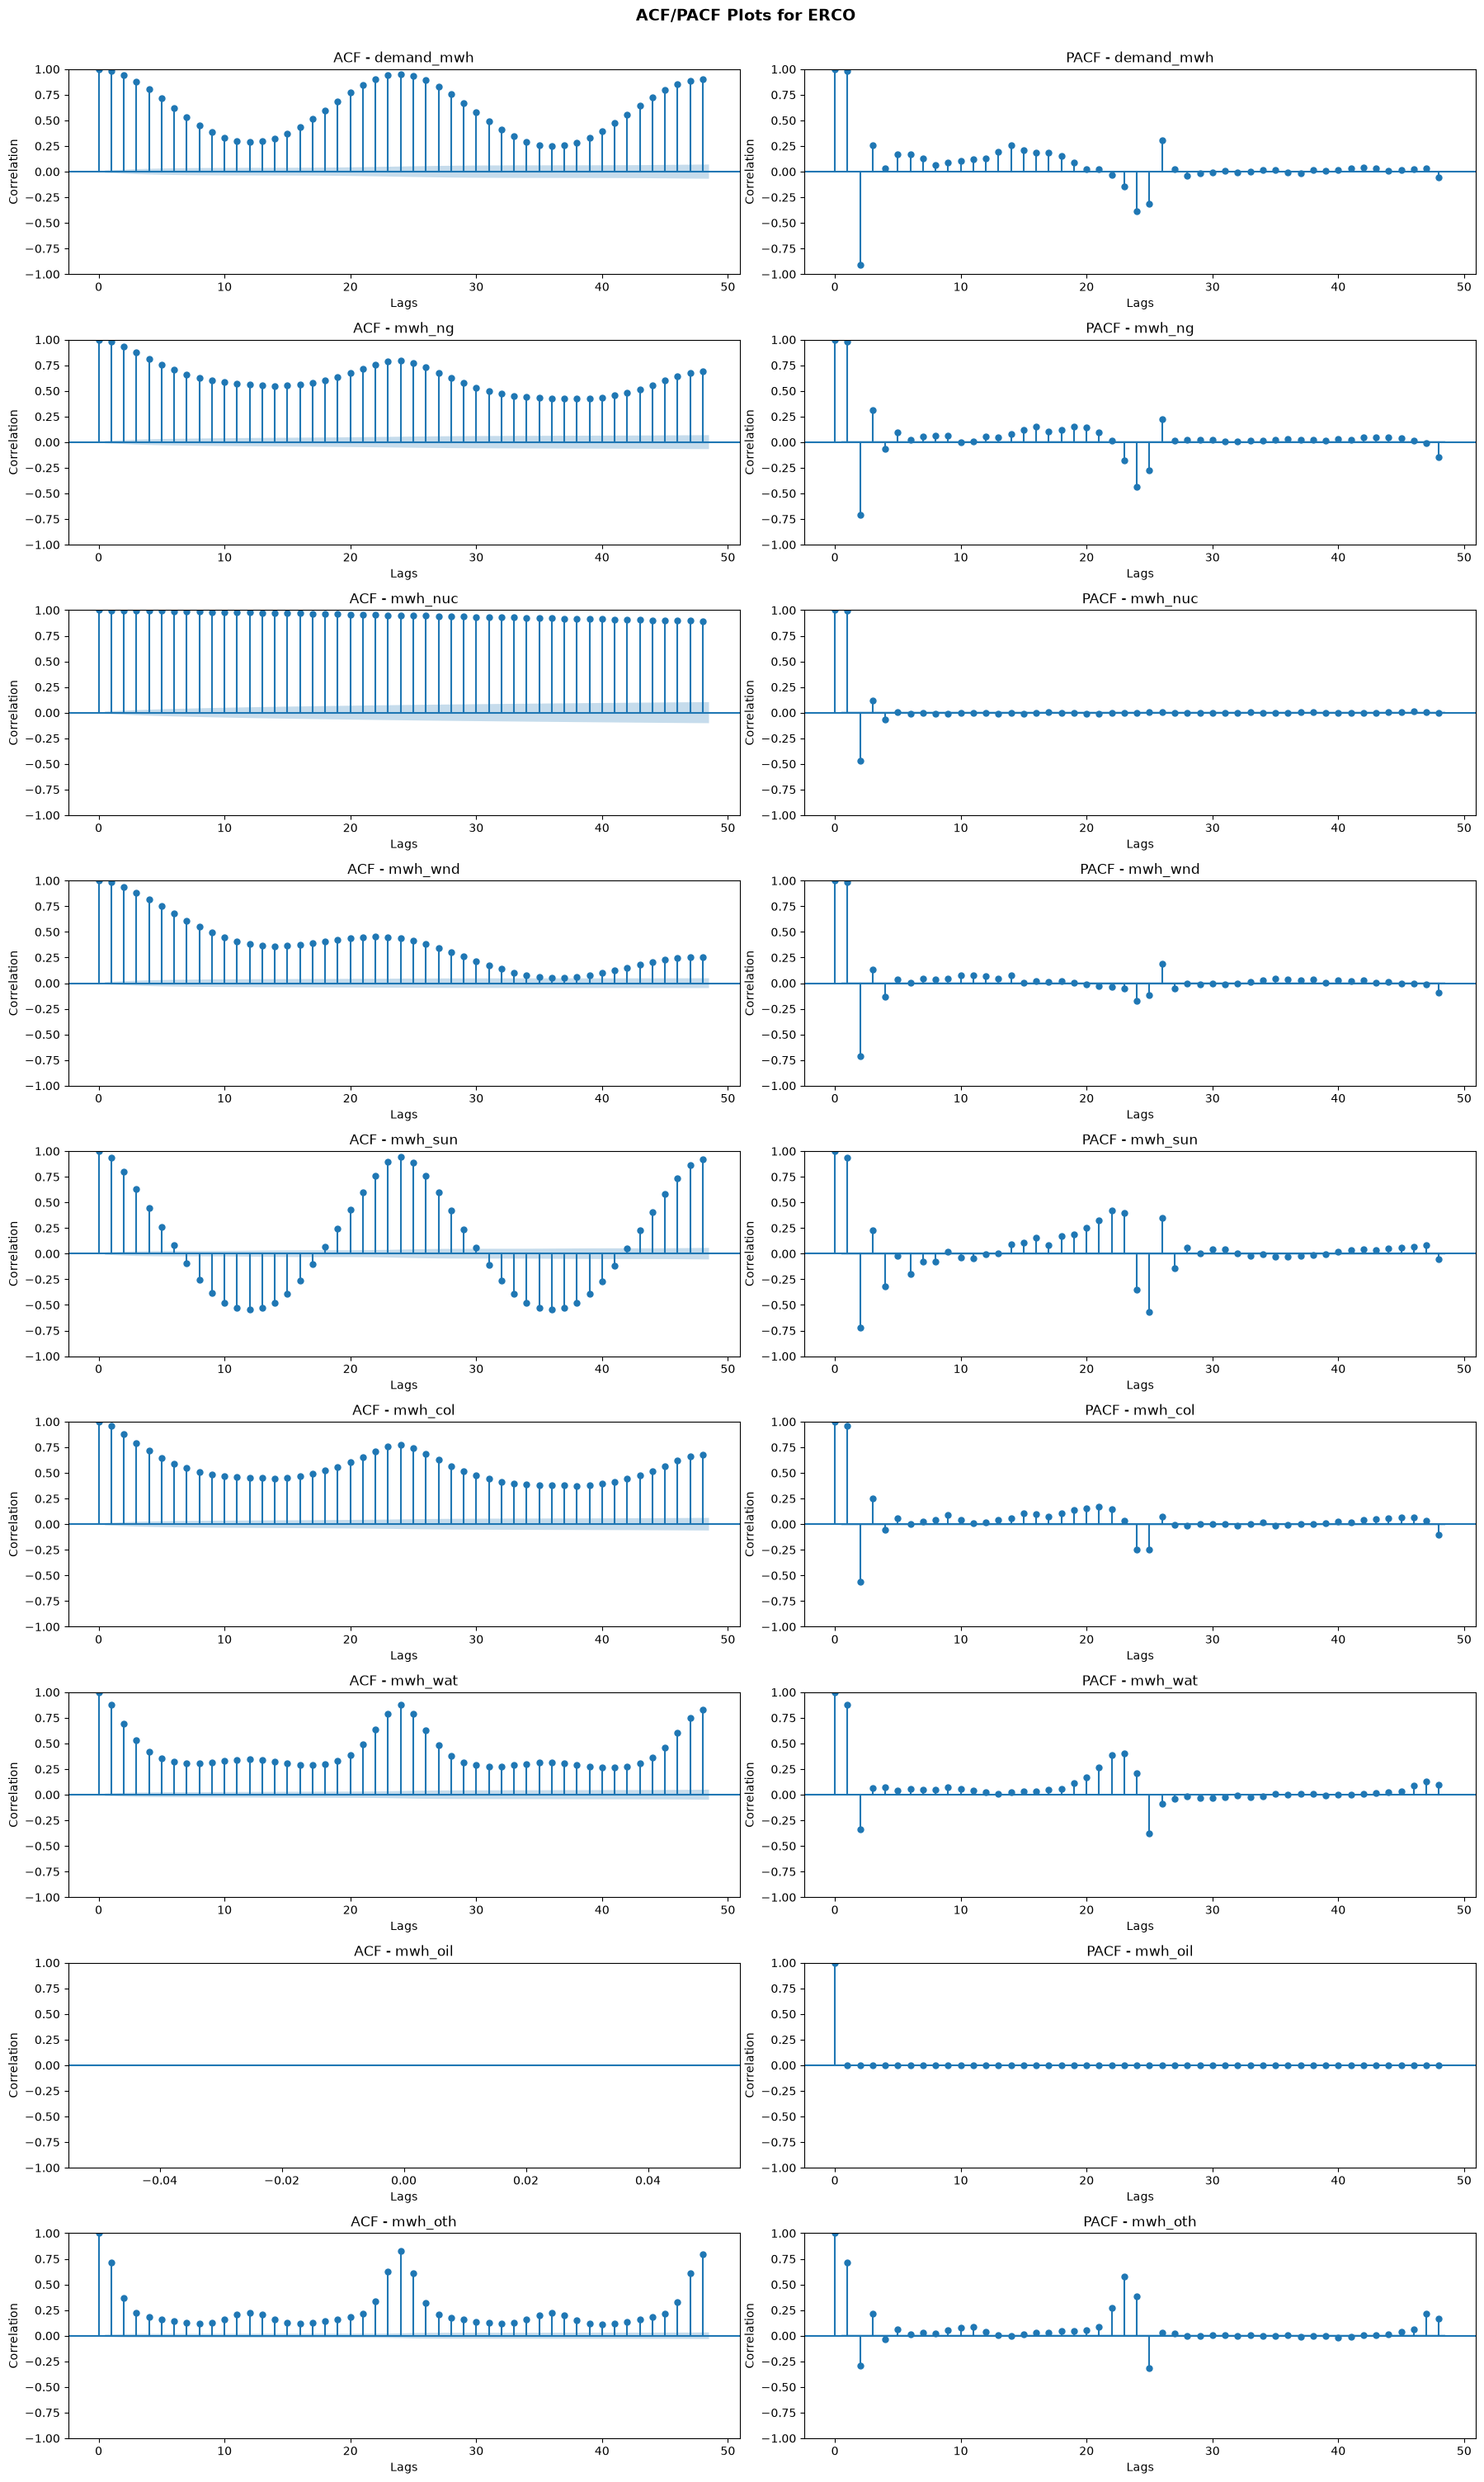

c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\statsmodels\regression\linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)


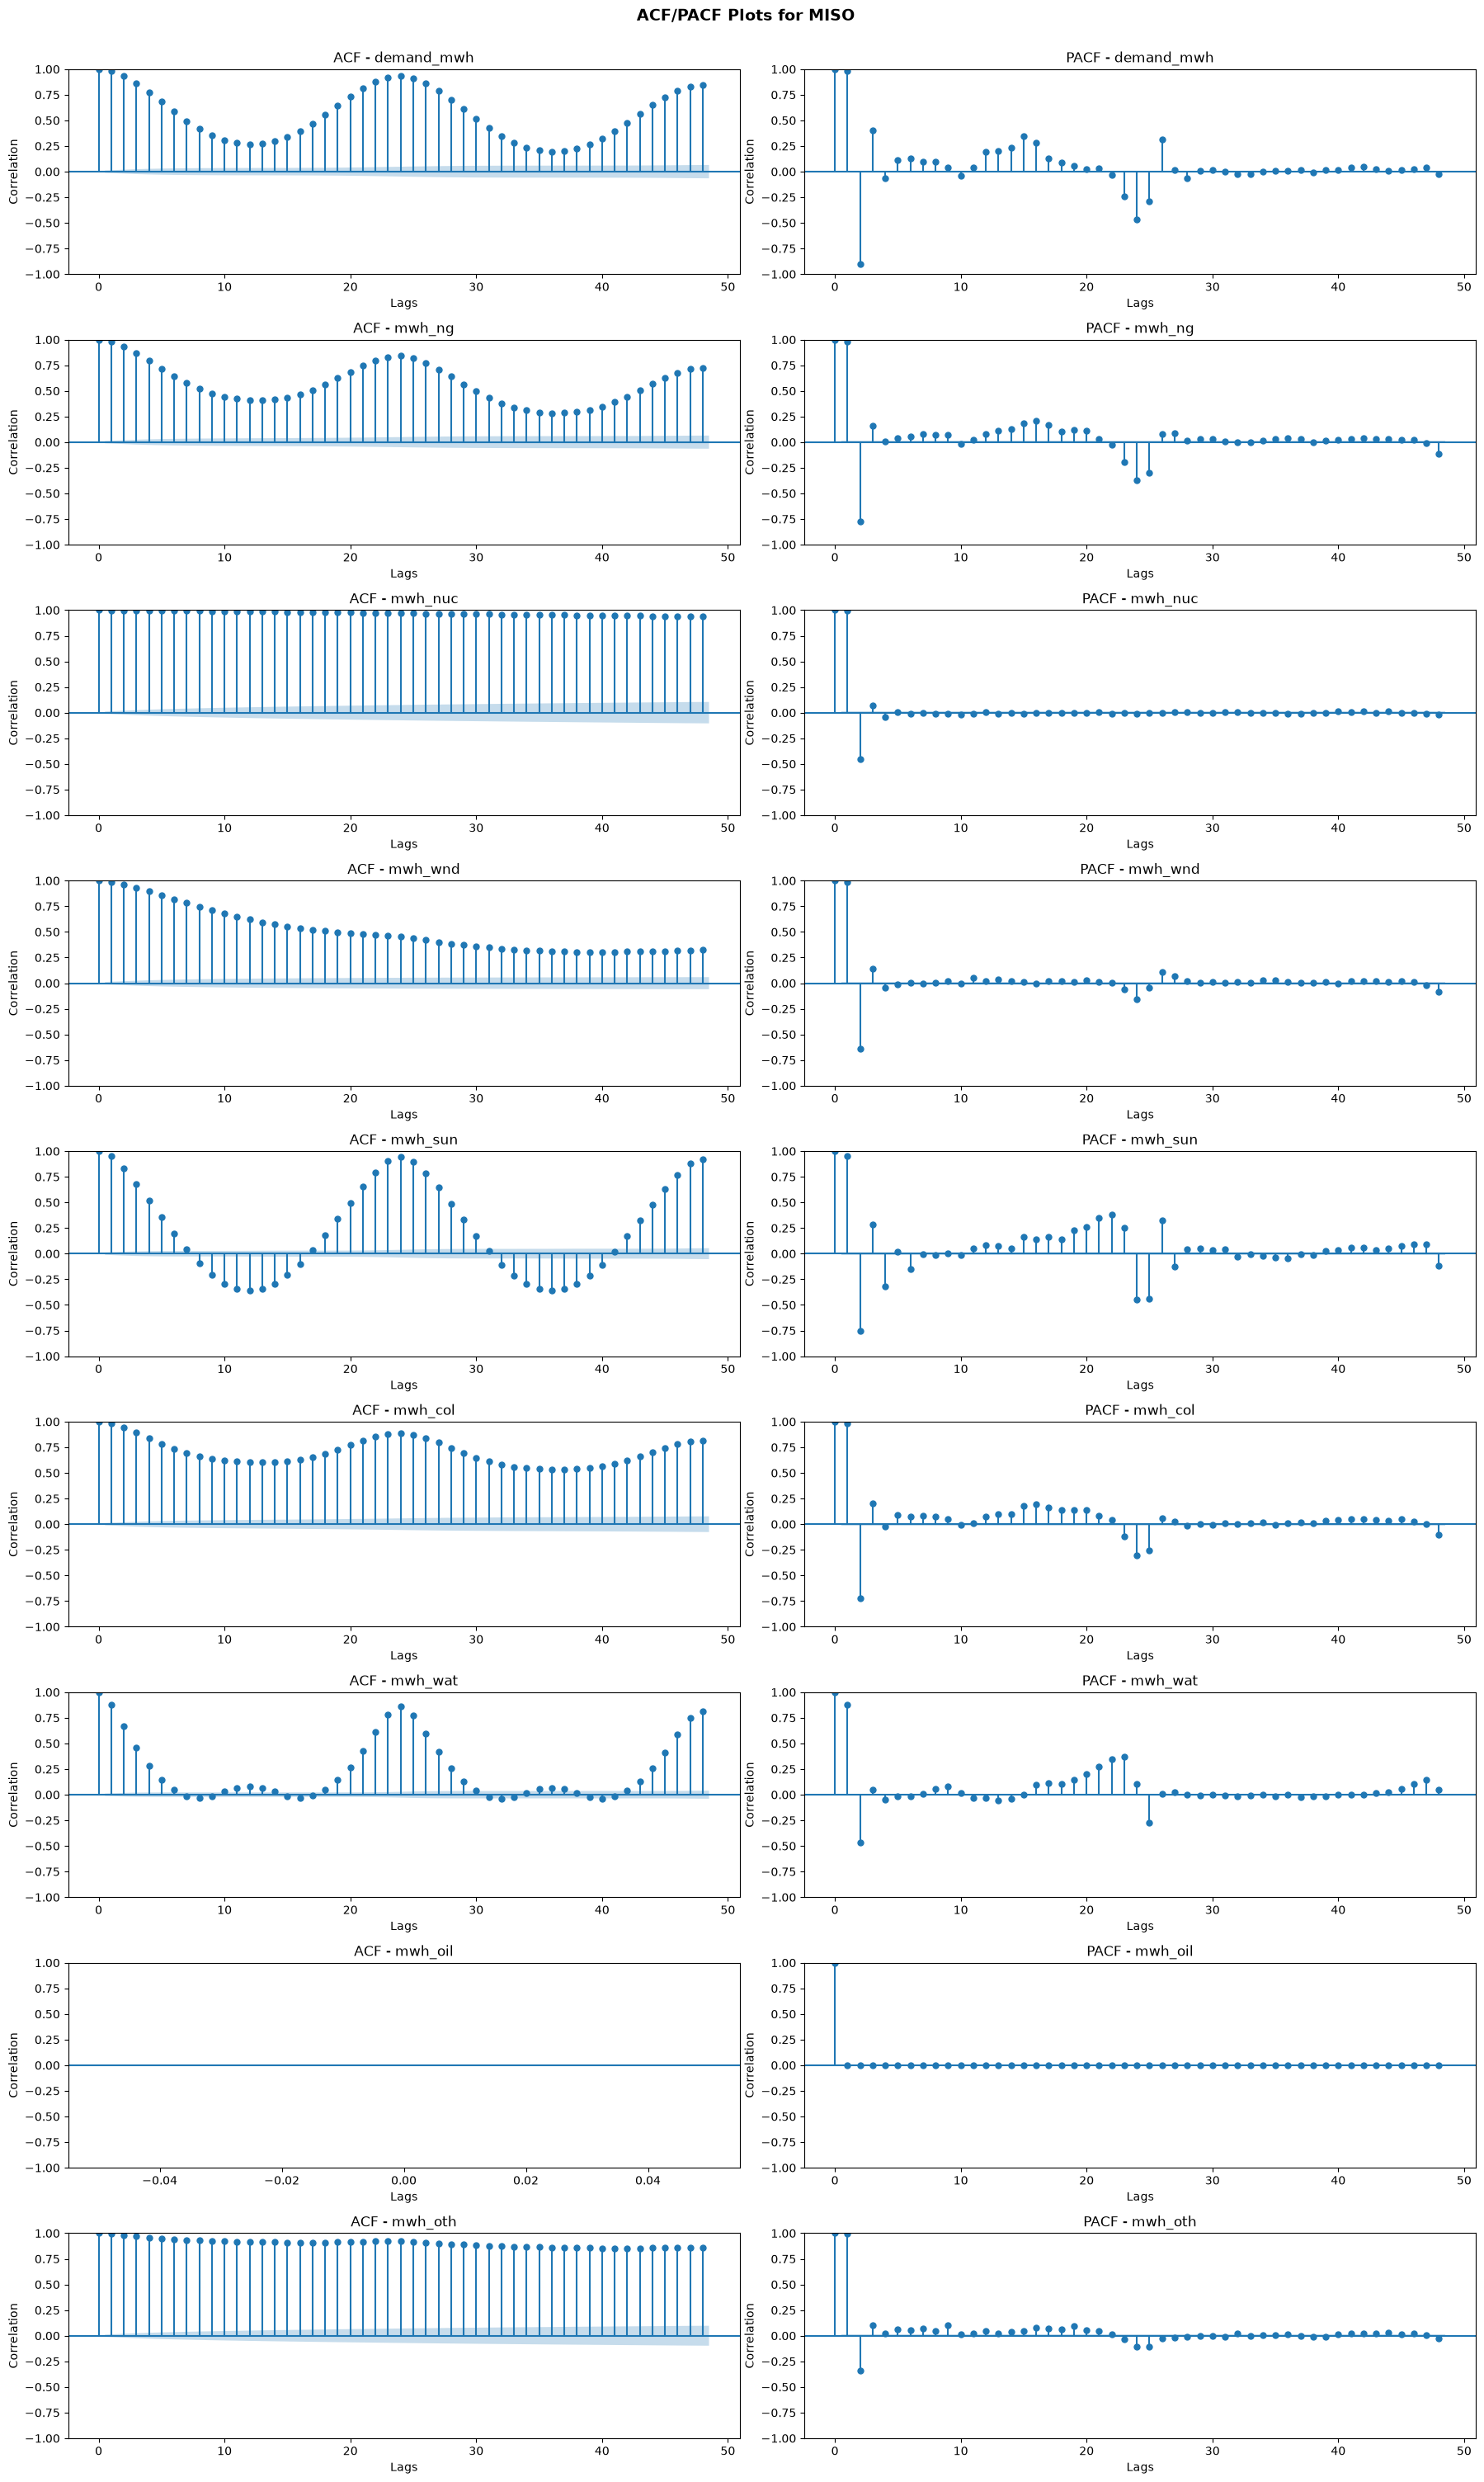

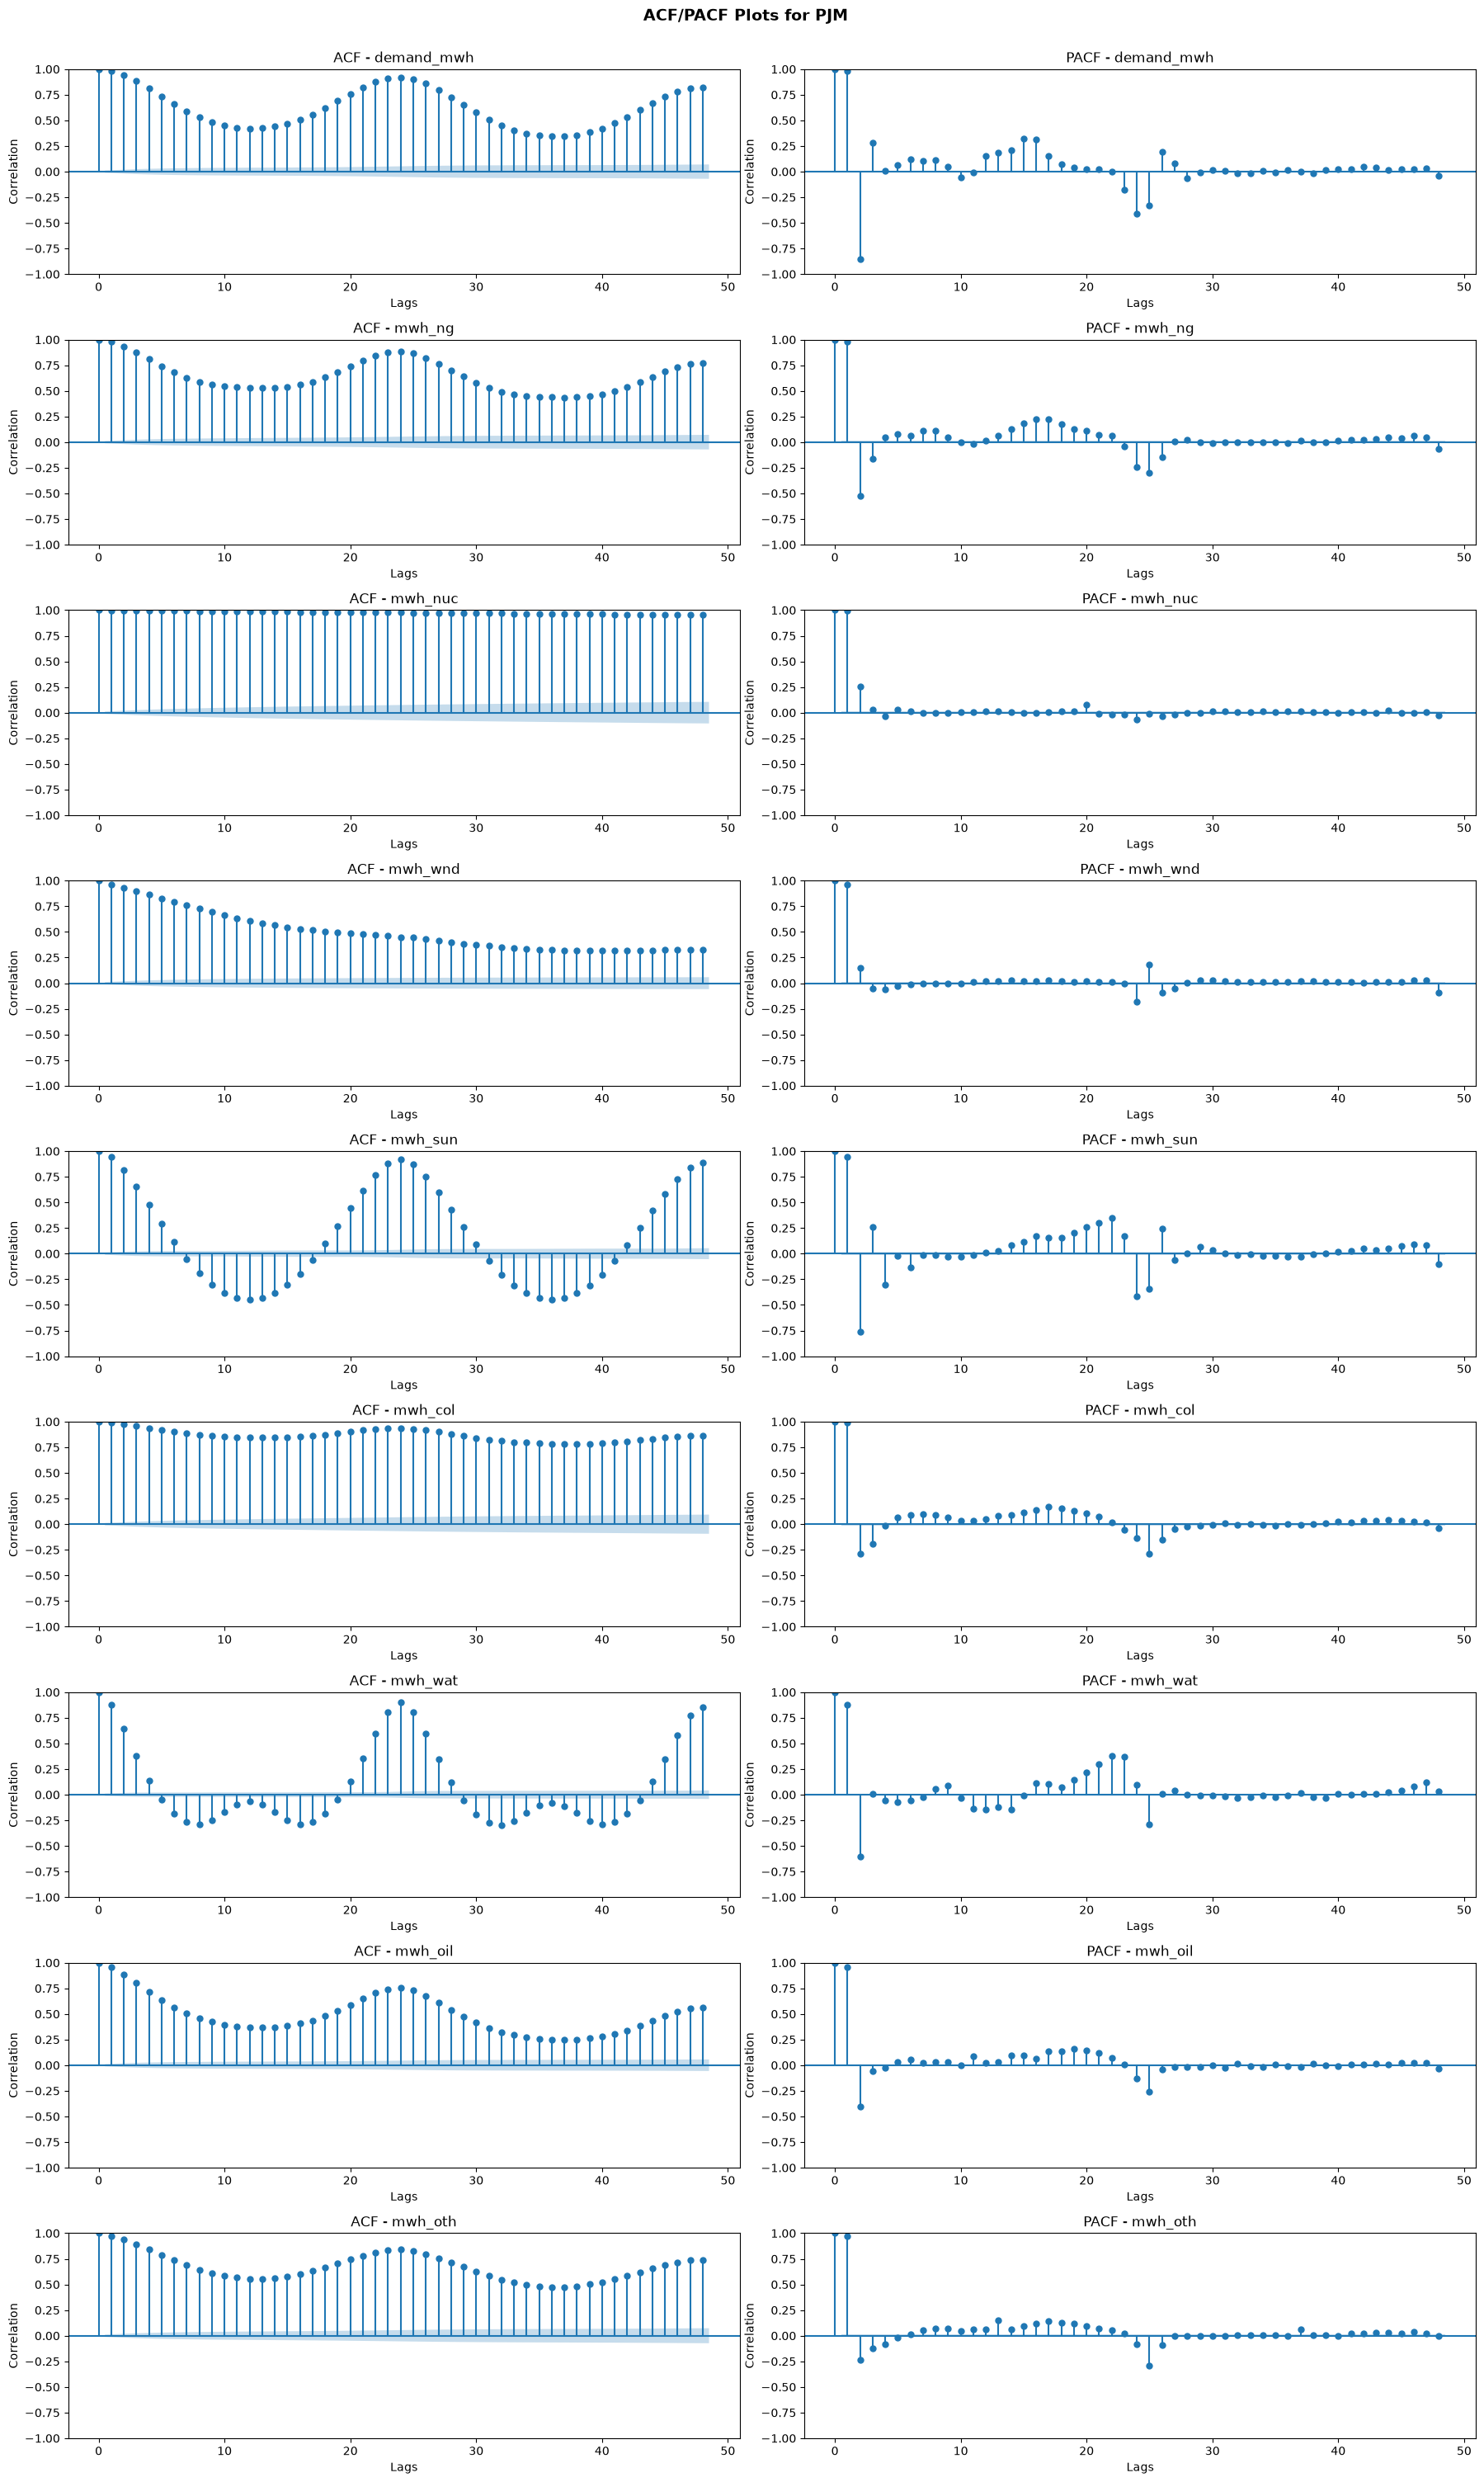

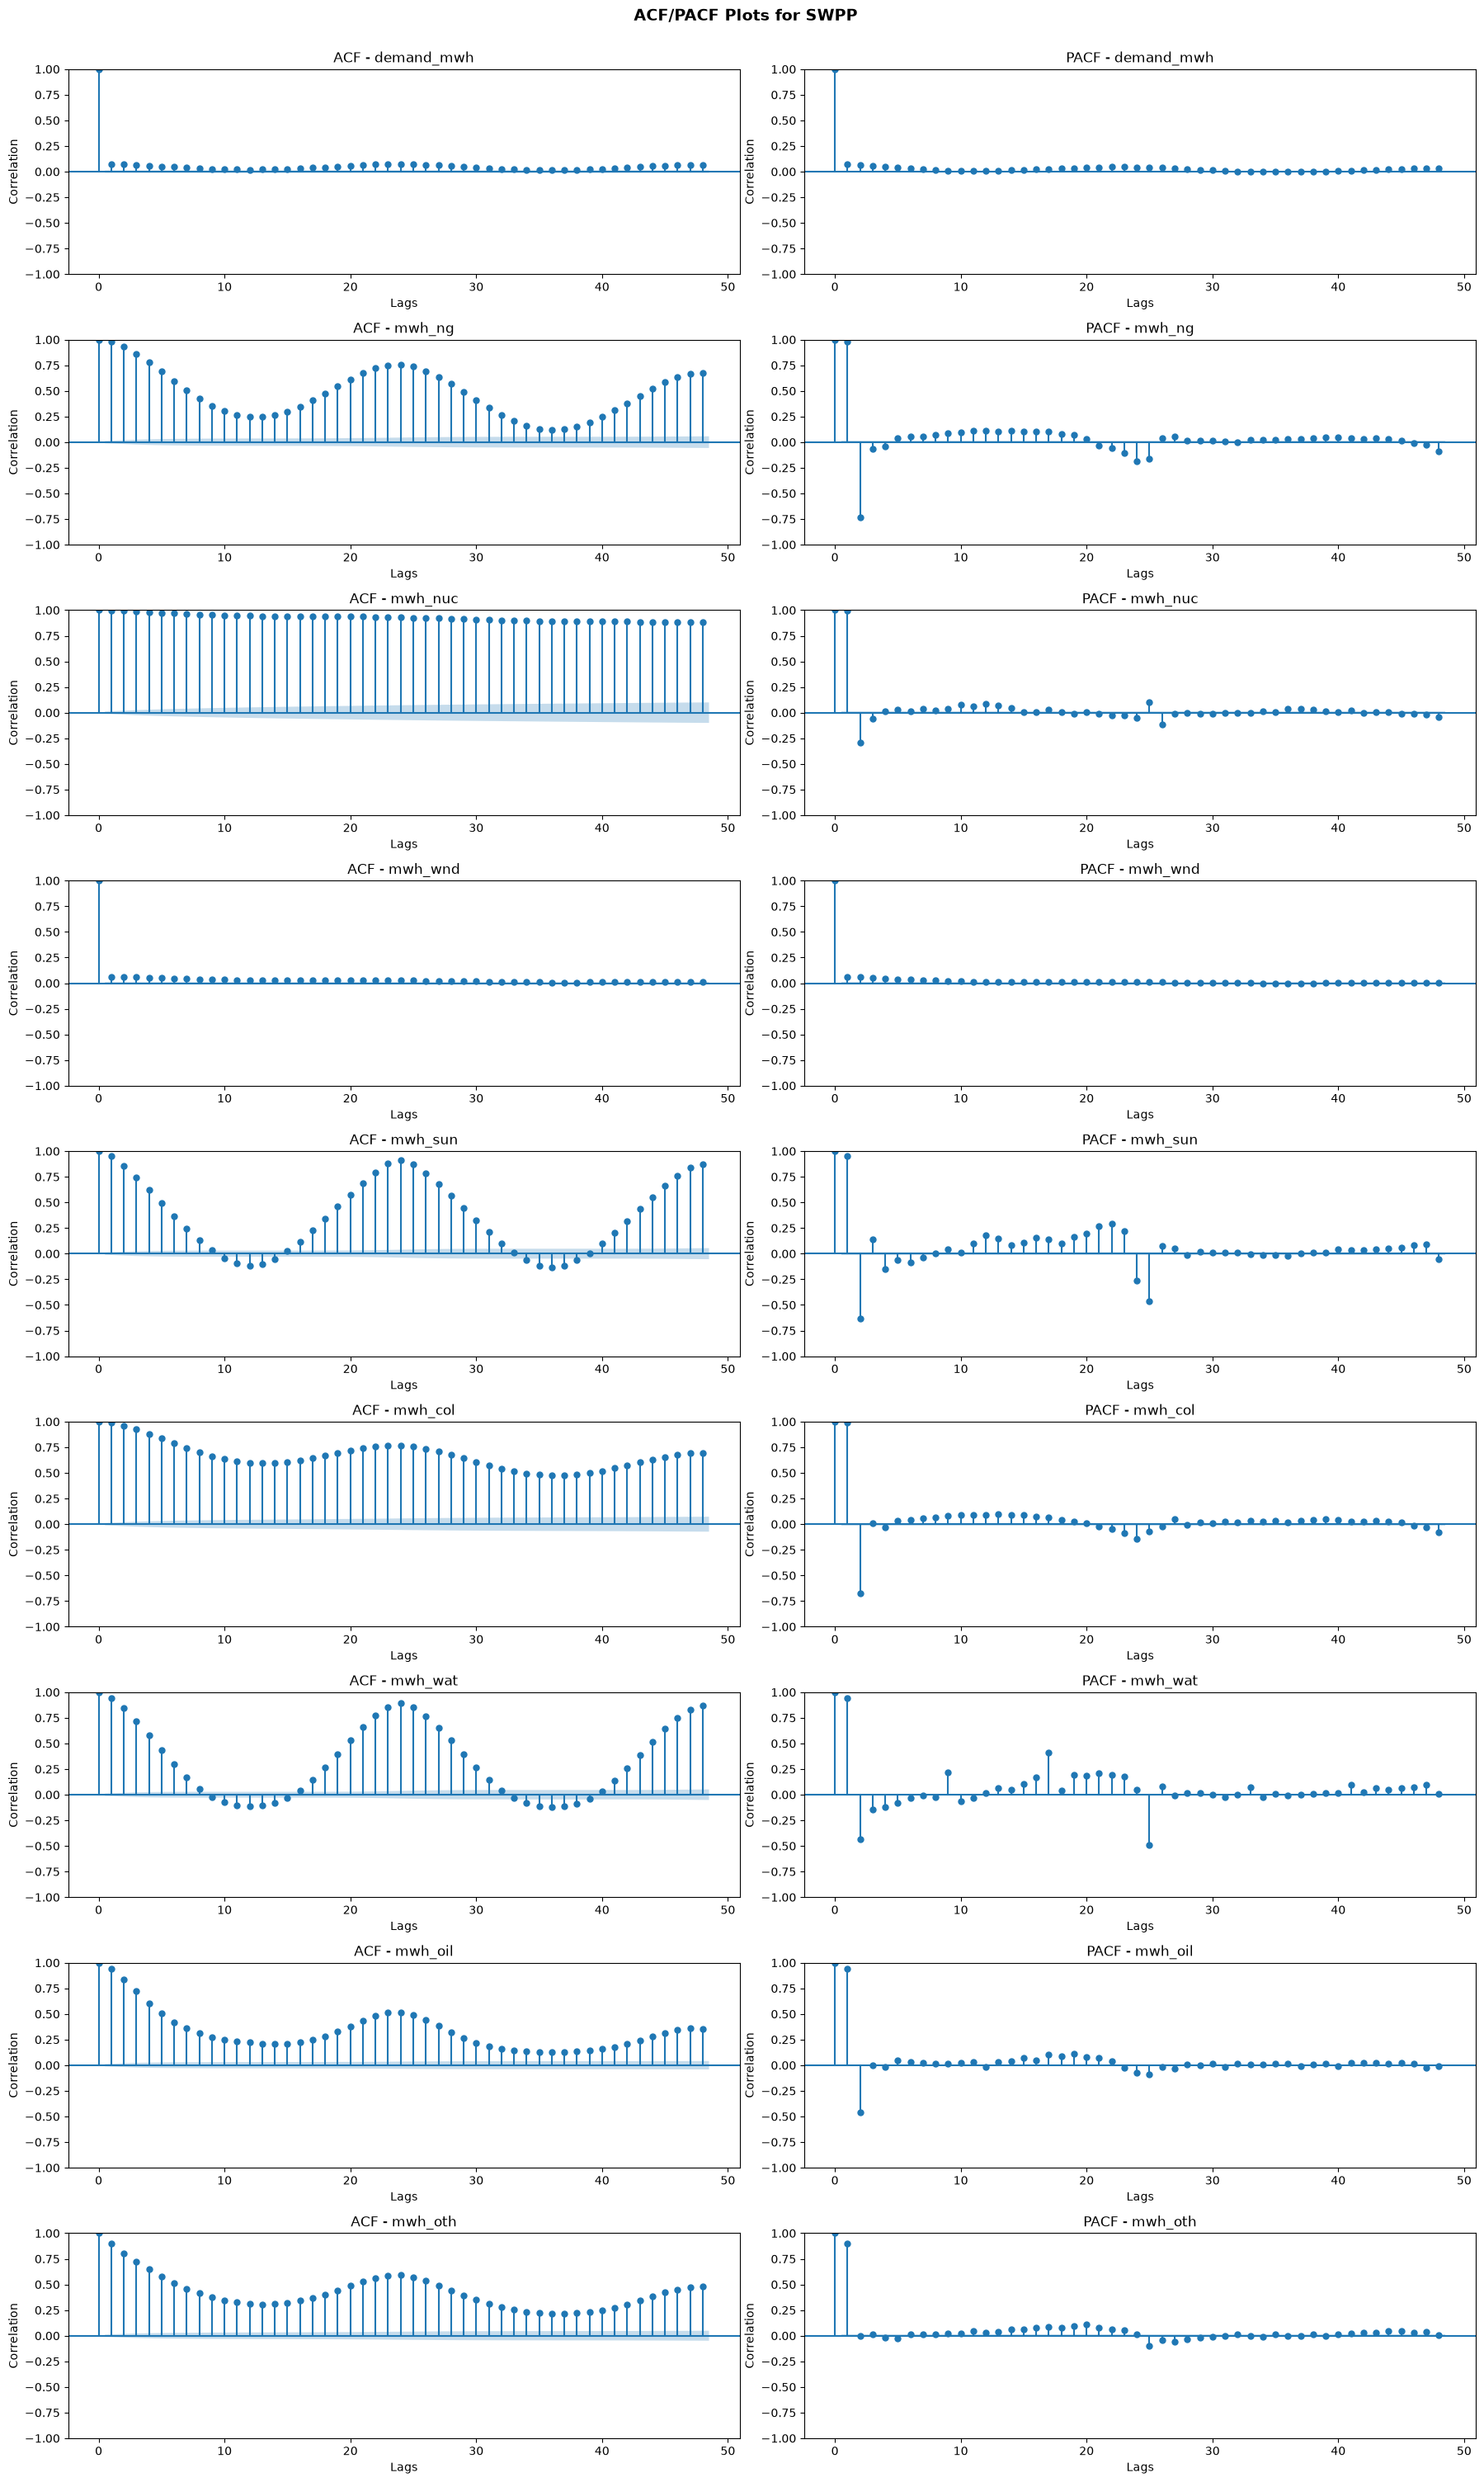

In [21]:
numeric = df_n.select_dtypes(include='number').columns

for rto in df_n['rto_id'].unique():
    curr = df_n[df_n['rto_id']==rto]

    fig, ax = plt.subplots(nrows=len(numeric), ncols=2, figsize=(18, 30))
    ax = ax.flatten()
    i = 0
    for col in numeric:
        plot_acf(curr[col], lags=48, ax=ax[i], title=f'ACF - {col}')
        ax[i].set_xlabel('Lags')
        ax[i].set_ylabel('Correlation')

        i+=1
        plot_pacf(curr[col], lags=48, ax=ax[i], title=f'PACF - {col}')
        ax[i].set_xlabel('Lags')
        ax[i].set_ylabel('Correlation')

        i+=1
    plt.suptitle(f'ACF/PACF Plots for {rto}', fontsize=14, fontweight='bold', y=1.001)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    print('')

In [32]:
temp = {
    'demand_mwh': { 
        'lag': [1, 2, 24], 'r_avg': []
    },
    'mwh_ng': {
        'lag': [1, 2, 24], 'r_avg': []
    },
    'mwh_nuc': {
        'lag': [1, 2], 'r_avg': [24]
    },
    'mwh_wnd': {
        'lag': [1, 2], 'r_avg': [24]
    },
    'mwh_sun': {
        'lag': [1, 2, 24], 'r_avg': []
    },
    'mwh_col': {
        'lag': [1, 2, 24], 'r_avg': [24]
    },
    'mwh_wat': {
        'lag': [1, 2, 24], 'r_avg': []
    },
    'mwh_oil': {
        'lag': [1, 2], 'r_avg': [24]
    },
    'mwh_oth': {
        'lag': [1, 2, 23], 'r_avg': []
    },
}

df_n_lagged = df_n.copy()
list_data = []

for rto in df_n_lagged['rto_id'].unique():
    current = df_n_lagged[df_n_lagged['rto_id']==rto].copy()
    for feature, shifts in temp.items():
        lag = shifts['lag']
        rolling_avg = shifts['r_avg']
        for l in lag:
            current[f'{feature}_lag{l}'] = current[feature].shift(l)
        for avg in rolling_avg:
            current[f'{feature}_rolling{avg}'] = current[feature].rolling(window=avg).mean()
        #print(f'{feature}: {lag}')
    current.dropna(inplace=True)
    list_data.append(current)

df_n_lagged = pd.concat(list_data, ignore_index=True)

In [33]:
cols_num = [col for col in df_n_lagged.select_dtypes(include='number').columns]

### 4.3.3. Creating Datetime Features
---

In [34]:
df_n_lagged['month'] = df_n_lagged['time_stamp'].dt.month.astype(str)
df_n_lagged['day_of_week'] = df_n_lagged['time_stamp'].dt.day_of_week.astype(str)
df_n_lagged['day_of_month'] = df_n_lagged['time_stamp'].dt.day.astype(str)
df_n_lagged['hour'] = df_n_lagged['time_stamp'].dt.hour.astype(str)

df_n_lagged

,id_demand_elec_generated,time_stamp,rto_id,rto_full_name,demand_mwh,mwh_ng,mwh_nuc,mwh_wnd,mwh_sun,mwh_col,...,mwh_oil_lag1,mwh_oil_lag2,mwh_oil_rolling24,mwh_oth_lag1,mwh_oth_lag2,mwh_oth_lag23,month,day_of_week,day_of_month,hour
0,DFCISO20230102-00AGG,2023-01-02 00:00:00,CISO,California Independent System Operator,19644.0,5560.0,2250.0,4113.0,3445.0,4.0,...,86.0,86.0,80.791667,-695.0,-1124.0,846.0,1,0,2,0
1,DFCISO20230102-01AGG,2023-01-02 01:00:00,CISO,California Independent System Operator,20649.0,6957.0,2251.0,3780.0,527.0,4.0,...,86.0,86.0,80.750000,-221.0,-695.0,1450.0,1,0,2,1
2,DFCISO20230102-02AGG,2023-01-02 02:00:00,CISO,California Independent System Operator,22399.0,8263.0,2252.0,3838.0,-13.0,3.0,...,86.0,86.0,80.958333,1026.0,-221.0,1307.0,1,0,2,2
3,DFCISO20230102-03AGG,2023-01-02 03:00:00,CISO,California Independent System Operator,24778.0,8812.0,2251.0,4001.0,-13.0,3.0,...,87.0,86.0,82.708333,1867.0,1026.0,1010.0,1,0,2,3
4,DFCISO20230102-04AGG,2023-01-02 04:00:00,CISO,California Independent System Operator,25166.0,8709.0,2251.0,3980.0,-14.0,3.0,...,87.0,87.0,84.458333,1368.0,1867.0,768.0,1,0,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157031,DFSWPP20260805-20AGG,2026-08-05 20:00:00,SWPP,Southwest Power Pool,49243.0,20109.0,1970.0,7814.0,2100.0,15976.0,...,0.0,0.0,0.000000,35.0,34.0,28.0,8,2,5,20
157032,DFSWPP20260805-21AGG,2026-08-05 21:00:00,SWPP,Southwest Power Pool,50110.0,19986.0,1969.0,8047.0,2077.0,16127.0,...,0.0,0.0,0.000000,34.0,35.0,45.0,8,2,5,21
157033,DFSWPP20260805-22AGG,2026-08-05 22:00:00,SWPP,Southwest Power Pool,50423.0,19561.0,1969.0,8871.0,2020.0,15966.0,...,0.0,0.0,0.000000,28.0,34.0,60.0,8,2,5,22
157034,DFSWPP20260805-23AGG,2026-08-05 23:00:00,SWPP,Southwest Power Pool,50419.0,19095.0,1968.0,10424.0,1892.0,15191.0,...,0.0,0.0,0.000000,45.0,28.0,83.0,8,2,5,23


## **4.4. Feature Encoding - Categorical Feature**

In [35]:
def encode_data(item):
    if item == 'CISO':
        return 1
    elif item == 'ERCO':
        return 2
    elif item == 'MISO':
        return 3
    elif item == 'PJM':
        return 4
    else:
        return 5

'''df_n_lagged['rto_id'] = df_n_lagged['rto_id'].apply(encode_data)
df_n_lagged'''

"df_n_lagged['rto_id'] = df_n_lagged['rto_id'].apply(encode_data)\ndf_n_lagged"

In [36]:
cols_cat = ['rto_id', 'month', 'day_of_week', 'day_of_month', 'hour']

## **4.5. Data Splitting**

In [37]:
def extract_train_test_val(data, rto):
    curr_cols = data.columns.to_list()
    current = data[data['rto_id']==rto].sort_values(by='time_stamp', ascending=True).reset_index(drop=True)
    current['time_idx'] = np.tile(np.arange(len(current)), 1)
    current = current[['time_idx'] + curr_cols]
    
    size_train = int(0.7*len(current))
    size_val = int(0.1*len(current))
    print(f'Train size: {size_train}, Val size: {size_val}, Test size: {len(current) - (size_val+size_train)}\n')

    train_subset = current.loc[:size_train].reset_index(drop=True)
    val_subset = current.loc[size_train+1:size_train+size_val].reset_index(drop=True)
    test_subset = current.loc[size_train+size_val+1:].reset_index(drop=True)
    return train_subset, val_subset, test_subset

In [38]:
list_train, list_val, list_test = [], [], []
for rto in df_n_lagged['rto_id'].unique():
    print(f'Splitting at {rto}')
    train_, val_, test_ = extract_train_test_val(df_n_lagged.copy(), rto)

    list_train.append(train_)
    list_val.append(val_)
    list_test.append(test_)

train = pd.concat(list_train, axis=0, ignore_index=True)
val = pd.concat(list_val, axis=0, ignore_index=True)
test = pd.concat(list_test, axis=0, ignore_index=True)

cols_forbid = ['id_demand_elec_generated', 'time_stamp', 'rto_full_name']
train.drop(columns=cols_forbid, inplace=True)
val.drop(columns=cols_forbid, inplace=True)
test.drop(columns=cols_forbid, inplace=True)

Splitting at CISO
Train size: 21991, Val size: 3141, Test size: 6285

Splitting at ERCO
Train size: 21874, Val size: 3124, Test size: 6251

Splitting at MISO
Train size: 22025, Val size: 3146, Test size: 6294

Splitting at PJM
Train size: 22008, Val size: 3144, Test size: 6288

Splitting at SWPP
Train size: 22025, Val size: 3146, Test size: 6294



# **5. Modelling**
---

## **5.1. ARIMAX Baseline**
---

In [63]:
cols_endog = ['demand_mwh']
cols_exog = [col for col in train.columns if (col.endswith('_lag24') or col.endswith('_rolling24')) and 'demand' not in col] + ['rto_id', 'month', 'day_of_week', 'day_of_month', 'hour']

train_arima = train[cols_endog+cols_exog].copy()
test_arima = test[cols_endog+cols_exog].copy()
val_arima = val[cols_endog+cols_exog].copy()
for col in ['month', 'day_of_week', 'day_of_month', 'hour']:
    train_arima[col] = pd.to_numeric(train_arima[col])
    test_arima[col] = pd.to_numeric(test_arima[col])
    val_arima[col] = pd.to_numeric(val_arima[col])
    
models_arima_per_rto = {}
for rto in train_arima['rto_id'].unique():
    curr = train_arima[train_arima['rto_id']==rto]
    models_arima_per_rto[f'{rto}'] = ARIMA(
        endog=curr['demand_mwh'], 
        exog=curr[[col for col in curr.columns if col not in cols_endog and col != 'rto_id']], 
        order=(2, 0, 1),
        seasonal_order=(1, 0, 1, 24),
        enforce_invertibility=False,
        enforce_stationarity=False
    ).fit()
    print(f'Finished fitting RTO label {rto}')

c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished fitting RTO label CISO


c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished fitting RTO label ERCO


c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished fitting RTO label MISO


c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Finished fitting RTO label PJM
Finished fitting RTO label SWPP


In [75]:
horizon = 24
lookback = 24

whole_lists = {
    'mae_whole_list': [],
    'rmse_whole_list': [],
    'smape_whole_list': [],
}

evals_per_rto = {}
for rto in test_arima['rto_id'].unique():
    curr_test = test_arima[test_arima['rto_id']==rto].reset_index(drop=True)
    evals_per_rto[rto] = {
        'mae_list': [],
        'rmse_list': [],
        'smape_list': [],
    }

    for v in range(len(curr_test) - (horizon+lookback)):    
        current = curr_test.loc[v:v+lookback-1]
        forecast = models_arima_per_rto[rto].forecast(
            steps=horizon, 
            exog=current[[col for col in curr.columns if col not in cols_endog and col != 'rto_id']]
        )

        pred = torch.tensor(forecast.values.reshape(-1, 1), dtype=torch.float32)
        actual = torch.tensor(current['demand_mwh'].values.reshape(-1 , 1), dtype=torch.float32)

        evals_per_rto[rto]['mae_list'].append(MAE()(pred, actual).item())
        evals_per_rto[rto]['rmse_list'].append(RMSE()(pred, actual).item())
        evals_per_rto[rto]['smape_list'].append(SMAPE()(pred, actual).item() * 100)

        whole_lists['mae_whole_list'].append(MAE()(pred, actual).item())
        whole_lists['rmse_whole_list'].append(RMSE()(pred, actual).item())
        whole_lists['smape_whole_list'].append(SMAPE()(pred, actual).item() * 100)

    print(f"Test MAE {rto}:     {np.mean(evals_per_rto[rto]['mae_list']):.4f}")
    print(f"Test RMSE {rto}:    {np.mean(evals_per_rto[rto]['rmse_list']):.4f}")
    print(f"Test SMAPE {rto}:   {np.mean(evals_per_rto[rto]['smape_list']):.4f}%\n")

print(f"Test MAE General:     {np.mean(whole_lists['mae_whole_list']):.4f}")
print(f"Test RMSE General:    {np.mean(whole_lists['rmse_whole_list']):.4f}")
print(f"Test SMAPE General:   {np.mean(whole_lists['smape_whole_list']):.4f}%\n")

Test MAE CISO:     4110.9482
Test RMSE CISO:    4831.6630
Test SMAPE CISO:   15.3655%

Test MAE ERCO:     9955.5928
Test RMSE ERCO:    11665.8047
Test SMAPE ERCO:   18.4815%

Test MAE MISO:     10857.0535
Test RMSE MISO:    12595.1227
Test SMAPE MISO:   13.7067%

Test MAE PJM:     16019.3233
Test RMSE PJM:    18466.6694
Test SMAPE PJM:   15.7378%

Test MAE SWPP:     2177.8161
Test RMSE SWPP:    2551.0199
Test SMAPE SWPP:   6.1334%

Test MAE General:     8622.1895
Test RMSE General:    10019.6612
Test SMAPE General:   13.8779%



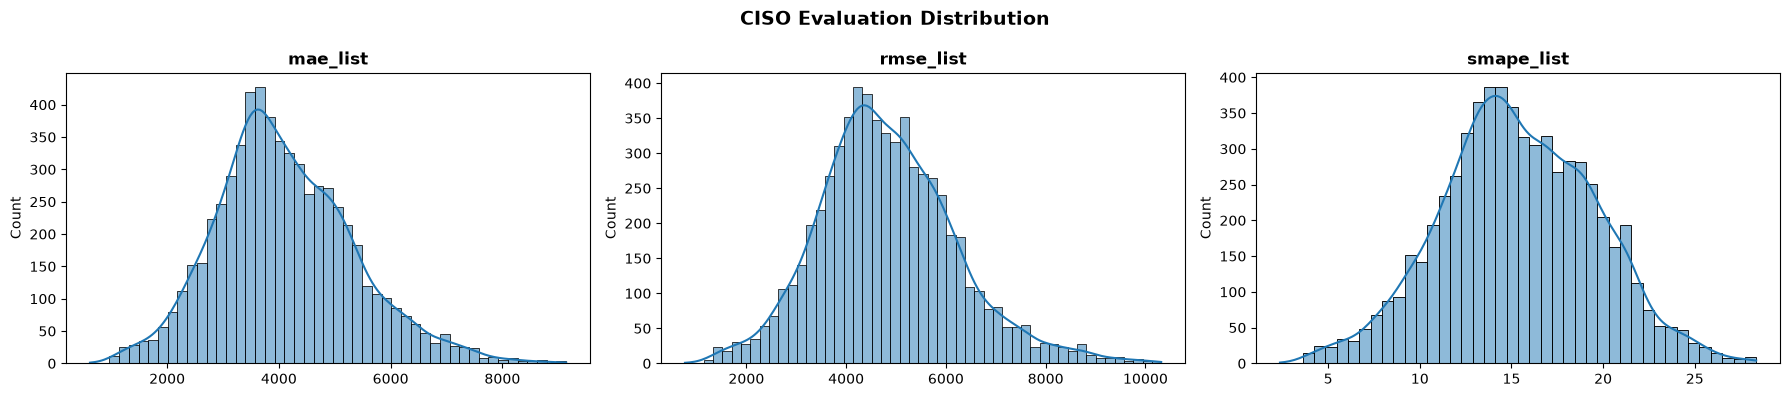

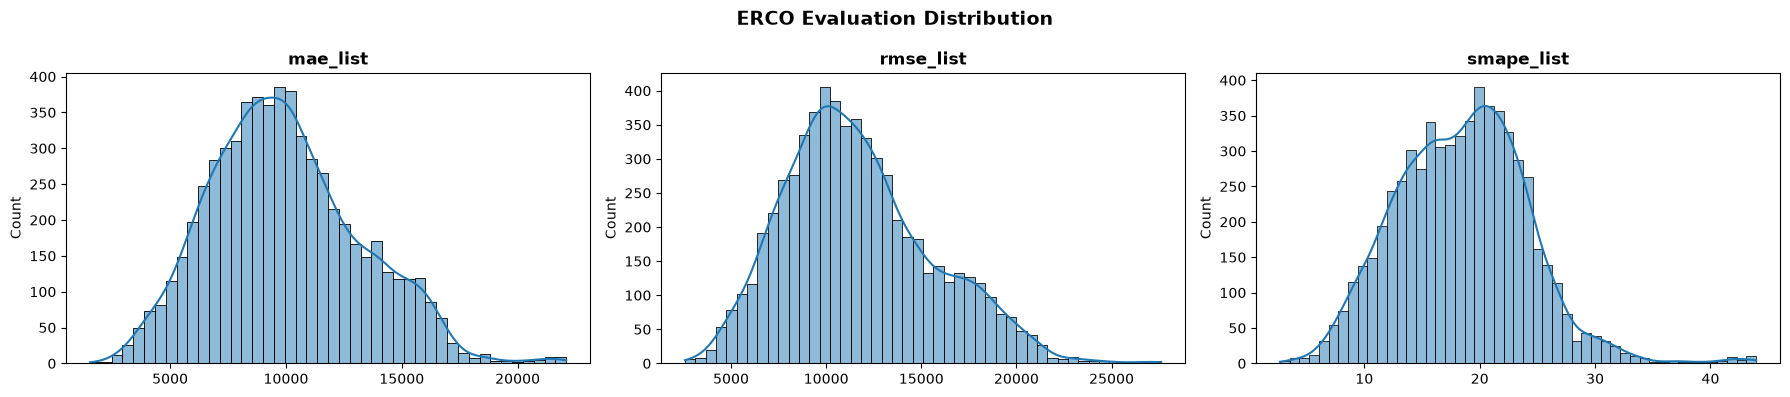

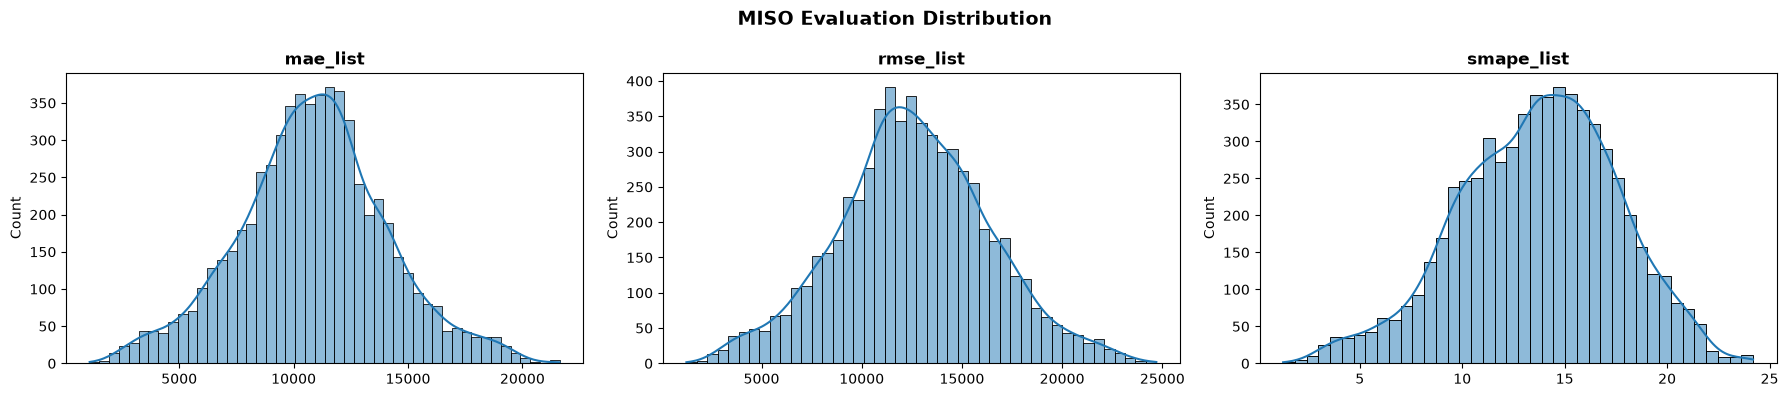

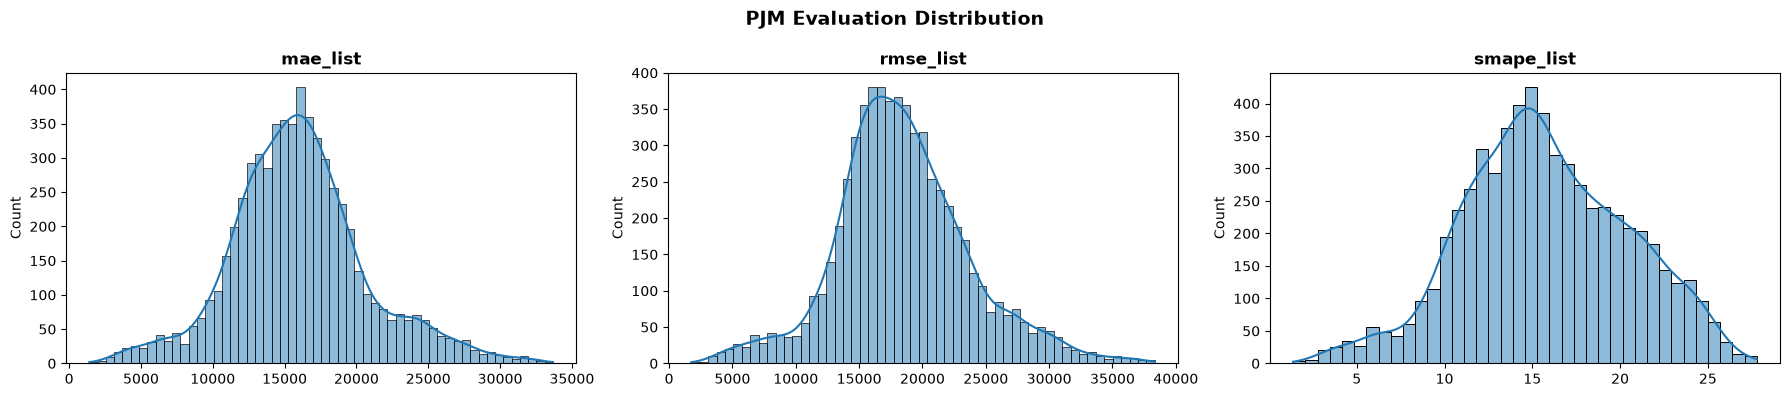

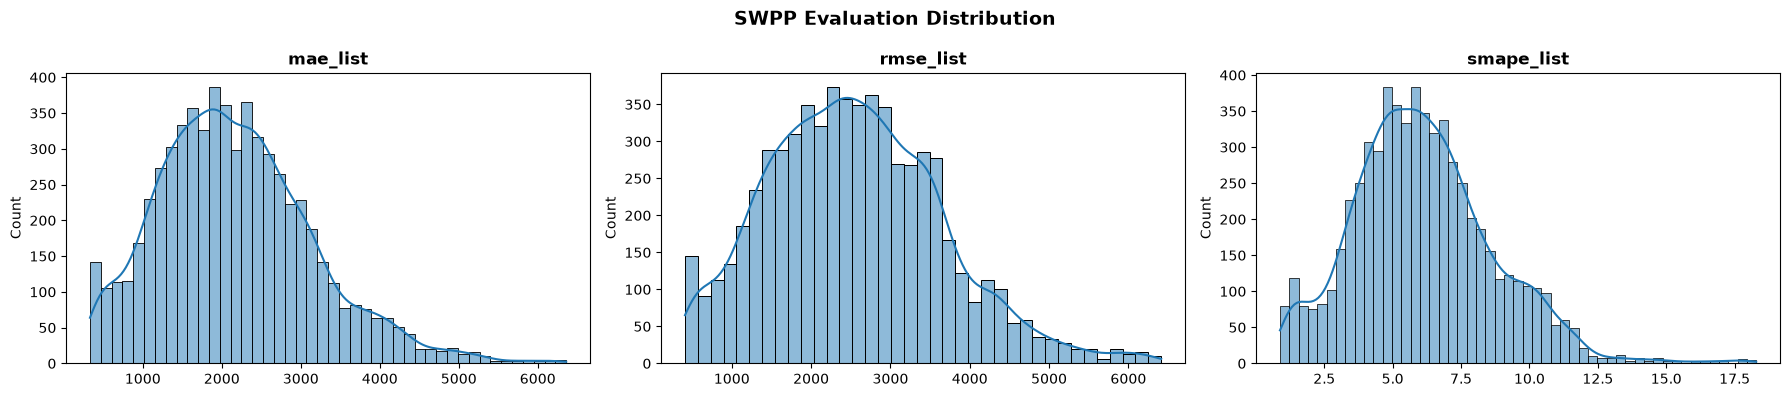

In [73]:
for rto in evals_per_rto:
    plt.figure(figsize=(18, 4))
    for i, (res, list_) in enumerate(evals_per_rto[rto].items()):
        plt.subplot(1, 3, i+1)
        sns.histplot(list_, kde=True)
        plt.title(f'{res}', fontsize=12, fontweight='bold')
    plt.suptitle(f'{rto} Evaluation Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## **5.2. Temporal Fusion Transformer**
---

### **5.2.1. Setting Up Inputs**
---

In [123]:
lookback = 48
forecast_horizon = 24

train_n = TimeSeriesDataSet(
    train,
    time_idx='time_idx',
    target='demand_mwh',
    group_ids=['rto_id'],

    # Lookback
    max_encoder_length=lookback,
    min_encoder_length=lookback,

    # Horizon
    min_prediction_length=forecast_horizon,
    max_prediction_length=forecast_horizon,

    # Features
    time_varying_known_categoricals=[col for col in cols_cat if col!='rto_id'],
    time_varying_known_reals=['time_idx'],
    time_varying_unknown_reals=cols_num,

    # Normalizing
    target_normalizer=GroupNormalizer(groups=['rto_id'], transformation='softplus'),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True
)
torch.save(train_n.get_parameters(), 'dataset_params.pt')

val_n = TimeSeriesDataSet.from_dataset(train_n, val, stop_randomization=True, predict=False)
test_n = TimeSeriesDataSet.from_dataset(train_n, test, stop_randomization=True, predict=False)

In [124]:
batch_size = 128

train_loader = train_n.to_dataloader(train=True, batch_size=batch_size)
val_loader = val_n.to_dataloader(train=False, batch_size=batch_size)
test_loader = test_n.to_dataloader(train=False, batch_size=batch_size)

train_steps = len(train_loader)

### **5.2.2. Modelling**
---

In [125]:
epoch=20

path_model = os.path.join(os.getcwd(), 'models')
if not os.path.exists(path_model):
    os.makedirs(path_model)

# Checkpoints
checkpoint_best = ModelCheckpoint(
    dirpath=path_model,
    filename='tft_best',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    save_weights_only=False
)
checkpoint = ModelCheckpoint(
    dirpath=path_model,
    filename='tft_per_epoch',
    save_last=True,
    save_top_k=1,
    save_weights_only=False
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, verbose=True, mode='min'
)

# Logger
logger = CSVLogger(
    path_model, name='log_tft'
)

In [126]:
tft = TemporalFusionTransformer.from_dataset(
    train_n, 
    hidden_size=10,
    learning_rate=0.001,
    lstm_layers=2,
    dropout=0.2,
    attention_head_size=2,
    output_size=1,
    loss=SMAPE(),
    logging_metrics=torch.nn.ModuleList([MAE(), RMSE()]),
    reduce_on_plateau_patience=3
)

trainer = lt.Trainer(
    max_epochs=epoch, 
    accelerator='cpu',
    #enable_progress_bar=False,
    logger=logger,
    callbacks=[checkpoint, checkpoint_best, early_stop],
    log_every_n_steps=train_steps
)

c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [127]:
trainer.fit(
    tft,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\user\works\DE_studies\electricity_demand_forecast\modelling\models exists and is not empty.

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | SMAPE                           | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 633    | train | 0    
3  | prescalers                         | ModuleDict                      | 672    | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 1.3 K  | train | 0    
5  | encoder_variable_selection        

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_datal

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.031


Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


### **5.2.3. Evaluation**
---

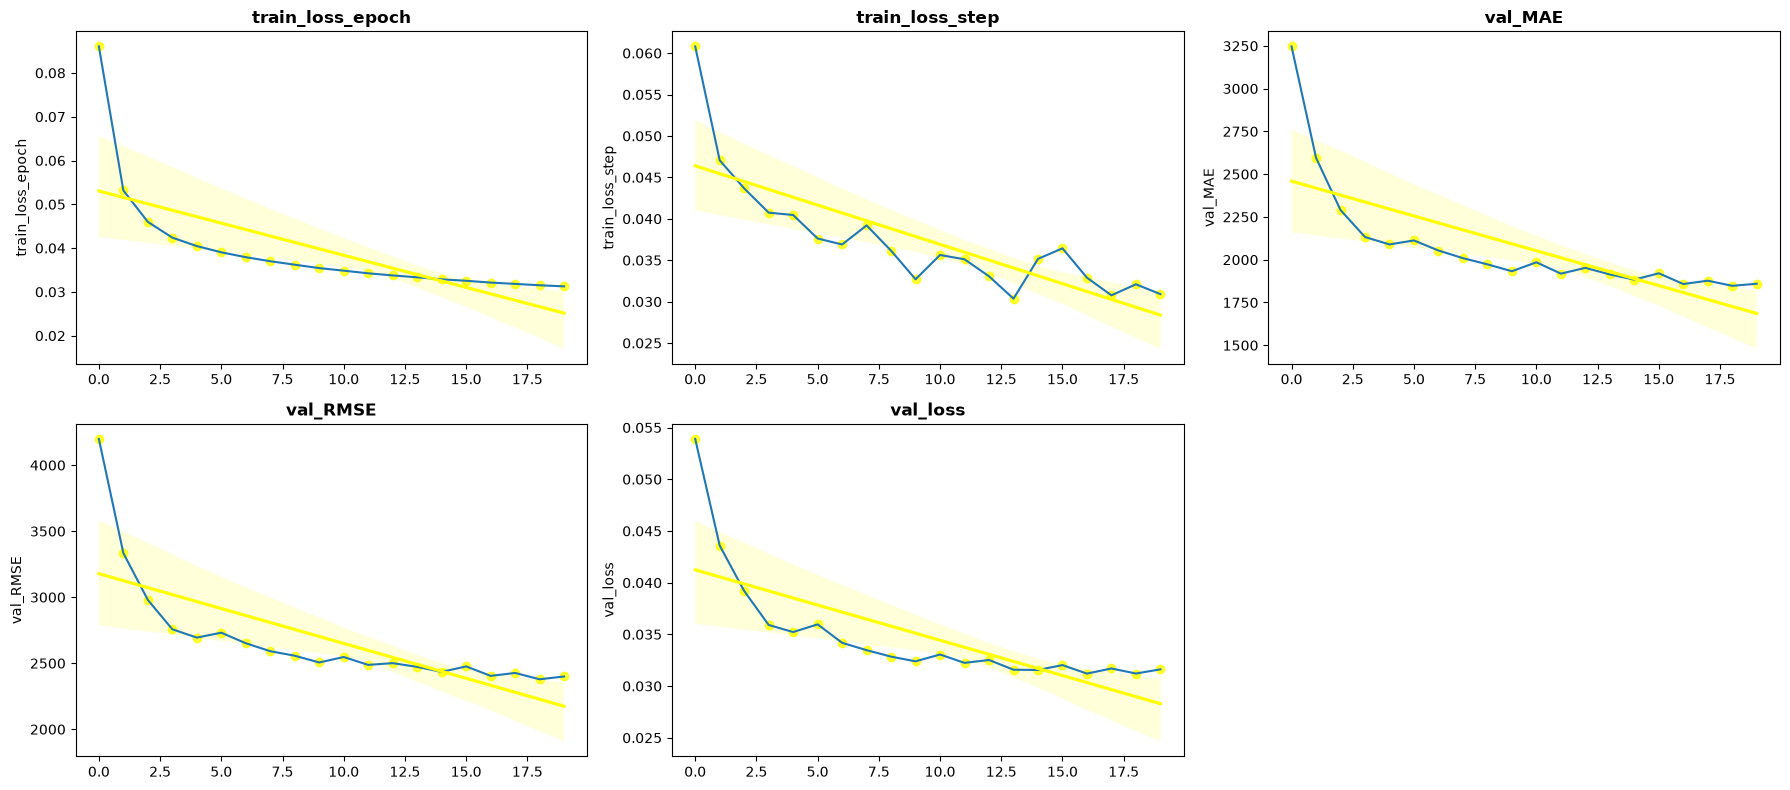

In [132]:
path_metrics_per_epoch = os.path.abspath('./models/log_tft/version_0/metrics.csv')
metrics = pd.read_csv(path_metrics_per_epoch)
metrics = metrics.groupby('epoch').ffill().bfill()
metrics.drop_duplicates(inplace=True)
metrics = metrics.reset_index(drop=True)

plt.figure(figsize=(18, 8))
for i, col in enumerate(metrics.columns[1:]):
    plt.subplot(2, 3, i+1)
    sns.lineplot(x=metrics.index, y=metrics[col], markers='o')
    sns.regplot(x=metrics.index, y=metrics[col], color='yellow')
    plt.title(f'{col}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [129]:
if os.path.exists(checkpoint_best.best_model_path):
    path_best_model = checkpoint_best.best_model_path
else:
    path_best_model = os.path.join(path_model, 'tft_best.ckpt')

best_model_tft = TemporalFusionTransformer.load_from_checkpoint(path_best_model)
result = best_model_tft.predict(test_loader, return_y=True, return_x=True)

c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\user\works\DE_studies\electricity_demand_forecast\elec_env\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installin

In [130]:
idx = test_n.x_to_index(result.x)
out = result.output
actual = result.y[0]
by_rto_metrics = {}

for rto in idx['rto_id'].unique():
    mask = (idx['rto_id']==rto).values
    pred_rto = out[mask]
    actual_rto = actual[mask]

    by_rto_metrics[rto] = {
        'mae': MAE()(pred_rto, actual_rto).item(),
        'rmse': RMSE()(pred_rto, actual_rto).item(),
        'smape': SMAPE()(pred_rto, actual_rto).item() * 100,
        'n_samples': mask.sum(),
    }

pd.DataFrame(by_rto_metrics).T

,mae,rmse,smape,n_samples
CISO,1227.807739,1684.974243,4.629716,6213.0
ERCO,2325.524658,3108.434814,4.057683,6179.0
MISO,2398.930420,3213.877686,3.031683,6222.0
PJM,3677.604980,4948.387207,3.612265,6216.0
SWPP,1561.515381,2136.493652,4.332846,6222.0


In [131]:
mae = MAE()(result.output, result.y).item()
rmse = RMSE()(result.output, result.y).item()
smape = SMAPE()(result.output, result.y).item()

print(f"Test MAE:   {mae:.4f}")
print(f"Test RMSE:  {rmse:.4f}")
print(f"Test SMAPE: {smape*100:.4f}%")

Test MAE:   2238.1707
Test RMSE:  3221.3008
Test SMAPE: 3.9325%
